In [ ]:
### Title- Cattle inflammation project
### Analysis includes The analysis includes: 1.DADA2 pipeline; 2.Decontamination using the Decontam and SourceTracker R package
### 3. Evaluation of alpha and beta diversity metrics; 4. Microbial Abundance; 5. Co-occurance analysis

In [1]:
#Calling R in conda environment 
R.version.string

[1] "R version 4.4.3 (2025-02-28)"

In [2]:
#load required libraries
library(dada2); packageVersion("dada2")
library(phyloseq)
library(ggplot2)
library(ShortRead)  
library(dplyr)
library(stats)
library(Biostrings)
library(ggpubr)
library(vegan)
library(microbiome)

Loading required package: Rcpp



[1] ‘1.34.0’

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, saveRDS, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min


Loading required package: BiocParallel

Loading required package: Biostrings

Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    I, expand.grid, unname


Loading required package: IRanges


At

In [ ]:
### 1. Raw read processing using Trimmomatic
#!/bin/bash

# Define variables
TRIMMO=Trimmomatic-0.39/trimmomatic-0.39.jar
ADAPTERS=Trimmomatic-0.39/Nextera_adapters.fa
OUTDIR=Trimmomatic_trimmed_reads

# Create output directory
mkdir -p $OUTDIR

# Loop through all R1 files
for R1 in *_R1_001.fastq.gz
do
    SAMPLE=$(basename "$R1" _R1_001.fastq.gz)
    R2="${SAMPLE}_R2_001.fastq.gz"

    # Check if both reads exist
    if [[ ! -f "$R1" || ! -f "$R2" ]]; then
        echo "Missing file(s) for sample $SAMPLE. Skipping..."
        continue
    fi

    echo "Processing $SAMPLE..."

    # Run Trimmomatic with HEADCROP:20 and 36 threads
    java -jar "$TRIMMO" PE -threads 36 \
        "$R1" "$R2" \
        "$OUTDIR/${SAMPLE}_R1_paired.fastq.gz" "$OUTDIR/${SAMPLE}_R1_unpaired.fastq.gz" \
        "$OUTDIR/${SAMPLE}_R2_paired.fastq.gz" "$OUTDIR/${SAMPLE}_R2_unpaired.fastq.gz" \
        ILLUMINACLIP:"$ADAPTERS":2:30:10 \
        LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 HEADCROP:20 MINLEN:50 \
        2> "$OUTDIR/${SAMPLE}_trimmomatic.log"

done

#### Copy the trimmed .paired .fastq.gz reads to DADA2_inputs folder

In [ ]:
# 1.1 Uniforming file names . 1. Extraction Controls (N-CONTROL)
for file in N-CONTROL*.fastq.gz; do
  mv "$file" "${file//N-CONTROL/control-extraction-N-CONTROL}"
done

# Renaming Mock Controls (SynMock)
for file in SynMock*.fastq.gz; do
  mv "$file" "${file//SynMock/mock-synthetic}"
done

# Renaming TE Controls
for file in TE-*.fastq.gz; do
  mv "$file" "${file//TE-/control-te-}"
done

# Renaming ZYMO Mock Controls
for file in ZYMO-*.fastq.gz; do
  mv "$file" "${file//ZYMO-/mock-synthetic-ZYMO-}"
done

In [3]:
### 2. Data filtering using DADA2 
# Path to the folder with your FASTQ files
path <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs"
list.files(path)

[1] "1165D1LM_S23_L001_R1_001.fastq.gz"                
  [2] "1165D1LM_S23_L001_R2_001.fastq.gz"                
  [3] "1165D3LM_S118_L001_R1_001.fastq.gz"               
  [4] "1165D3LM_S118_L001_R2_001.fastq.gz"               
  [5] "1179-PBS_S91_L001_R1_001.fastq.gz"                
  [6] "1179-PBS_S91_L001_R2_001.fastq.gz"                
  [7] "1179D1LM_S10_L001_R1_001.fastq.gz"                
  [8] "1179D1LM_S10_L001_R2_001.fastq.gz"                
  [9] "1179D3LM_S105_L001_R1_001.fastq.gz"               
 [10] "1179D3LM_S105_L001_R2_001.fastq.gz"               
 [11] "1217-PBS_S92_L001_R1_001.fastq.gz"                
 [12] "1217-PBS_S92_L001_R2_001.fastq.gz"                
 [13] "1217D1LM_S24_L001_R1_001.fastq.gz"                
 [14] "1217D1LM_S24_L001_R2_001.fastq.gz"                
 [15] "1217D3LM_S119_L001_R1_001.fastq.gz"               
 [16] "1217D3LM_S119_L001_R2_001.fastq.gz"               
 [17] "1218D1LM_S12_L001_R1_001.fastq.gz"                
 [18] "1218D1LM_S12_L001_R2_001.fastq.gz"                
 [19] "1218D3LM_S107_L001_R1_001.fastq.gz"               
 [20] "1218D3LM_S107_L001_R2_001.fastq.gz"               
 [21] "1226D1LM_S11_L001_R1_001.fastq.gz"                
 [22] "1226D1LM_S11_L001_R2_001.fastq.gz"                
 [23] "1226D3LM_S106_L001_R1_001.fastq.gz"               
 [24] "1226D3LM_S106_L001_R2_001.fastq.gz"               
 [25] "1228D1LM_S16_L001_R1_001.fastq.gz"                
 [26] "1228D1LM_S16_L001_R2_001.fastq.gz"                
 [27] "1228D3LM_S111_L001_R1_001.fastq.gz"               
 [28] "1228D3LM_S111_L001_R2_001.fastq.gz"               
 [29] "1234D1LM_S26_L001_R1_001.fastq.gz"                
 [30] "1234D1LM_S26_L001_R2_001.fastq.gz"                
 [31] "1234D3LM_S121_L001_R1_001.fastq.gz"               
 [32] "1234D3LM_S121_L001_R2_001.fastq.gz"               
 [33] "1261D1LM_S5_L001_R1_001.fastq.gz"                 
 [34] "1261D1LM_S5_L001_R2_001.fastq.gz"                 
 [35] "1261D3LM_S100_L001_R1_001.fastq.gz"               
 [36] "1261D3LM_S100_L001_R2_001.fastq.gz"               
 [37] "1287D1LM_S33_L001_R1_001.fastq.gz"                
 [38] "1287D1LM_S33_L001_R2_001.fastq.gz"                
 [39] "1287D3LM_S128_L001_R1_001.fastq.gz"               
 [40] "1287D3LM_S128_L001_R2_001.fastq.gz"               
 [41] "1308D1LM_S47_L001_R1_001.fastq.gz"                
 [42] "1308D1LM_S47_L001_R2_001.fastq.gz"                
 [43] "1308D3LM_S142_L001_R1_001.fastq.gz"               
 [44] "1308D3LM_S142_L001_R2_001.fastq.gz"               
 [45] "1314D1LM_S30_L001_R1_001.fastq.gz"                
 [46] "1314D1LM_S30_L001_R2_001.fastq.gz"                
 [47] "1314D3LM_S125_L001_R1_001.fastq.gz"               
 [48] "1314D3LM_S125_L001_R2_001.fastq.gz"               
 [49] "1320D1LM_S31_L001_R1_001.fastq.gz"                
 [50] "1320D1LM_S31_L001_R2_001.fastq.gz"                
 [51] "1320D3LM_S126_L001_R1_001.fastq.gz"               
 [52] "1320D3LM_S126_L001_R2_001.fastq.gz"               
 [53] "1349D1LM_S49_L001_R1_001.fastq.gz"                
 [54] "1349D1LM_S49_L001_R2_001.fastq.gz"                
 [55] "1349D3LM_S144_L001_R1_001.fastq.gz"               
 [56] "1349D3LM_S144_L001_R2_001.fastq.gz"               
 [57] "1355D1LM_S50_L001_R1_001.fastq.gz"                
 [58] "1355D1LM_S50_L001_R2_001.fastq.gz"                
 [59] "1355D3LM_S145_L001_R1_001.fastq.gz"               
 [60] "1355D3LM_S145_L001_R2_001.fastq.gz"               
 [61] "1359D1LM_S32_L001_R1_001.fastq.gz"                
 [62] "1359D1LM_S32_L001_R2_001.fastq.gz"                
 [63] "1359D3LM_S127_L001_R1_001.fastq.gz"               
 [64] "1359D3LM_S127_L001_R2_001.fastq.gz"               
 [65] "1368D1LM_S29_L001_R1_001.fastq.gz"                
 [66] "1368D1LM_S29_L001_R2_001.fastq.gz"                
 [67] "1368D3LM_S124_L001_R1_001.fastq.gz"               
 [68] "1368D3LM_S124_L001_R2_001.fastq.gz"               
 [69] "1409D1LM_S60_L001_R1_001.fastq.gz"                


In [4]:


# Path to the folder with your FASTQ files
path <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs"


# List all FASTQ or gzipped files in the directory
fastq_files <- list.files(path, pattern = "\\.fastq$|\\.fq$|\\.fastq\\.gz$", full.names = TRUE)


# Initialize an empty list to store statistics for each file
fastq_stats <- list()

# Check if any files were found
if(length(fastq_files) == 0) {
  stop("No FASTQ files found in the specified directory.")
}

# Loop over each FASTQ file and calculate statistics
for (fastq_file in fastq_files) {
  # Extract file name
  file_name <- basename(fastq_file)
  
  # Read the FASTQ file using dada2
  fastq_data <- readFastq(fastq_file)
  
  # Check if the file is empty or doesn't have sequences
  if (length(fastq_data) == 0) {
    next  # Skip empty files
  }
  
  # Get the sequence lengths
  seq_lengths <- width(fastq_data)
  
  # Calculate basic statistics for sequence lengths
  length_stats <- data.frame(
    File = file_name,
    Total_Sequences = length(fastq_data),
    Mean_Length = mean(seq_lengths),
    Median_Length = median(seq_lengths),
    Min_Length = min(seq_lengths),
    Max_Length = max(seq_lengths),
    SD_Length = sd(seq_lengths)
  )
  
  # Store the statistics for the current file
  fastq_stats[[file_name]] <- length_stats
}

# Combine all the statistics into a single data frame
fastq_stats_df <- bind_rows(fastq_stats)

# Print the summary statistics
# Optionally, save the statistics to a CSV file for reporting
write.csv(fastq_stats_df, file.path(path, "fastq_summary_stats.csv"))
# Compute the overall average sequence length across all files
total_bases <- sum(fastq_stats_df$Total_Sequences * fastq_stats_df$Mean_Length)
total_reads <- sum(fastq_stats_df$Total_Sequences)
overall_mean_length <- total_bases / total_reads




In [3]:
## DADA2 ##

In [23]:
# Forward and reverse fastq filenames
fnFs <- sort(list.files(path, pattern = "_R1.paired.fastq.gz", full.names = TRUE))
fnRs <- sort(list.files(path, pattern = "_R2.paired.fastq.gz", full.names = TRUE))

In [24]:
# Extract sample names
sample.names <- sapply(strsplit(basename(fnFs), "_"), `[`, 1)

In [24]:
# Place filtered files in filtered/ subdirectory
filtFs <- file.path(path, "filtered", paste0(sample.names, "_F_filt.fastq.gz"))
filtRs <- file.path(path, "filtered", paste0(sample.names, "_R_filt.fastq.gz"))
names(filtFs) <- sample.names
names(filtRs) <- sample.names

Warning message:
“Removed 932 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 1133 rows containing missing values or values outside the scale range
(`geom_tile()`).”


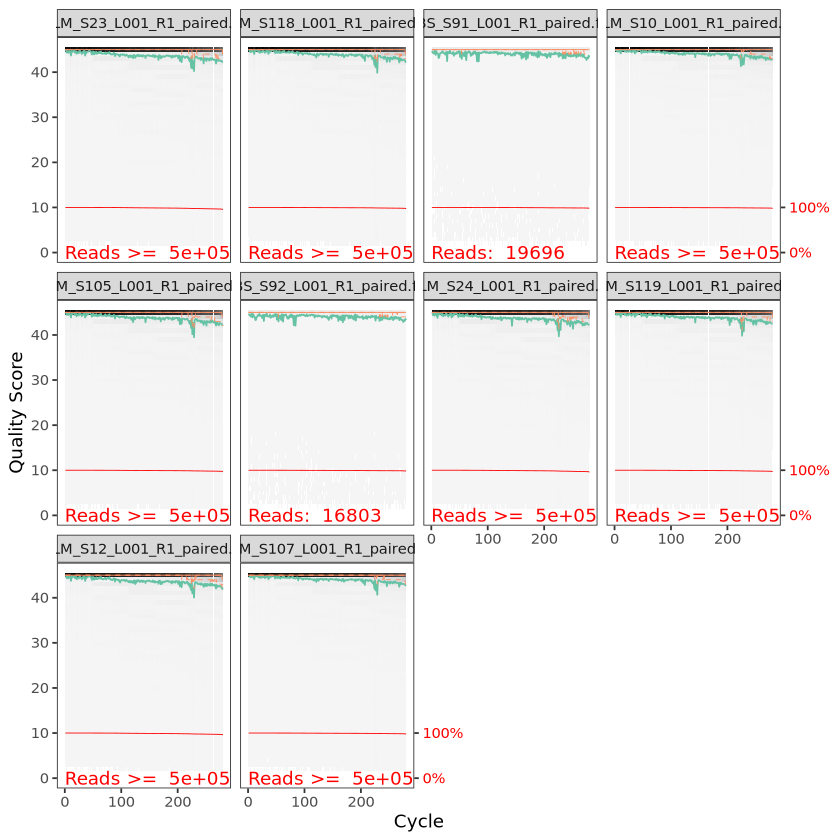

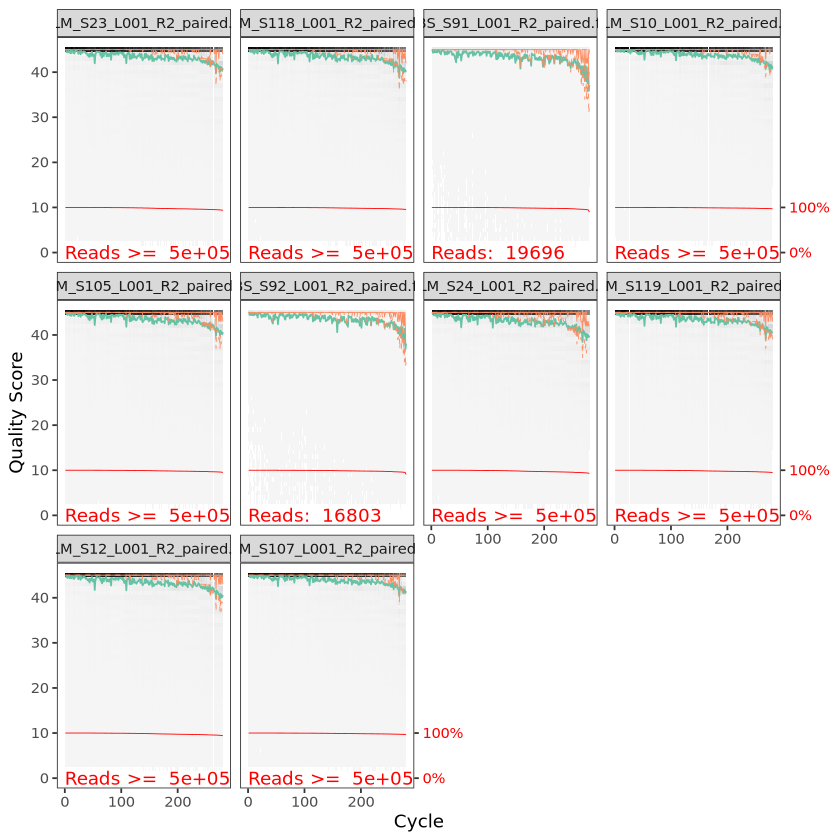

In [221]:
# Check quality of the reads
plotQualityProfile(fnFs[1:10])
plotQualityProfile(fnRs[1:10])

In [ ]:
# Filter and trim the reads
out <- filterAndTrim(fnFs, filtFs, fnRs, filtRs, trimLeft=c(20,17), truncLen=c(240,220),
              maxN=0, maxEE=c(3,4), truncQ=2, rm.phix=TRUE,
              compress=TRUE, multithread=TRUE)
head(out)

In [10]:
# Create output directory
output_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

In [11]:
path.rds <- output_dir
path.figures <- output_dir

In [11]:
saveRDS(out, file.path(output_dir, "filter_trim_summary.rds"))
saveRDS(filtFs, file.path(output_dir, "filtFs.rds"))
saveRDS(filtRs, file.path(output_dir, "filtRs.rds"))

In [12]:
# Learn error rates for forward and reverse reads
errF <- learnErrors(filtFs, multithread=TRUE)
saveRDS(errF,   file.path(output_dir, "errF.rds"))
errR <- learnErrors(filtRs, multithread=TRUE)
saveRDS(errR,   file.path(output_dir, "errR.rds"))

112869680 total bases in 513044 reads from 1 samples will be used for learning the error rates.
104147932 total bases in 513044 reads from 1 samples will be used for learning the error rates.


In [5]:
output_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"

# Individually load each .rds file
errF <- readRDS(file.path(output_dir, "errF.rds"))
errR <- readRDS(file.path(output_dir, "errR.rds"))
filter_trim_summary <- readRDS(file.path(output_dir, "filter_trim_summary.rds"))
filtFs <- readRDS(file.path(output_dir, "filtFs.rds"))
filtRs <- readRDS(file.path(output_dir, "filtRs.rds"))

In [9]:
# Denoise forward reads
dadaFs <- dada(filtFs, err=errF, multithread=TRUE)
saveRDS(dadaFs, file.path(output_dir, "dadaFs.rds"))

Sample 1 - 513044 reads in 90675 unique sequences.
Sample 2 - 580336 reads in 100365 unique sequences.
Sample 3 - 17034 reads in 1816 unique sequences.
Sample 4 - 491328 reads in 75283 unique sequences.
Sample 5 - 562995 reads in 86809 unique sequences.
Sample 6 - 14495 reads in 1736 unique sequences.
Sample 7 - 491971 reads in 57200 unique sequences.
Sample 8 - 445873 reads in 63950 unique sequences.
Sample 9 - 534166 reads in 91146 unique sequences.
Sample 10 - 439425 reads in 89976 unique sequences.
Sample 11 - 485071 reads in 78707 unique sequences.
Sample 12 - 504308 reads in 93880 unique sequences.
Sample 13 - 425732 reads in 77193 unique sequences.
Sample 14 - 465407 reads in 79216 unique sequences.
Sample 15 - 515886 reads in 76341 unique sequences.
Sample 16 - 508294 reads in 97454 unique sequences.
Sample 17 - 488282 reads in 89427 unique sequences.
Sample 18 - 430117 reads in 75142 unique sequences.
Sample 19 - 640065 reads in 76328 unique sequences.
Sample 20 - 574871 reads

Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”
Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”
Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”
Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”


In [6]:
# Denoise reverse reads
dadaRs <- dada(filtRs, err=errR, multithread=TRUE)
saveRDS(dadaRs, file.path(output_dir, "dadaRs.rds"))

Sample 1 - 513044 reads in 50468 unique sequences.
Sample 2 - 580336 reads in 54877 unique sequences.
Sample 3 - 17034 reads in 1553 unique sequences.
Sample 4 - 491328 reads in 40617 unique sequences.
Sample 5 - 562995 reads in 47771 unique sequences.
Sample 6 - 14495 reads in 1278 unique sequences.
Sample 7 - 491971 reads in 38142 unique sequences.
Sample 8 - 445873 reads in 36817 unique sequences.
Sample 9 - 534166 reads in 50425 unique sequences.
Sample 10 - 439425 reads in 43610 unique sequences.
Sample 11 - 485071 reads in 45588 unique sequences.
Sample 12 - 504308 reads in 49165 unique sequences.
Sample 13 - 425732 reads in 40748 unique sequences.
Sample 14 - 465407 reads in 41275 unique sequences.
Sample 15 - 515886 reads in 47390 unique sequences.
Sample 16 - 508294 reads in 50120 unique sequences.
Sample 17 - 488282 reads in 48946 unique sequences.
Sample 18 - 430117 reads in 40208 unique sequences.
Sample 19 - 640065 reads in 52903 unique sequences.
Sample 20 - 574871 reads 

Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”


In [7]:
# Merge paired reads
mergers <- mergePairs(dadaFs, filtFs, dadaRs, filtRs, verbose=TRUE)
head(mergers[[1]])
length(mergers)
saveRDS(mergers, file.path(output_dir, "mergers.rds"))

437136 paired-reads (in 6449 unique pairings) successfully merged out of 498271 (in 35701 pairings) input.

491549 paired-reads (in 7473 unique pairings) successfully merged out of 564029 (in 43163 pairings) input.

16941 paired-reads (in 195 unique pairings) successfully merged out of 16990 (in 200 pairings) input.

434631 paired-reads (in 5452 unique pairings) successfully merged out of 479050 (in 28332 pairings) input.

487253 paired-reads (in 6669 unique pairings) successfully merged out of 549434 (in 33713 pairings) input.

14022 paired-reads (in 190 unique pairings) successfully merged out of 14439 (in 199 pairings) input.

450064 paired-reads (in 4158 unique pairings) successfully merged out of 484364 (in 18385 pairings) input.

388346 paired-reads (in 4686 unique pairings) successfully merged out of 436226 (in 23816 pairings) input.

454419 paired-reads (in 5870 unique pairings) successfully merged out of 521031 (in 36091 pairings) input.

361569 paired-reads (in 6638 unique pa

,sequence,abundance,forward,reverse,nmatch,nmismatch,nindel,prefer,accept
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<lgl>
1,AAAGCCTGATGCAGCAACGCCGCGTGAGCGATGAAGGCCTTCGGGTCGTAAAGCTCTGTCCTCAAGGAAGATAATGACGGTACTTGAGGAGGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCTAGCGTTATCCGGAATTACTGGGCGTAAAGGGTGCGTAGGTGGTTTCTTAAGTCAGAGGTGAAAGGCTACGGCTCAACCGTAGTAAGCCTTTGAAACTGGGAAACTTGAGTGCAGGAGAGGAGAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTTGCGAAGGCGGCTCTCTGGACTGTAACTGACACTGAGGCACGAAAG,10390,1,1,60,0,0,1,TRUE
2,AAAGCCTGATGGTGCGACGCCGCGTGGGGGAGGAAGGTCTTCGGATTGTAAACCCCTGTCATGTGGGAGCAAGACTTCGGTTTGATAGTACCACAAGAGGAAGAGACGGCAAACTCTGTGCCAGCAGCCGCGGTAATACAGAGGTCTCAAGCGTTGTTCGGAATCACTGGGCGTAAAGGGTACGTAGGCGGCATCATAAGTCGTGCGTGAAAGGCAGGGGCTCAACCTCTGGAGTGCGCGTGATACTGTGATGCTGGAGTAATGGAGGGGGAACCGGAATTCTTGGTGTAGCAGTGAAATGCGTAGATATCAAGAAGAAGACTCGTGGCGAAGGCGGGTTCCTGGACATTTACTGACGCTGAGGTACGAAGG,7238,3,4,51,0,0,2,TRUE
3,AAAGCCTGATGCAGCAACGCCGCGTGAGCGATGAAGGCCTTCGGGTCGTAAAGCTCTGTCCTCAAGGAAGATAATGACGGTACTTGAGGAGGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCTAGCGTTATCCGGAATTACTGGGCGTAAAGGGTGCGTAGGCGGTCTTTCAAGCCAGAAGTGAAAGGCTACGGCTCAACCGTAGTAAGCTTTTGGAACTGTAAGACTTGAGTGCAGGAGAGGAGAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTAGCGAAGGCGGCTCTCTGGACTGTAACTGACGCTGAGGCACGAAAG,6823,2,7,60,0,0,2,TRUE
4,GACGACTGAACCAGCCATGCCGCGTGAAGGTCACGGCCCTATGGGTCTTAAACTTCTTTTGTAAGGGAGCAATAAGTCTCACGTGTGGGATGATGAGAGTACCTTACGAATAAGCATCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGGGGATGCAAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGCGTCTTAAGTCAGCGGTGAAATTTAGGGGCTCAACCTCTACCGTGCCGTTGATACTGGGATGCTGGAATGCGGATGCCGTGGGAGGAATGTGTGGTGTAGCGGTGAAATGCATAGATATCACACAGAACACCGATTGCGAAGGCATCTCACGAATCCGCTATTGACGCTGAGGCACGAAAG,5084,4,10,40,0,0,2,TRUE
5,AAAGCCTGACCGAGCAACGCCGCGTGAATGATGAAGGCCTTCGGGTTGTAAAATTCTGTTATAAGGGAAGAACGACTTTAGTAGGAAATGGCTAAAGTGTGACGGTACCTTATGAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGAGCGCGCAGGTGGTTGATTAAGTCTGATGTGAAAGCCCACGGCTTAACCGTGGAGGGTCATTGGAAACTGGTCGACTTGAGTGCAGAAGAGGGAAGTGGAATTCCATGTGTAGCGGTGAAATGCGTAGAGATATGGAGGAACACCAGTGGCGAAGGCGGCTTCCTGGTCTGTAACTGACACTGAGGCGCGAAAG,4898,5,8,34,0,0,2,TRUE
6,AAAGCCTGATGCAGCAACGCCGCGTGAGCGATGAAGGCCTTCGGGTCGTAAAGCTCTGTCCTCAAGGAAGATAATGACGGTACTTGAGGAGGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCTAGCGTTATCCGGATTTACTGGGCGTAAAGGGTGCGTAGGCGGTCTTTCAAGTCAGGAGTGAAAGGCTACGGCTCAACCGTAGTAAGCTCTTGAAACTGTAAGACTTGAGTGCAGGAGAGGAGAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTTGCGAAGGCGGCTCTCTGGACTGTAACTGACGCTGAGGCACGAAAG,4300,6,14,60,0,0,1,TRUE


[1] 162

1165D1LM 1165D3LM 1179-PBS 1179D1LM 1179D3LM 1217-PBS 
  437136   491549    16941   434631   487253    14022

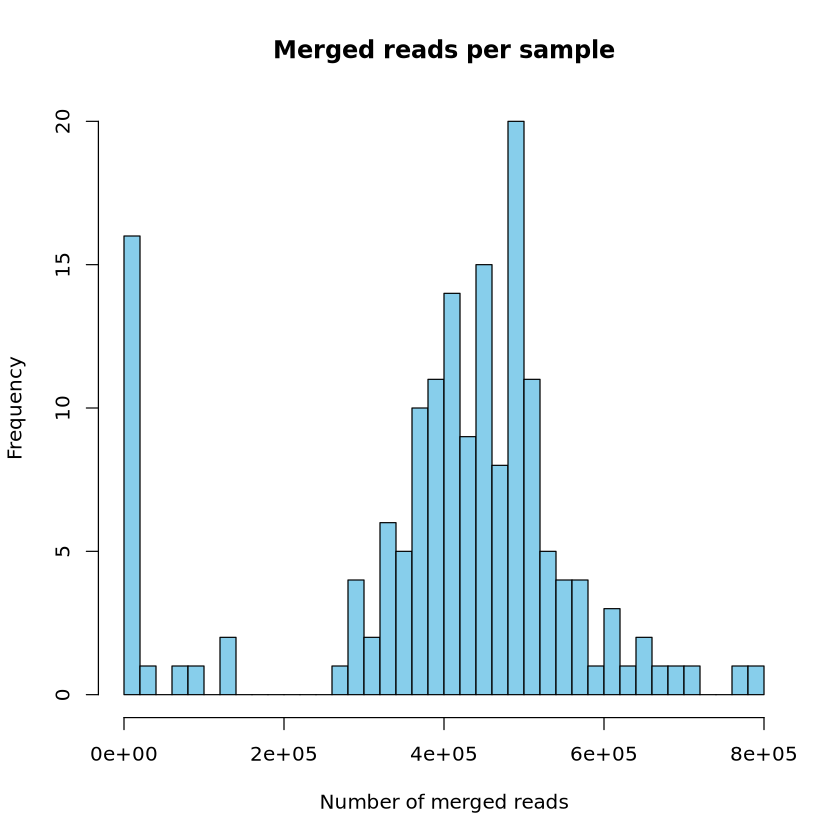

In [8]:
merged_counts <-sapply(mergers, function(x) sum(x$abundance)) #How many reads were successfully merged per sample!
head(merged_counts) #Quick table of the total merged reads per sample.

#visualize the distribution of merged reads
hist(merged_counts, main = "Merged reads per sample",
     xlab = "Number of merged reads", ylab = "Frequency",
     col = "skyblue", breaks = 30)

In [14]:
# Remove chimeras
seqtab <- makeSequenceTable(mergers)#Create a sequence table
dim(seqtab)
seqtab2 <- seqtab[,nchar(colnames(seqtab)) %in% 250:258]
sum(seqtab2)/sum(seqtab)
saveRDS(seqtab, file.path(output_dir, "seqtab.rds"))

[1]    162 151077

[1] 4.102491e-05

In [15]:
table(nchar(getSequences(seqtab)))
length_table <- table(nchar(getSequences(seqtab)))
saveRDS(length_table, file.path(output_dir, "length_table.rds"))


  220   221   222   223   224   225   226   227   228   229   230   231   232 
 2903   134  2903   360   177    58    34   118    39    25    35    33    28 
  233   234   235   236   237   238   239   240   241   242   243   244   245 
   21    24    70    34    27    22    19    11    13    27    21    17    18 
  246   247   248   249   250   251   252   253   254   255   256   257   258 
   27   112    15    21    34    22    35    38    27    34    49     7    11 
  259   260   261   262   263   264   265   266   267   268   269   270   271 
   14    11    18    21    36    79    14    24    22    16    12    17    20 
  272   273   274   275   276   277   278   279   280   281   282   283   284 
   39    10     7     3    26    49    13    37    20    10    15    13    14 
  285   286   287   288   289   290   291   292   293   294   295   296   297 
   15    19    20    49    20    14    36    39    18    19    13    79    12 
  298   299   300   301   302   303   304   305   3

In [ ]:
#Remove bimeras
seqtab.nochim <- removeBimeraDenovo(seqtab, method="consensus", multithread=TRUE, verbose=TRUE)
dim(seqtab.nochim)
sum(seqtab.nochim)/sum(seqtab)
saveRDS(dim(seqtab.nochim), file.path(output_dir, "seqtab_nochim_dim.rds"))
saveRDS(sum(seqtab.nochim) / sum(seqtab), file.path(output_dir, "seqtab_nochim_ratio.rds"))
saveRDS(seqtab.nochim, file.path(output_dir, "seqtab_nochim.rds"))

In [18]:
output_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
errF <- readRDS(file.path(output_dir, "errF.rds"))
errR <- readRDS(file.path(output_dir, "errR.rds"))
filtFs <- readRDS(file.path(output_dir, "filtFs.rds"))
filtRs <- readRDS(file.path(output_dir, "filtRs.rds"))
out <- readRDS(file.path(output_dir, "filter_trim_summary.rds"))
dadaFs <- readRDS(file.path(output_dir, "dadaFs.rds"))
dadaRs <- readRDS(file.path(output_dir, "dadaRs.rds"))
length_table <- readRDS(file.path(output_dir, "length_table.rds"))
mergers <- readRDS(file.path(output_dir, "mergers.rds"))
seqtab <- readRDS(file.path(output_dir, "seqtab.rds"))
seqtab_nomock <- readRDS(file.path(output_dir, "seqtab_nomock.rds"))
seqtab_nochim_dim <- readRDS(file.path(output_dir, "seqtab_nochim_dim.rds"))
seqtab_nochim_ratio <- readRDS(file.path(output_dir, "seqtab_nochim_ratio.rds"))
taxa <- readRDS(file.path(output_dir, "taxa_species.rds"))
taxa_nomock <- readRDS(file.path(output_dir, "taxa_nomock.rds"))
taxa <- readRDS(file.path(output_dir, "taxa_assignments.rds"))
taxa_filtered <- readRDS(file.path(output_dir, "taxa_wo_chloroplast_mitochondria.rds"))
taxa_nomock <- readRDS(file.path(output_dir , "taxa_nomock_species.rds"))
seqtab.nochim <- readRDS(file.path(output_dir, "seqtab_nochim.rds"))
seqtab_mockA <- readRDS(file.path(output_dir, "seqtab_mockA.rds"))

In [14]:
# Step 1: Convert filter/trim output to a clean data frame
filter_df <- as.data.frame(out) %>%
  rownames_to_column(var = "File") %>%
  mutate(
    Percent_Retained = round(100 * reads.out / reads.in, 2)
  )

# Optional: standardize File column if needed
filter_df$File <- basename(filter_df$File)

# Step 2: Also standardize filenames in fastq_stats_df
fastq_stats_df$File <- basename(fastq_stats_df$File)

# Step 3: Merge filter stats with length stats
combined_df <- left_join(fastq_stats_df, filter_df, by = "File")

# Step 4: Save to CSV
write.csv(combined_df, file.path(output_dir, "fastq_summary_stats.csv"), row.names = FALSE)


In [190]:
# Read the CSV
combined_df <- read.csv(file.path(output_dir, "fastq_summary_stats.csv"))

# Define mock patterns
mockA_pattern <- "mock-synthetic-ZYMO-1|mock-synthetic-ZYMO-2|mock-synthetic-ZYMO-3"
mockB_pattern <- "mock-synthetic-ZYMO-4|mock-synthetic-ZYMO-5"
mock_all_pattern <- "mock-synthetic-ZYMO"

# Subset rows by pattern match in the File column
mockA_df <- combined_df %>% filter(grepl(mockA_pattern, File))
mockB_df <- combined_df %>% filter(grepl(mockB_pattern, File))
mock_all_df <- combined_df %>% filter(grepl(mock_all_pattern, File))

# Sum Total_Sequences (before chimera removal)
total_reads_mockA <- sum(mockA_df$Total_Sequences, na.rm = TRUE)
total_reads_mockB <- sum(mockB_df$Total_Sequences, na.rm = TRUE)
total_reads_mock_all <- sum(mock_all_df$Total_Sequences, na.rm = TRUE)

# Output the results
cat("Total input reads in MOCK A:", total_reads_mockA, "\n")
cat("Total input reads in MOCK B:", total_reads_mockB, "\n")
cat("Total input reads in MOCK A + B:", total_reads_mock_all, "\n")


Total input reads in MOCK A: 5432420 
Total input reads in MOCK B: 2420514 
Total input reads in MOCK A + B: 7852934 


In [25]:
# Track read retention through the pipeline
getN <- function(x) sum(getUniques(x))
track <- cbind(out, sapply(dadaFs, getN), sapply(dadaRs, getN), sapply(mergers, getN), rowSums(seqtab.nochim))
colnames(track) <- c("input", "filtered", "denoisedF", "denoisedR", "merged", "nonchim")
rownames(track) <- sample.names
head(track)
write.table(track, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/track_reads_summary.csv", row.names = TRUE, col.names = NA, sep = ",", dec = ".", qmethod = "double")

,input,filtered,denoisedF,denoisedR,merged,nonchim
1165D1LM,609025,513044,502356,508396,437136,412053
1165D3LM,676674,580336,568862,574968,491549,454124
1179-PBS,19696,17034,17001,17003,16941,16941
1179D1LM,564157,491328,482674,487156,434631,408342
1179D3LM,658846,562995,553690,558238,487253,447041
1217-PBS,16803,14495,14442,14489,14022,13998


In [46]:
library(dplyr)

# Read original track reads (short or full rownames)
track_reads <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/track_reads_summary.csv", row.names = 1)
track_reads$Original_ID <- rownames(track_reads)

# Manual map (Short_ID → Corrected Sample_ID)
map_df <- data.frame(
  Short_ID = c(
    "1179-PBS", "1217-PBS", "1359D1LM", "1359D3LM", "302-PBS", "6767-PBS",
    "control-extraction-N-CONTROL-1", "control-extraction-N-CONTROL-2", "control-extraction-N-CONTROL-3",
    "control-extraction-N-CONTROL-4", "control-extraction-N-CONTROL-5",
    "control-te-1", "control-te-2", "control-te-3", "control-te-4", "control-te-5",
    "mock-synthetic-ZYMO-1", "mock-synthetic-ZYMO-2", "mock-synthetic-ZYMO-3",
    "mock-synthetic-ZYMO-4", "mock-synthetic-ZYMO-5"
  ),
  Sample_ID = c(
    "1179D1LM-PBS", "1217D1LM-PBS", "1359D1LM", "1359D3LM", "302D1LM-PBS", "6767D1LM-PBS",
    "control-extraction-N-CONTROL-1", "control-extraction-N-CONTROL-2", "control-extraction-N-CONTROL-3",
    "control-extraction-N-CONTROL-4", "control-extraction-N-CONTROL-5",
    "control-te-1", "control-te-2", "control-te-3", "control-te-4", "control-te-5",
    "mock-synthetic-ZYMO-1", "mock-synthetic-ZYMO-2", "mock-synthetic-ZYMO-3",
    "mock-synthetic-ZYMO-4", "mock-synthetic-ZYMO-5"
  ),
  stringsAsFactors = FALSE
)

# Apply manual mapping — overwrite only where Short_ID is listed
track_reads <- track_reads %>%
  left_join(map_df, by = c("Original_ID" = "Short_ID")) %>%
  mutate(Sample_ID = ifelse(is.na(Sample_ID), Original_ID, Sample_ID))

# Clean and finalize
track_reads_final <- track_reads %>%
  select(Sample_ID, input, filtered, denoisedF, denoisedR, merged, nonchim)

# Ensure uniqueness
track_reads_final <- track_reads_final %>%
  distinct(Sample_ID, .keep_all = TRUE)

# Set rownames
rownames(track_reads_final) <- track_reads_final$Sample_ID
track_reads_final$Sample_ID <- NULL

# Save cleaned version
write.csv(track_reads_final, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/track_reads_summary_fullID.csv")


In [52]:
#### Adding track table to the metadata
# Load metadata and cleaned track reads
metadata <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/Cow_FecalMicrobiome_Metadata1.csv", stringsAsFactors = FALSE)
track_reads_final <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/track_reads_summary_fullID.csv", row.names = 1)
track_reads_final$Sample_ID <- rownames(track_reads_final)

# Correct merge
merged_metadata <- left_join(metadata, track_reads_final, by = "Sample_ID")

# Save
write.csv(merged_metadata, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Cow_FecalMicrobiome_Metadata_with_reads.csv", row.names = FALSE)


In [84]:
# Add read retention
# Load merged metadata
metadata <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Cow_FecalMicrobiome_Metadata_with_reads.csv", stringsAsFactors = FALSE)

# Calculate and add read retention (%)
metadata <- metadata %>%
  mutate(
    input = as.numeric(input),
    nonchim = as.numeric(nonchim),
    read_retention = round((nonchim / input) * 100, 2)
  )

# Save updated metadata
write.csv(metadata, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Cow_FecalMicrobiome_Metadata_with_reads.csv", row.names = FALSE)


In [1]:


# Load merged metadata
metadata <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Cow_FecalMicrobiome_Metadata_with_reads.csv", stringsAsFactors = FALSE)

# Ensure input and nonchim are numeric, calculate read retention (%)
metadata <- metadata %>%
  mutate(
    input = as.numeric(input),
    nonchim = as.numeric(nonchim),
    read_retention = round((nonchim / input) * 100, 2)
  )

# Total raw reads
total_raw <- sum(metadata$input, na.rm = TRUE)
raw_range <- range(metadata$input, na.rm = TRUE)
mean_raw <- mean(metadata$input, na.rm = TRUE)

# Total non-chimeric reads
total_nonchim <- sum(metadata$nonchim, na.rm = TRUE)
nonchim_range <- range(metadata$nonchim, na.rm = TRUE)
mean_nonchim <- mean(metadata$nonchim, na.rm = TRUE)

# Per-sample-type summary with read retention
stepwise_summary <- metadata %>%
  group_by(Sample_Type) %>%
  summarise(
    input_mean = round(mean(input, na.rm = TRUE)), 
    input_min = min(input, na.rm = TRUE), 
    input_max = max(input, na.rm = TRUE),
    nonchim_mean = round(mean(nonchim, na.rm = TRUE)), 
    nonchim_min = min(nonchim, na.rm = TRUE), 
    nonchim_max = max(nonchim, na.rm = TRUE),
    retention_mean = round(mean(read_retention, na.rm = TRUE), 2),
    retention_min = round(min(read_retention, na.rm = TRUE), 2),
    retention_max = round(max(read_retention, na.rm = TRUE), 2),
    .groups = "drop"
  )

# Save summary
write.csv(stepwise_summary, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/stepwise_summary_by_SampleType.csv", row.names = FALSE)

# View summary
print(stepwise_summary)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# A tibble: 5 × 10
  Sample_Type           input_mean input_min input_max nonchim_mean nonchim_min
  <chr>                      <dbl>     <dbl>     <dbl>        <dbl>       <dbl>
1 Environmental_Control      19971     16803     23567        16910       13998
2 Extraction_Control         18059       915     35044        15255         692
3 Feces                     586861     12821    883019       403813        6166
4 Mock                      785293    329700    995432       628978      286569
5 Reagent_Control            19439     16939     21511        16372       14496
# ℹ 4 more variables: nonchim_max <dbl>, retention_mean <dbl>,
#   retention_min <dbl>, retention_max <dbl>


In [7]:
# Ensure read_retention is calculated
metadata <- metadata %>%
  mutate(
    input = as.numeric(input),
    nonchim = as.numeric(nonchim),
    read_retention = round((nonchim / input) * 100, 2)
  )

# Run Kruskal–Wallis tests
kw_input <- kruskal.test(input ~ Sample_Type, data = metadata)
kw_nonchim <- kruskal.test(nonchim ~ Sample_Type, data = metadata)
kw_retention <- kruskal.test(read_retention ~ Sample_Type, data = metadata)

# Create summary data frames
kw_input_df <- data.frame(
  Metric = "input",
  Chi_sq = as.numeric(kw_input$statistic),
  df = as.integer(kw_input$parameter),
  p_value = kw_input$p.value
)

kw_nonchim_df <- data.frame(
  Metric = "nonchim",
  Chi_sq = as.numeric(kw_nonchim$statistic),
  df = as.integer(kw_nonchim$parameter),
  p_value = kw_nonchim$p.value
)

kw_retention_df <- data.frame(
  Metric = "read_retention",
  Chi_sq = as.numeric(kw_retention$statistic),
  df = as.integer(kw_retention$parameter),
  p_value = kw_retention$p.value
)

# Combine all results
kw_results <- bind_rows(kw_input_df, kw_nonchim_df, kw_retention_df)

# Print and save
print(kw_results)
write.csv(kw_results, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/KruskalWallis_results_all_metrics.csv", row.names = FALSE)


          Metric   Chi_sq df      p_value
1          input 43.78540  4 7.109150e-09
2        nonchim 43.45298  4 8.333708e-09
3 read_retention 51.88844  4 1.455570e-10


In [8]:
library(FSA)
library(dplyr)

# Make sure read_retention is calculated
metadata <- metadata %>%
  mutate(
    input = as.numeric(input),
    nonchim = as.numeric(nonchim),
    read_retention = round((nonchim / input) * 100, 2)
  )

# ---- Dunn Test: input ----
dunn_input <- dunnTest(input ~ Sample_Type, data = metadata, method = "bh")$res
dunn_input$Metric <- "input"

# ---- Dunn Test: nonchim ----
dunn_nonchim <- dunnTest(nonchim ~ Sample_Type, data = metadata, method = "bh")$res
dunn_nonchim$Metric <- "nonchim"

# ---- Dunn Test: read_retention ----
dunn_retention <- dunnTest(read_retention ~ Sample_Type, data = metadata, method = "bh")$res
dunn_retention$Metric <- "read_retention"

# ---- Combine all results ----
dunn_combined <- bind_rows(dunn_input, dunn_nonchim, dunn_retention)

# ---- Save to CSV ----
write.csv(dunn_combined, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/dunn_posthoc_combined.csv", row.names = FALSE)

# Optional: also save separately
write.csv(dunn_input, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/dunn_input_posthoc.csv", row.names = FALSE)
write.csv(dunn_nonchim, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/dunn_nonchim_posthoc.csv", row.names = FALSE)
write.csv(dunn_retention, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/dunn_retention_posthoc.csv", row.names = FALSE)


Warning message:
“Sample_Type was coerced to a factor.”
Warning message:
“Some rows deleted from 'x' and 'g' because missing data.”
Warning message:
“Sample_Type was coerced to a factor.”
Warning message:
“Some rows deleted from 'x' and 'g' because missing data.”
Warning message:
“Sample_Type was coerced to a factor.”
Warning message:
“Some rows deleted from 'x' and 'g' because missing data.”


Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing 

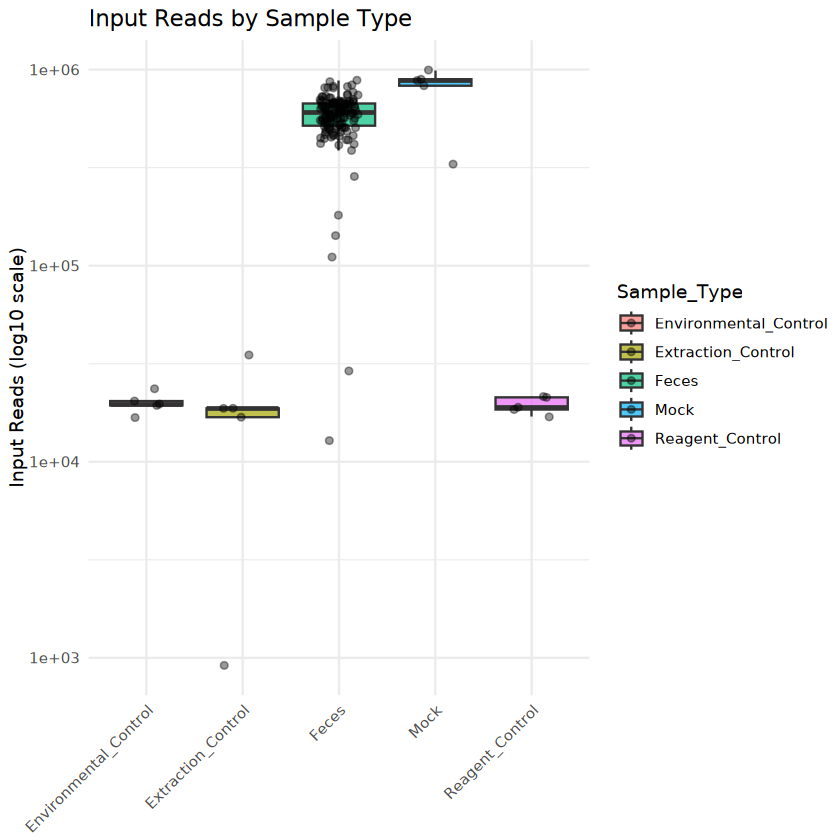

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


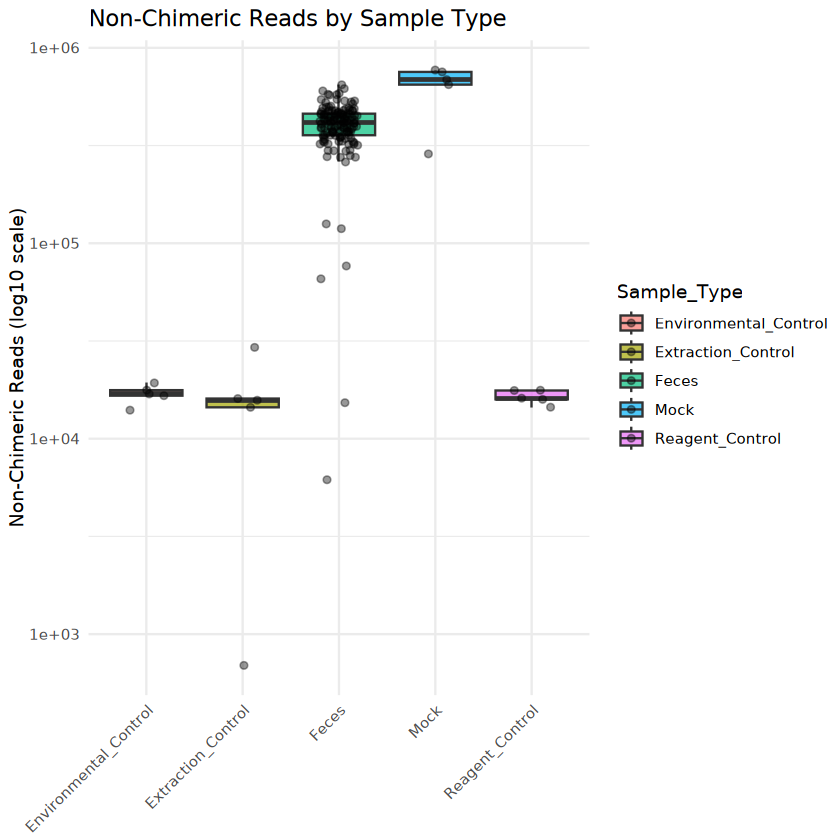

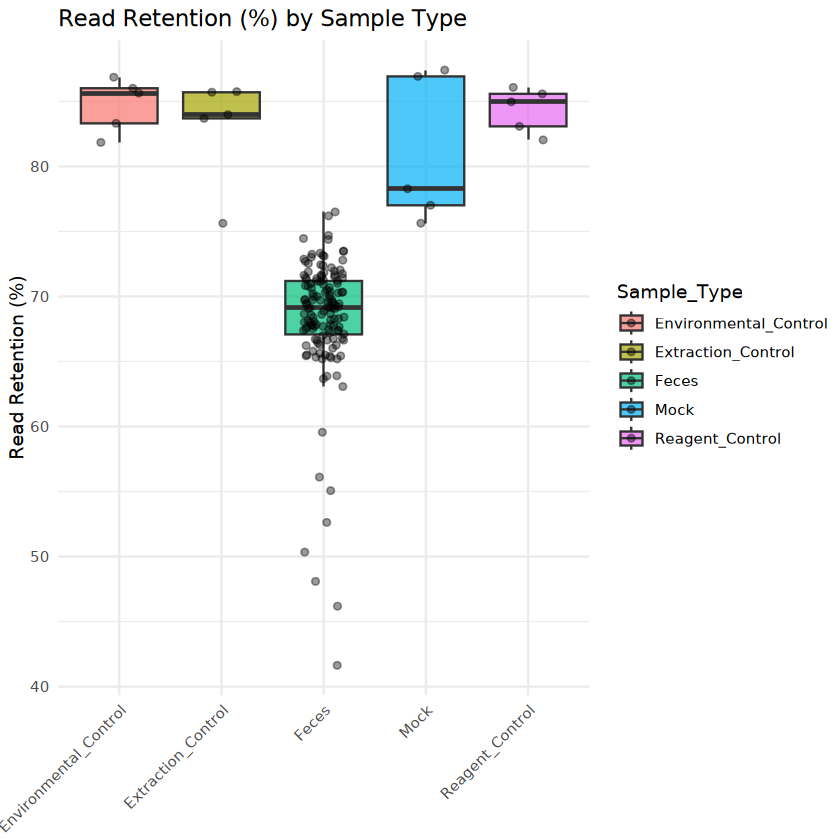

In [9]:

metadata <- metadata %>%
  mutate(
    input = as.numeric(input),
    nonchim = as.numeric(nonchim),
    read_retention = round((nonchim / input) * 100, 2)
  )

# --- Input reads plot ---
p_input <- ggplot(metadata, aes(x = Sample_Type, y = input, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.4) +
  scale_y_log10() +
  labs(title = "Input Reads by Sample Type", y = "Input Reads (log10 scale)", x = NULL) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# --- Non-chimeric reads plot ---
p_nonchim <- ggplot(metadata, aes(x = Sample_Type, y = nonchim, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.4) +
  scale_y_log10() +
  labs(title = "Non-Chimeric Reads by Sample Type", y = "Non-Chimeric Reads (log10 scale)", x = NULL) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# --- Read retention plot ---
p_retention <- ggplot(metadata, aes(x = Sample_Type, y = read_retention, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.4) +
  labs(title = "Read Retention (%) by Sample Type", y = "Read Retention (%)", x = NULL) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# --- Save all plots individually ---
ggsave("/scratch/negishi/ldas/COW_INFLAMMATION/Figures/input_reads_boxplot.png", p_input, width = 8, height = 6)
ggsave("/scratch/negishi/ldas/COW_INFLAMMATION/Figures/nonchim_reads_boxplot.png", p_nonchim, width = 8, height = 6)
ggsave("/scratch/negishi/ldas/COW_INFLAMMATION/Figures/read_retention_boxplot.png", p_retention, width = 8, height = 6)

# --- Print ---
print(p_input)
print(p_nonchim)
print(p_retention)


Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing 

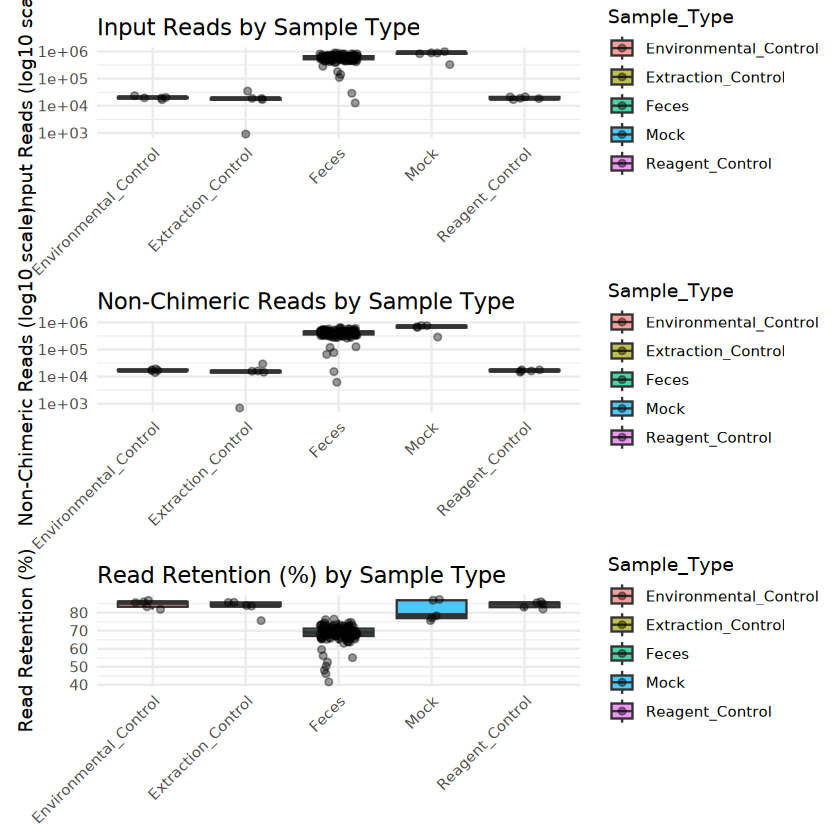

In [10]:
library(patchwork)

combined_plot <- p_input / p_nonchim / p_retention + plot_layout(ncol = 1)
ggsave("/scratch/negishi/ldas/COW_INFLAMMATION/Figures/combined_reads_boxplots.png", combined_plot, width = 8, height = 18)
print(combined_plot)


In [11]:
library(writexl)
library(dplyr)

# Paths
summary_path <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/stepwise_summary_by_SampleType.csv"
output_path <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/read_summary_with_statistics.xlsx"

# Read stepwise summary
summary_df <- read.csv(summary_path, stringsAsFactors = FALSE)

# Combine into list for Excel export
read_stats <- list(
  Stepwise_Summary = summary_df,
  Kruskal_Wallis = kw_results,
  Dunn_PostHoc = dunn_combined
)

# Write all sheets to Excel
write_xlsx(read_stats, output_path)



In [12]:
library(dplyr)
library(broom)
library(purrr)
library(writexl)

# Ensure required columns
metadata <- metadata %>%
  mutate(
    input = as.numeric(input),
    nonchim = as.numeric(nonchim),
    read_retention = round((nonchim / input) * 100, 2),
    Sample_Type = as.factor(Sample_Type)
  )

# Get all unique pairwise comparisons
pairwise_combos <- combn(levels(metadata$Sample_Type), 2, simplify = FALSE)

# Initialize list to hold results
anova_results <- map_dfr(pairwise_combos, function(pair) {
  subset_data <- metadata %>%
    filter(Sample_Type %in% pair) %>%
    droplevels()
  
  model <- aov(read_retention ~ Sample_Type, data = subset_data)
  tidy_model <- tidy(model)
  
  # Extract F and p
  f_val <- tidy_model$statistic[1]
  p_val <- tidy_model$p.value[1]
  
  # Calculate adjusted R²
  adj_r2 <- summary(lm(read_retention ~ Sample_Type, data = subset_data))$adj.r.squared
  
  tibble(
    Comparison = paste(pair, collapse = " vs "),
    F_value = f_val,
    p_value = p_val,
    Adjusted_R2 = round(adj_r2, 4)
  )
})

# Apply FDR correction
anova_results <- anova_results %>%
  mutate(FDR_p_value = p.adjust(p_value, method = "BH"))

# Save to Excel
write_xlsx(
  list(Pairwise_ANOVA_ReadRetention = anova_results),
  "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/pairwise_ANOVA_read_retention_FDR.xlsx"
)

# View results
print(anova_results)



Attaching package: ‘purrr’


The following object is masked from ‘package:ShortRead’:

    compose


The following object is masked from ‘package:GenomicRanges’:

    reduce


The following object is masked from ‘package:XVector’:

    compact


The following object is masked from ‘package:IRanges’:

    reduce


The following object is masked from ‘package:scales’:

    discard




# A tibble: 10 × 5
   Comparison                           F_value  p_value Adjusted_R2 FDR_p_value
   <chr>                                  <dbl>    <dbl>       <dbl>       <dbl>
 1 Environmental_Control vs Extraction…  0.722  4.20e- 1     -0.0319    6.00e- 1
 2 Environmental_Control vs Feces       50.9    4.45e-11      0.257     4.45e-10
 3 Environmental_Control vs Mock         1.86   2.10e- 1      0.0874    4.13e- 1
 4 Environmental_Control vs Reagent_Co…  0.0999 7.60e- 1     -0.111     7.60e- 1
 5 Extraction_Control vs Feces          39.9    3.18e- 9      0.213     1.06e- 8
 6 Extraction_Control vs Mock            0.363  5.64e- 1     -0.0762    6.26e- 1
 7 Extraction_Control vs Reagent_Contr…  0.476  5.10e- 1     -0.0619    6.26e- 1
 8 Feces vs Mock                        29.8    2.09e- 7      0.166     5.22e- 7
 9 Feces vs Reagent_Control             48.6    1.05e-10      0.249     5.24e-10
10 Mock vs Reagent_Control               1.55   2.48e- 1      0.058     4.13e- 1


In [13]:
library(dplyr)
library(broom)
library(purrr)
library(writexl)

# Prepare metadata (ensure numeric and factors)
metadata <- metadata %>%
  mutate(
    input = as.numeric(input),
    nonchim = as.numeric(nonchim),
    read_retention = round((nonchim / input) * 100, 2),
    Sample_Type = as.factor(Sample_Type)
  )

# Get pairwise combinations of Sample_Type
pairwise_combos <- combn(levels(metadata$Sample_Type), 2, simplify = FALSE)

# Initialize results list
glm_results <- map_dfr(pairwise_combos, function(pair) {
  subset_data <- metadata %>%
    filter(Sample_Type %in% pair) %>%
    droplevels()
  
  glm_model <- glm(read_retention ~ Sample_Type, data = subset_data, family = gaussian())
  tidy_model <- tidy(glm_model)
  
  # Get the contrast (Sample_Type2 vs Sample_Type1)
  contrast_row <- tidy_model %>%
    filter(term != "(Intercept)")
  
  # R² from linear version
  adj_r2 <- summary(lm(read_retention ~ Sample_Type, data = subset_data))$adj.r.squared
  
  tibble(
    Comparison = paste(pair, collapse = " vs "),
    Estimate = contrast_row$estimate,
    Std_Error = contrast_row$std.error,
    p_value = contrast_row$p.value,
    Adjusted_R2 = round(adj_r2, 4)
  )
})

# FDR correction
glm_results <- glm_results %>%
  mutate(FDR_p_value = p.adjust(p_value, method = "BH"))

# Save to Excel
write_xlsx(
  list(Pairwise_GLM_ReadRetention = glm_results),
  "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/pairwise_GLM_read_retention_FDR.xlsx"
)

# Print preview
print(glm_results)


# A tibble: 10 × 6
   Comparison                Estimate Std_Error  p_value Adjusted_R2 FDR_p_value
   <chr>                        <dbl>     <dbl>    <dbl>       <dbl>       <dbl>
 1 Environmental_Control vs…   -1.78       2.10 4.20e- 1     -0.0319    6.00e- 1
 2 Environmental_Control vs…  -16.4        2.31 4.45e-11      0.257     4.45e-10
 3 Environmental_Control vs…   -3.68       2.70 2.10e- 1      0.0874    4.13e- 1
 4 Environmental_Control vs…   -0.382      1.21 7.60e- 1     -0.111     7.60e- 1
 5 Extraction_Control vs Fe…  -14.7        2.32 3.18e- 9      0.213     1.06e- 8
 6 Extraction_Control vs Mo…   -1.90       3.15 5.64e- 1     -0.0762    6.26e- 1
 7 Extraction_Control vs Re…    1.40       2.03 5.10e- 1     -0.0619    6.26e- 1
 8 Feces vs Mock               12.8        2.34 2.09e- 7      0.166     5.22e- 7
 9 Feces vs Reagent_Control    16.1        2.30 1.05e-10      0.249     5.24e-10
10 Mock vs Reagent_Control      3.3        2.65 2.48e- 1      0.058     4.13e- 1


In [171]:
library(phyloseq)
library(vegan)

# 1. Extract distance matrix
bray_dist <- phyloseq::distance(ps, method = "bray")

# 2. Extract metadata
meta <- as(sample_data(ps), "data.frame")

# 3. Run PERMANOVA
permanova_result <- adonis2(bray_dist ~ Sample_Type, data = meta, permutations = 999)

# 4. View result
print(permanova_result)


Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

adonis2(formula = bray_dist ~ Sample_Type, data = meta, permutations = 999)
          Df SumOfSqs      R2      F Pr(>F)    
Model      5    9.874 0.24388 10.063  0.001 ***
Residual 156   30.613 0.75612                  
Total    161   40.487 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


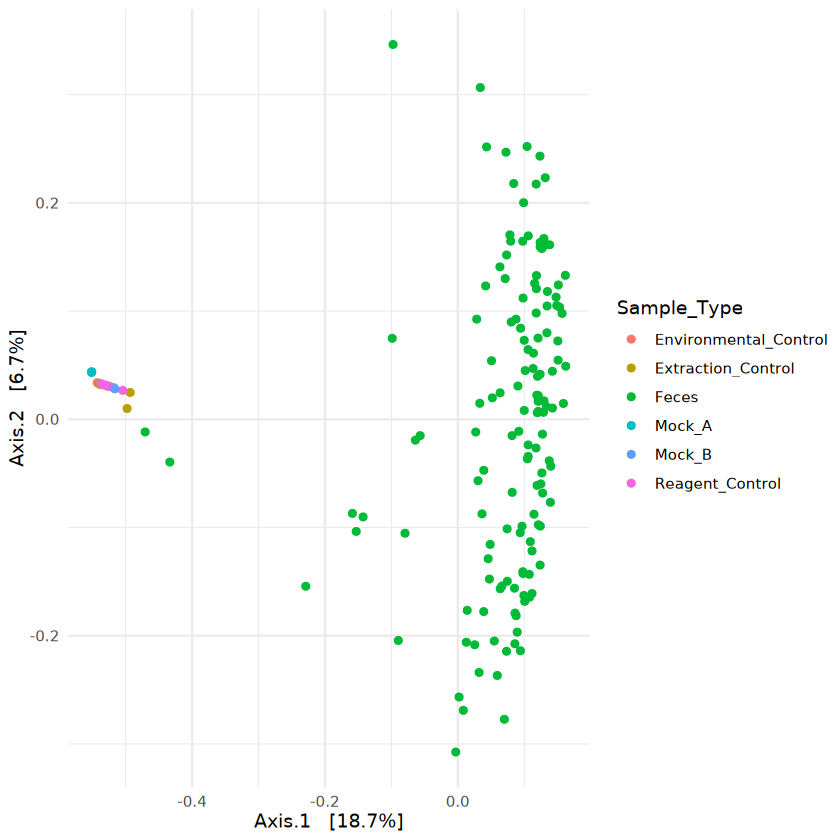

In [172]:
ord <- ordinate(ps, method = "PCoA", distance = "bray")
plot_ordination(ps, ord, color = "Sample_Type") + theme_minimal()


In [4]:
# Clean mock community

In [14]:
output_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
errF <- readRDS(file.path(output_dir, "errF.rds"))
errR <- readRDS(file.path(output_dir, "errR.rds"))
filtFs <- readRDS(file.path(output_dir, "filtFs.rds"))
filtRs <- readRDS(file.path(output_dir, "filtRs.rds"))
out <- readRDS(file.path(output_dir, "filter_trim_summary.rds"))
dadaFs <- readRDS(file.path(output_dir, "dadaFs.rds"))
dadaRs <- readRDS(file.path(output_dir, "dadaRs.rds"))
length_table <- readRDS(file.path(output_dir, "length_table.rds"))
mergers <- readRDS(file.path(output_dir, "mergers.rds"))
seqtab <- readRDS(file.path(output_dir, "seqtab.rds"))
seqtab_nochim_dim <- readRDS(file.path(output_dir, "seqtab_nochim_dim.rds"))
seqtab_nochim_ratio <- readRDS(file.path(output_dir, "seqtab_nochim_ratio.rds"))
taxa_mockA <- readRDS(file.path(output_dir, "taxa_mockA.rds"))
library(phyloseq)

In [8]:
# Define mock groups explicitly
mockA <- c("mock-synthetic-ZYMO-1", "mock-synthetic-ZYMO-2", "mock-synthetic-ZYMO-3")
mockB <- c("mock-synthetic-ZYMO-4", "mock-synthetic-ZYMO-5")
mock_all <- c(mockA, mockB)

In [13]:
library(ShortRead)

# Function to get read counts from FASTQ
get_read_count <- function(f) {
  fq <- readFastq(f)
  length(fq)
}

# Add read counts to file_info
file_info$reads <- sapply(rownames(file_info), get_read_count)

# Add mock group info
file_info$Group <- ifelse(grepl(paste(mockA, collapse="|"), rownames(file_info)), "MockA", "MockB")

# Summarize total reads and file size per group
library(dplyr)

mock_summary <- file_info %>%
  group_by(Group) %>%
  summarise(
    Total_Size_MB = sum(size_MB),
    Total_Reads = sum(reads)
  )

print(mock_summary)


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'X' in selecting a method for function 'sapply': error in evaluating the argument 'x' in selecting a method for function 'rownames': object 'file_info' not found


In [41]:
# Subset mockA samples
seqtab.nochim_mockA <- seqtab.nochim[rownames(seqtab.nochim) %in% mockA, ]

# Subset mockB samples
seqtab.nochim_mockB <- seqtab.nochim[rownames(seqtab.nochim) %in% mockB, ]

# Subset all mock samples
seqtab.nochim_mock_all <- seqtab.nochim[rownames(seqtab.nochim) %in% mock_all, ]

# Subset all non-mock samples (nomock)
nomock <- setdiff(rownames(seqtab.nochim), mock_all)
seqtab.nochim_nomock <- seqtab.nochim[nomock, ]


In [42]:
# Remove ASVs not present (zero abundance across all samples)
seqtab.nochim_mockA <- seqtab.nochim_mockA[, colSums(seqtab.nochim_mockA) > 0]
seqtab.nochim_mockB <- seqtab.nochim_mockB[, colSums(seqtab.nochim_mockB) > 0]
seqtab.nochim_nomock <- seqtab.nochim_nomock[, colSums(seqtab.nochim_nomock) > 0]

# Save cleaned mock tables
saveRDS(seqtab.nochim_mockA, file.path(output_dir, "seqtab.nochim_mockA.rds"))
saveRDS(seqtab.nochim_mockB, file.path(output_dir, "seqtab.nochim_mockB.rds"))
saveRDS(seqtab.nochim_nomock, file.path(output_dir, "seqtab.nochim_nomock.rds"))


In [43]:
dim(seqtab.nochim)
dim(seqtab.nochim_nomock)
dim(seqtab.nochim_mockA)
dim(seqtab.nochim_mockB)

[1]   162 33053

[1]   157 31716

[1]    3 1380

[1]   2 219

In [44]:
asv_seqs_mockA <- colnames(seqtab.nochim_mockA)
asv_seqs_mockB <- colnames(seqtab.nochim_mockB)
asv_seqs_nomock <- colnames(seqtab.nochim_nomock)

In [45]:
# Assign Genus-level taxonomy for mockA
taxa_mockA <- assignTaxonomy(
  asv_seqs_mockA,
  "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/mockA_genus_reference.fasta",
  multithread = TRUE
)
saveRDS(taxa_mockA, file.path(output_dir, "taxa_mockA.rds"))
# Assign Species-level taxonomy for mockB
taxa_mockB <- assignSpecies(
  asv_seqs_mockB,
  refFasta = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/zymo_species_formatted (2).fasta"
)
saveRDS(taxa_mockB, file.path(output_dir, "taxa_mockB.rds"))


In [199]:
# Assign taxonomy
taxa_nomock <- assignTaxonomy(
  asv_seqs_nomock,
  "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/silva_nr99_v138.2_toGenus_trainset.fa",
  multithread = TRUE
)

# Save the taxonomy table
saveRDS(taxa_nomock, file.path(output_dir, "taxa_nomock.rds"))

In [200]:
taxa.print <- taxa_nomock
rownames(taxa.print) <- NULL
head(taxa.print)

Kingdom,Phylum,Class,Order,Family,Genus
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Romboutsia
Bacteria,Bacillota,Bacilli,Erysipelotrichales,Erysipelotrichaceae,Turicibacter
Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium
Bacteria,Bacillota,Clostridia,Clostridiales,Clostridiaceae,Clostridium
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Paeniclostridium
Bacteria,Bacillota,Bacilli,Lactobacillales,Listeriaceae,Listeria


In [204]:
# Assign taxonomy_species
taxa_nomock_species <- addSpecies(
  taxa_nomock,
  "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/silva_v138.2_assignSpecies.fa"
)
# Step 3: Save
saveRDS(taxa_nomock_species, file.path(output_dir, "taxa_nomock_species.rds"))

In [19]:
taxa_nomock_species <- readRDS(file.path(output_dir, "taxa_nomock_species.rds"))

In [20]:
taxa.print <- taxa_nomock_species
rownames(taxa.print) <- NULL
head(taxa.print)

Kingdom,Phylum,Class,Order,Family,Genus,Species
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Romboutsia,NA
Bacteria,Bacillota,Bacilli,Erysipelotrichales,Erysipelotrichaceae,Turicibacter,NA
Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,NA
Bacteria,Bacillota,Clostridia,Clostridiales,Clostridiaceae,Clostridium,NA
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Paeniclostridium,NA
Bacteria,Bacillota,Bacilli,Lactobacillales,Listeriaceae,Listeria,NA


In [21]:
# Check number of chloroplast sequences
sum(taxa_nomock_species[, "Order"] == "Chloroplast", na.rm = TRUE)

# Check number of mitochondrial sequences
sum(taxa_nomock_species[, "Family"] == "Mitochondria", na.rm = TRUE)

# Subset chloroplast and mitochondrial ASVs correctly
chloroplast_taxa <- taxa_nomock_species[taxa_nomock_species[, "Order"] == "Chloroplast", , drop = FALSE]
mitochondria_taxa <- taxa_nomock_species[taxa_nomock_species[, "Family"] == "Mitochondria", , drop = FALSE]

# View if any exist
if (nrow(chloroplast_taxa) > 0) print(chloroplast_taxa)
if (nrow(mitochondria_taxa) > 0) print(mitochondria_taxa)


[1] 62

[1] 240

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [23]:
taxa_mockA <- readRDS(file.path(output_dir, "taxa_mockA.rds"))

In [24]:
# Check for Chloroplast and Mitochondria in MockA
sum(taxa_mockA[, "Order"] == "Chloroplast", na.rm = TRUE)

sum(taxa_mockA[, "Family"] == "Mitochondria", na.rm = TRUE)


chloroplast_taxa_mockA <- taxa_mockA[taxa_mockA[, "Order"] == "Chloroplast", , drop = FALSE]
mitochondria_taxa_mockA <- taxa_mockA[taxa_mockA[, "Family"] == "Mitochondria", , drop = FALSE]
# Mock B is all fine as it have genus and species rank

[1] 9

[1] 0

In [25]:
# Remove chloroplast and mitochondrial DNA from taxa_nomock
taxa_nomock_filtered <- taxa_nomock_species[!(taxa_nomock_species[, "Order"] == "Chloroplast" | taxa_nomock[, "Family"] == "Mitochondria"), ]
saveRDS(taxa_nomock_filtered, file.path(output_dir, "taxa_nomock_wo_chloroplast_mitochondria.rds")) 
# taxa_nomock_filtered will be used for following steps

In [26]:
taxa.print <- taxa_nomock_filtered
rownames(taxa.print) <- NULL
head(taxa.print)
# View if any exist
if (nrow(chloroplast_taxa) > 0) print(chloroplast_taxa)
if (nrow(mitochondria_taxa) > 0) print(mitochondria_taxa)

Kingdom,Phylum,Class,Order,Family,Genus,Species
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Romboutsia,NA
Bacteria,Bacillota,Bacilli,Erysipelotrichales,Erysipelotrichaceae,Turicibacter,NA
Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,NA
Bacteria,Bacillota,Clostridia,Clostridiales,Clostridiaceae,Clostridium,NA
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Paeniclostridium,NA
Bacteria,Bacillota,Bacilli,Lactobacillales,Listeriaceae,Listeria,NA


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [27]:
# Remove chloroplast and mitochondrial DNA
taxa_mockA_filtered <- taxa_mockA[!(taxa_mockA[, "Order"] == "Chloroplast" | taxa_mockA[, "Family"] == "Mitochondria"), ]
saveRDS(taxa_mockA_filtered, file.path(output_dir, "taxa_mockA_wo_chloroplast_mitochondria.rds")) 
# taxa_mockA_filtered will be used in the following steps 

In [28]:
## Preparing the metadata
# Read the metadata CSV
meta <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/Cow_FecalMicrobiome_Metadata.csv", 
                 stringsAsFactors = FALSE, check.names = FALSE)

# Clean and set rownames
meta$Corrected_Sample_ID <- trimws(meta$Corrected_Sample_ID)
rownames(meta) <- meta$Corrected_Sample_ID

# Clean and rename samples in seqtab.nochim
rownames(seqtab.nochim) <- trimws(rownames(seqtab.nochim))
rownames(seqtab.nochim) <- sub("^(1179|1217|302|6767)-PBS$", "\\1D1LM-PBS", rownames(seqtab.nochim))
rownames(seqtab.nochim) <- gsub("^1359D1LM$", "1354D1LM", rownames(seqtab.nochim)) # 1354 is the correct one
rownames(seqtab.nochim) <- gsub("^1359D3LM$", "1354D3LM", rownames(seqtab.nochim))

meta <- meta[rownames(seqtab.nochim), , drop = FALSE]

# Now test again
identical(rownames(seqtab.nochim), rownames(meta))  # should be TRUE



[1] TRUE

In [29]:
###Create Phyloseq Object Without Positive Controls
# Set output path
output_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"

# -------------------------------
# Step 1: Load Metadata and Clean Sample Names
# -------------------------------
meta <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/Cow_FecalMicrobiome_Metadata.csv", 
                 stringsAsFactors = FALSE, check.names = FALSE)

# Trim whitespace and fix sample name issues
meta$Corrected_Sample_ID <- trimws(meta$Corrected_Sample_ID)
rownames(meta) <- meta$Corrected_Sample_ID

# Clean rownames in seqtab.nochim
rownames(seqtab.nochim) <- trimws(rownames(seqtab.nochim))
rownames(seqtab.nochim) <- sub("^(1179|1217|302|6767)-PBS$", "\\1D1LM-PBS", rownames(seqtab.nochim))
rownames(seqtab.nochim) <- gsub("^1359D1LM$", "1354D1LM", rownames(seqtab.nochim))
rownames(seqtab.nochim) <- gsub("^1359D3LM$", "1354D3LM", rownames(seqtab.nochim))

# Sync metadata rows to ASV samples
meta <- meta[rownames(seqtab.nochim), , drop = FALSE]

# Check alignment
stopifnot(identical(rownames(seqtab.nochim), rownames(meta)))  # should return TRUE

# -------------------------------
# Step 2: Load Filtered Taxonomy Table
# -------------------------------
taxa_nomock_filtered <- readRDS(file.path(output_dir, "taxa_nomock_wo_chloroplast_mitochondria.rds"))

# Remove any duplicated ASV names
taxa_nomock_filtered <- taxa_nomock_filtered[!duplicated(rownames(taxa_nomock_filtered)), ]

# -------------------------------
# Step 3: Filter and Clean ASV Table
# -------------------------------
seqtab_nomock_filtered <- seqtab.nochim  # start from full cleaned ASV table

# Remove duplicated ASV columns
seqtab_nomock_filtered <- seqtab_nomock_filtered[, !duplicated(colnames(seqtab_nomock_filtered))]

# Remove mock samples from ASV and metadata
mock_samples <- grep("mock", rownames(seqtab_nomock_filtered), ignore.case = TRUE, value = TRUE)
seqtab_nomock_filtered <- seqtab_nomock_filtered[!rownames(seqtab_nomock_filtered) %in% mock_samples, ]
meta_nomock <- meta[!rownames(meta) %in% mock_samples, ]

# -------------------------------
# Step 4: Ensure Matching ASVs Between Taxonomy and ASV Table
# -------------------------------
common_taxa <- intersect(colnames(seqtab_nomock_filtered), rownames(taxa_nomock_filtered))
seqtab_nomock_filtered <- seqtab_nomock_filtered[, common_taxa]
taxa_nomock_filtered <- taxa_nomock_filtered[common_taxa, ]

# -------------------------------
# Step 5: Create phyloseq object
# -------------------------------
otu <- otu_table(seqtab_nomock_filtered, taxa_are_rows = FALSE)
tax <- tax_table(taxa_nomock_filtered)
sam <- sample_data(meta_nomock)

ps.nomock.filtered <- phyloseq(otu, tax, sam)

# -------------------------------
# Step 6: Save and Validate
# -------------------------------
saveRDS(ps.nomock.filtered, file.path(output_dir, "ps.nomock.filtered.rds"))

# Confirm no mocks and sample type summary
stopifnot(length(grep("mock", sample_names(ps.nomock.filtered), ignore.case = TRUE)) == 0)

# Print summary
ps.nomock.filtered
table(sample_data(ps.nomock.filtered)$Sample_Type)


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 22218 taxa and 157 samples ]
sample_data() Sample Data:       [ 157 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 22218 taxa by 7 taxonomic ranks ]


Environmental_Control    Extraction_Control                 Feces 
                    5                     5                   142 
      Reagent_Control 
                    5 

In [38]:
meta_mockA <- meta[rownames(meta) %in% mockA, ]
meta_mockB <- meta[rownames(meta) %in% mockB, ]

In [47]:
seqtab_mockB <- readRDS(file.path(output_dir, "seqtab_mockB.rds"))

In [48]:
# --- Load filtered taxonomy tables for mocks ---
tax_mockA <- readRDS(file.path(output_dir, "taxa_mockA_wo_chloroplast_mitochondria.rds"))
tax_mockB <- readRDS(file.path(output_dir, "taxa_mockB.rds"))

# --- Match metadata ---
meta_mockA <- meta[rownames(meta) %in% mockA, ]
meta_mockB <- meta[rownames(meta) %in% mockB, ]

# --- Remove duplicated taxa (ASV names) ---
tax_mockA <- tax_mockA[!duplicated(rownames(tax_mockA)), ]
tax_mockB <- tax_mockB[!duplicated(rownames(tax_mockB)), ]

# --- Remove duplicated ASV columns---
seqtab_mockA <- seqtab_mockA[, !duplicated(colnames(seqtab_mockA))]
seqtab_mockB <- seqtab_mockB[, !duplicated(colnames(seqtab_mockB))]

# --- Keep only shared ASVs (present in both OTU and taxonomy) ---
common_taxa_A <- intersect(colnames(seqtab_mockA), rownames(tax_mockA))
seqtab_mockA <- seqtab_mockA[, common_taxa_A]
tax_mockA <- tax_mockA[common_taxa_A, ]

common_taxa_B <- intersect(colnames(seqtab_mockB), rownames(tax_mockB))
seqtab_mockB <- seqtab_mockB[, common_taxa_B]
tax_mockB <- tax_mockB[common_taxa_B, ]

# --- Build phyloseq objects ---
otuA <- otu_table(seqtab_mockA, taxa_are_rows = FALSE)
taxA <- tax_table(tax_mockA)
samA <- sample_data(meta_mockA)
ps_mockA <- phyloseq(otuA, taxA, samA)

otuB <- otu_table(seqtab_mockB, taxa_are_rows = FALSE)
taxB <- tax_table(tax_mockB)
samB <- sample_data(meta_mockB)
ps_mockB <- phyloseq(otuB, taxB, samB)


In [52]:
ps.mock <- merge_phyloseq(ps_mockA,ps_mockB)
ps_mockA
ps_mockB
ps.mock

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1054 taxa and 3 samples ]
sample_data() Sample Data:       [ 3 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 1054 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 219 taxa and 2 samples ]
sample_data() Sample Data:       [ 2 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 219 taxa by 2 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1266 taxa and 5 samples ]
sample_data() Sample Data:       [ 5 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 1266 taxa by 7 taxonomic ranks ]

In [50]:
###Create Phyloseq Object With Positive Controls
# Merge all three using phyloseq::merge_phyloseq()
ps.all <- merge_phyloseq(ps.nomock.filtered, ps.mock)

# Save the combined object
saveRDS(ps.all, file.path(output_dir, "ps.all.samples.rds"))

# Check and confirm
ps.all
table(sample_data(ps.all)$Sample_Type)


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23355 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 23355 taxa by 7 taxonomic ranks ]


Environmental_Control    Extraction_Control                 Feces 
                    5                     5                   142 
                 Mock       Reagent_Control 
                    5                     5 

In [60]:
# Count ASVs
n_asvs_mockA <- ntaxa(ps_mockA)
n_asvs_mockB <- ntaxa(ps_mockB)
n_asvs.mock <- ntaxa(ps.mock)

# Total reads
total_reads_mockA <- sum(sample_sums(ps_mockA))
total_reads_mockB <- sum(sample_sums(ps_mockB))
total_reads.mock <- sum(sample_sums(ps.mock))

# Output
cat("Number of ASVs in MOCK A:", n_asvs_mockA, "\n")
cat("Total read count in MOCK A:", total_reads_mockA, "\n\n")

cat("Number of ASVs in MOCK B:", n_asvs_mockB, "\n")
cat("Total read count in MOCK B:", total_reads_mockB, "\n\n")

cat("Number of ASVs in MOCK_all:", n_asvs.mock, "\n")
cat("Total read count in MOCK_all:", total_reads.mock, "\n\n")


Number of ASVs in MOCK A: 1054 
Total read count in MOCK A: 1890998 

Number of ASVs in MOCK B: 219 
Total read count in MOCK B: 1056298 

Number of ASVs in MOCK_all: 1266 
Total read count in MOCK_all: 2947296 



In [4]:
##### Predict sequencing quality
# Load libraries
library(dada2)
library(ggplot2)
library(ggpubr)
library(patchwork)
library(dplyr)
library(gghalves)
library(phyloseq)

library(dplyr)
library(pairwiseAdonis)
library(microbiome)
library(forcats)

Loading required package: cluster



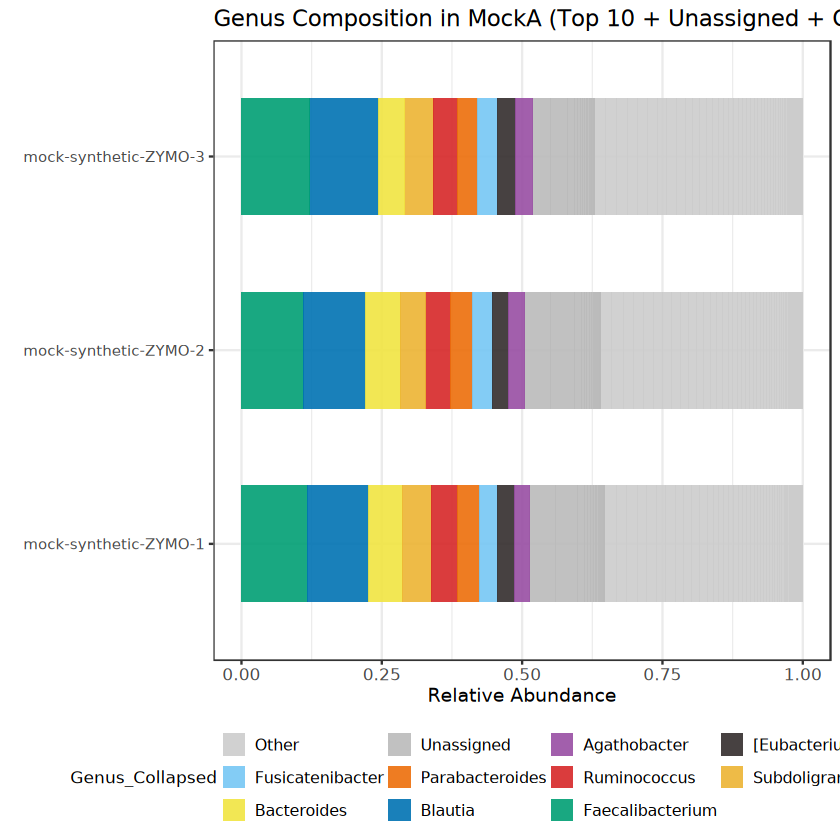

In [63]:
# 1. Clean taxonomy
taxa_MockA <- as.data.frame(tax_table(ps_mockA))
taxa_MockA$Genus <- as.character(taxa_MockA$Genus)
taxa_MockA$Genus[is.na(taxa_MockA$Genus) | taxa_MockA$Genus == "NA"] <- "Unassigned"
tax_table(ps_mockA) <- tax_table(as.matrix(taxa_MockA))

# 2. Aggregate to Genus level
ps.genus.MockA <- tax_glom(ps_mockA, taxrank = "Genus")

# 3. Transform to relative abundance
ps.rel.MockA <- transform_sample_counts(ps.genus.MockA, function(x) x / sum(x))

# 4. Melt phyloseq object to long format
df.abund <- psmelt(ps.rel.MockA)

# 5. Calculate total abundance across all samples
genus_summary <- df.abund %>%
  group_by(Genus) %>%
  summarise(total_abundance = sum(Abundance)) %>%
  arrange(desc(total_abundance))

# 6. Identify top 10 genera
top10_genus <- genus_summary$Genus[1:10]

# 7. Collapse genera: keep top 10 and unassigned, group the rest as "Other"
df.abund <- df.abund %>%
  mutate(Genus_Collapsed = case_when(
    Genus %in% top10_genus ~ Genus,
    Genus == "Unassigned" ~ "Unassigned",
    TRUE ~ "Other"
  ))

# 8. Order factor levels (Other < Unassigned < Top genera reversed)
ordered_levels <- c("Other", "Unassigned", rev(setdiff(top10_genus, c("Unassigned", "Other"))))
df.abund$Genus_Collapsed <- factor(df.abund$Genus_Collapsed, levels = ordered_levels)

# 9. Define custom color palette (edit as needed to match top10_genus)
genusPalette <- c(
  "Faecalibacterium" = "#009e73",
  "Blautia" = "#0072b2",
  "Bacteroides" = "#f0e442",
  "Subdoligranulum" = "#ecb333",
  "Ruminococcus" = "#d62728",
  "Parabacteroides" = "#ec6e0b",
  "Fusicatenibacter" = "#76c6f3",
  "[Eubacterium] siraeum group" = "#332d2d",
  "Agathobacter" = "#984ea3",
  "Unassigned" = "#bababa",
  "Other" = "#cccccc"
)

# 10. Create bar plot
p.mockA <- ggplot(df.abund, aes(x = Sample, y = Abundance, fill = Genus_Collapsed)) +
  geom_bar(stat = "identity", position = "stack", alpha = 0.9, width = 0.6) +
  scale_fill_manual(values = genusPalette, na.value = "gray") +
  theme_bw() +
  labs(
    title = "Genus Composition in MockA (Top 10 + Unassigned + Other)",
    y = "Relative Abundance", x = ""
  ) +
  coord_flip() +
  theme(
    axis.text.x = element_text(size = 10),
    axis.title.y = element_text(size = 10),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.key.size = unit(0.5, "cm"),
    legend.text = element_text(size = 9),
    legend.title = element_text(size = 10)
  ) +
  guides(fill = guide_legend(nrow = 3, byrow = TRUE))

# 11. Show plot
print(p.mockA)


In [65]:
library(dplyr)

# Add percentage column
df.abund <- df.abund %>%
  mutate(Abundance_percent = round(Abundance * 100, 2))

# Optional: View as a table
genus_percentage_table <- df.abund %>%
  select(Sample, Genus_Collapsed, Abundance_percent) %>%
  arrange(Sample, desc(Abundance_percent))

# View a portion
View(genus_percentage_table)



Sample,Genus_Collapsed,Abundance_percent
<chr>,<fct>,<dbl>
mock-synthetic-ZYMO-1,Faecalibacterium,11.70
mock-synthetic-ZYMO-1,Blautia,10.88
mock-synthetic-ZYMO-1,Bacteroides,6.10
mock-synthetic-ZYMO-1,Subdoligranulum,5.11
mock-synthetic-ZYMO-1,Ruminococcus,4.69
mock-synthetic-ZYMO-1,Unassigned,4.51
mock-synthetic-ZYMO-1,Unassigned,3.94
mock-synthetic-ZYMO-1,Parabacteroides,3.84
mock-synthetic-ZYMO-1,Fusicatenibacter,3.31


In [66]:
#### 15.4 Plot sequencing depth and 16S gene copy numbers by sample types
# Extract and clean metadata
sdata_df <- as(sample_data(ps), "data.frame")

# Clean whitespace and fix Sample_Type categories
sdata_df$Sample_Type <- trimws(as.character(sdata_df$Sample_Type))

# Correct Sample_Type levels
sdata_df$Sample_Type[sdata_df$Sample_Type == "mock"] <- "Mock"
sdata_df$Sample_Type[sdata_df$Sample_Type == "feces"] <- "Feces"
sdata_df$Sample_Type[sdata_df$Sample_Type == "environmental_control"] <- "Environmental_Control"
sdata_df$Sample_Type[sdata_df$Sample_Type == "extraction_control"] <- "Extraction_Control"
sdata_df$Sample_Type[sdata_df$Sample_Type == "reagent_control"] <- "Reagent_Control"

# Reorder levels: "Feces", "Mock", "Reagent_Control", "Extraction_Control", "Environmental_Control"
SAMPLE_TYPES <- c("Feces", "Mock", "Reagent_Control", "Extraction_Control", "Environmental_Control")
sdata_df$Sample_Type <- factor(sdata_df$Sample_Type, levels = SAMPLE_TYPES)

# Color palette
ColorFillManual <- c(
  "Feces" = "#ff7f0e",
  "Mock" = "#2ca02c",
  "Reagent_Control" = "#d62728",
  "Extraction_Control" = "#bcbd22",
  "Environmental_Control" = "#1f77b4"
)


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'object' in selecting a method for function 'sample_data': object 'ps' not found


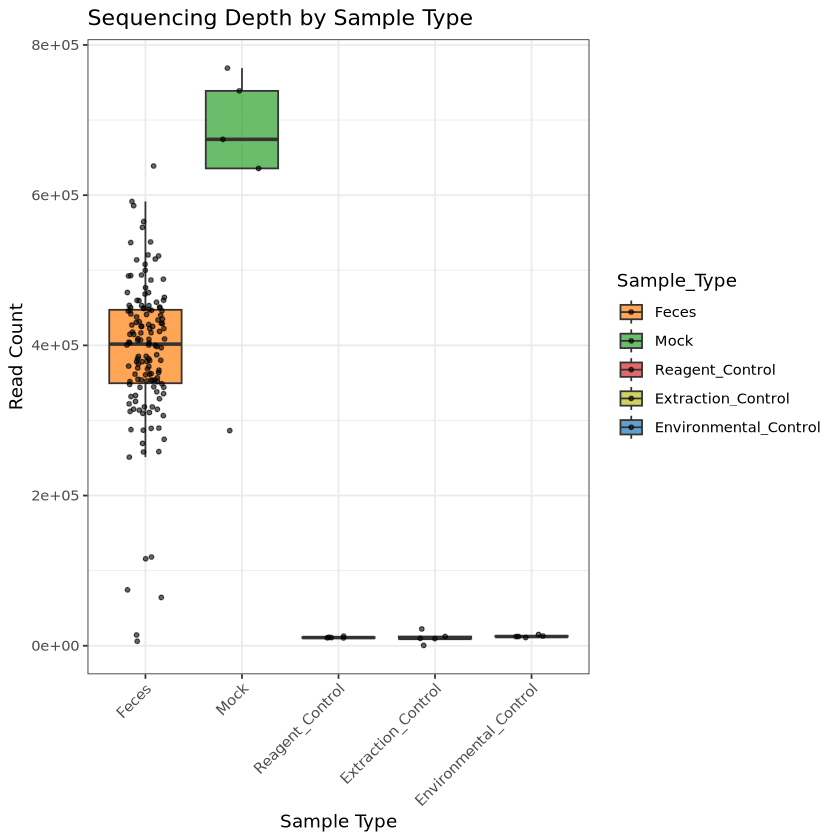

In [74]:
### Sequencing depth plot
# Add read count
sdata_df$read_count <- sample_sums(ps)

# Plot sequencing depth
p_depth <- ggplot(sdata_df, aes(x = Sample_Type, y = read_count, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  scale_fill_manual(values = ColorFillManual) +
  labs(
    title = "Sequencing Depth by Sample Type",
    y = "Read Count",
    x = "Sample Type"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Show plot
p_depth


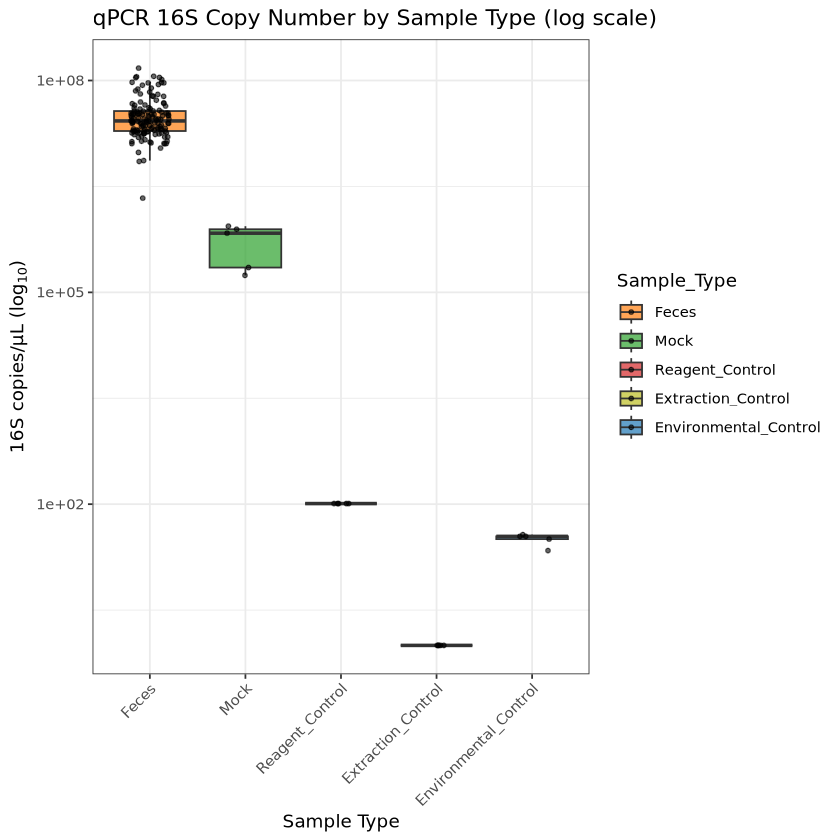

In [78]:
#### 16s Copy number
# Clean and convert qPCR copy number
sdata_df$qpcr_16s_copies_ul <- gsub(",", "", sdata_df$qpcr_16s_copies_ul)
sdata_df$qpcr_16s_copies_ul[sdata_df$qpcr_16s_copies_ul %in% c("ND", "NaN", "NA", "", "Undetermined")] <- NA
sdata_df$qpcr_16s_copies_ul <- as.numeric(sdata_df$qpcr_16s_copies_ul)

# Plot qPCR copy number
p_qpcr <- ggplot(sdata_df, aes(x = Sample_Type, y = qpcr_16s_copies_ul, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7, na.rm = TRUE) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6, na.rm = TRUE) +
  scale_fill_manual(values = ColorFillManual) +
  scale_y_log10() +
  labs(
    title = "qPCR 16S Copy Number by Sample Type (log scale)",
    y = expression("16S copies/μL (log"[10]*")"),
    x = "Sample Type"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Show plot
p_qpcr


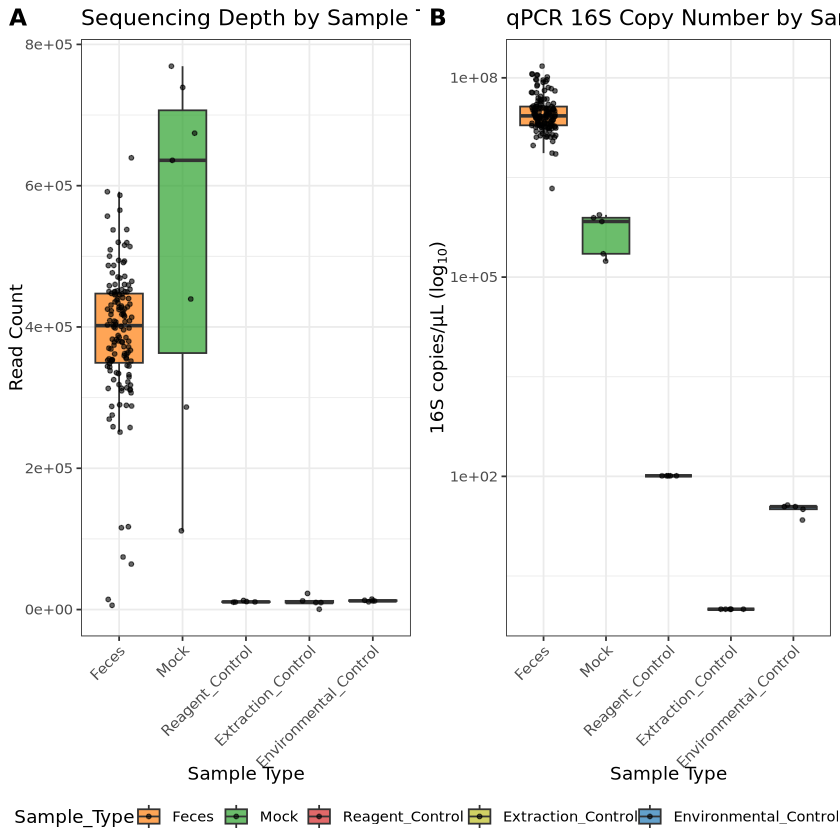

In [92]:
#### Combine plots 
library(ggpubr)

# Combine plots side-by-side
combined_plot <- ggarrange(
  p_depth, p_qpcr,
  ncol = 2,
  labels = c("A", "B"),
  common.legend = TRUE,
  legend = "bottom"
)

# Define output path
output_path <- file.path(path.figures, "SequencingDepth_qPCR_CopyNumber.png")

# Save the combined figure
ggsave(filename = output_path, plot = combined_plot,
       width = 12, height = 6, dpi = 300)

# Also display the plot in the viewer
combined_plot


In [75]:
#### 16s Copy number
# Clean and convert qPCR copy number into a new column
sdata_df$CopyNumber <- gsub(",", "", sdata_df$qpcr_16s_copies_ul)
sdata_df$CopyNumber[sdata_df$CopyNumber %in% c("ND", "NaN", "NA", "", "Undetermined")] <- NA
sdata_df$CopyNumber <- as.numeric(sdata_df$CopyNumber)


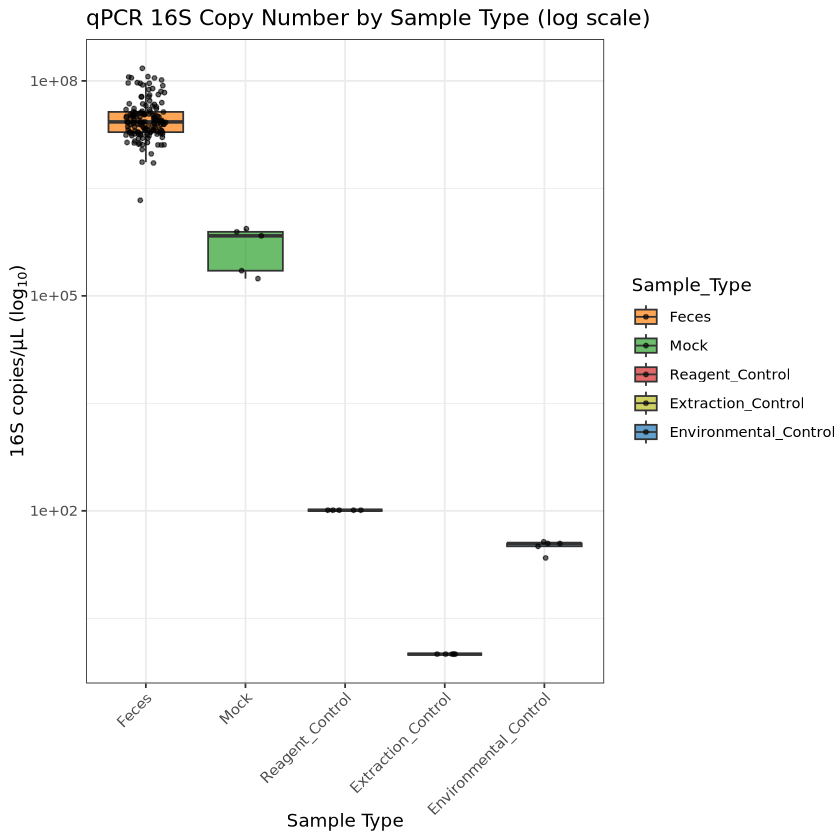

In [95]:
# Filter for valid values only
plot_data <- sdata_df[!is.na(sdata_df$CopyNumber), ]

# Plot qPCR copy number
p_qpcr <- ggplot(plot_data, aes(x = Sample_Type, y = CopyNumber, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  scale_fill_manual(values = ColorFillManual) +
  scale_y_log10() +
  labs(
    title = "qPCR 16S Copy Number by Sample Type (log scale)",
    y = expression("16S copies/μL (log"[10]*")"),
    x = "Sample Type"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Show plot
p_qpcr


In [80]:
library(ggplot2)
library(dplyr)
library(emmeans)
library(car)
library(ggpubr)

# --------- 1. Clean metadata ---------
sdata_df <- as(sample_data(ps), "data.frame")

# Clean Sample_Type
sdata_df$Sample_Type <- trimws(as.character(sdata_df$Sample_Type))
sdata_df$Sample_Type[sdata_df$Sample_Type == "mock"] <- "Mock"
sdata_df$Sample_Type[sdata_df$Sample_Type == "feces"] <- "Feces"
sdata_df$Sample_Type[sdata_df$Sample_Type == "environmental_control"] <- "Environmental_Control"
sdata_df$Sample_Type[sdata_df$Sample_Type == "extraction_control"] <- "Extraction_Control"
sdata_df$Sample_Type[sdata_df$Sample_Type == "reagent_control"] <- "Reagent_Control"

# Set Sample_Type as factor with desired order
SAMPLE_TYPES <- c("Feces", "Mock", "Reagent_Control", "Extraction_Control", "Environmental_Control")
sdata_df$Sample_Type <- factor(sdata_df$Sample_Type, levels = SAMPLE_TYPES)

# --------- 2. Add sequencing depth ---------
sdata_df$read_count <- sample_sums(ps)

# --------- 3. Clean and create CopyNumber ---------
sdata_df$CopyNumber <- gsub(",", "", sdata_df$qpcr_16s_copies_ul)
sdata_df$CopyNumber[sdata_df$CopyNumber %in% c("ND", "NaN", "NA", "", "Undetermined")] <- NA
sdata_df$CopyNumber <- as.numeric(sdata_df$CopyNumber)

# --------- 4. Color palette ---------
ColorFillManual <- c(
  "Feces" = "#ff7f0e",
  "Mock" = "#2ca02c",
  "Reagent_Control" = "#d62728",
  "Extraction_Control" = "#bcbd22",
  "Environmental_Control" = "#1f77b4"
)

# --------- 5. Plot 1: Sequencing Depth ---------
p_depth <- ggplot(sdata_df, aes(x = Sample_Type, y = read_count, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7, na.rm = TRUE) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6, na.rm = TRUE) +
  scale_fill_manual(values = ColorFillManual) +
  labs(
    title = "Sequencing Depth by Sample Type",
    y = "Read Count",
    x = "Sample Type"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# --------- 6. Plot 2: qPCR 16S Copy Number (log10 scale) ---------
plot_qpcr_df <- sdata_df[!is.na(sdata_df$CopyNumber), ]

p_qpcr <- ggplot(plot_qpcr_df, aes(x = Sample_Type, y = CopyNumber, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7, na.rm = TRUE) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6, na.rm = TRUE) +
  scale_fill_manual(values = ColorFillManual) +
  scale_y_log10() +
  labs(
    title = "qPCR 16S Copy Number by Sample Type (log scale)",
    y = expression("16S copies/μL (log"[10]*")"),
    x = "Sample Type"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# --------- 7. Save Combined Plot ---------
combined_plot <- ggarrange(
  p_depth, p_qpcr,
  ncol = 2,
  labels = c("A", "B"),
  common.legend = TRUE,
  legend = "bottom"
)

# Set output path
path.figures <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
ggsave(file.path(path.figures, "SequencingDepth_16S_CopyNumber.png"), plot = combined_plot,
       width = 12, height = 6, dpi = 300)

# --------- 8. Statistical analysis ---------
# GLM on log-transformed CopyNumber
glm.sample.CopyN <- glm(log(CopyNumber) ~ Sample_Type, data = plot_qpcr_df)

# Model summary
summary(glm.sample.CopyN)

# ANOVA
car::Anova(glm.sample.CopyN)

# Pairwise comparisons
emmeans::emmeans(glm.sample.CopyN, pairwise ~ Sample_Type)


Warning message:
“package ‘emmeans’ was built under R version 4.4.3”
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode





Call:
glm(formula = log(CopyNumber) ~ Sample_Type, data = plot_qpcr_df)

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                       17.16794    0.05079  338.05   <2e-16 ***
Sample_TypeMock                   -4.15378    0.27537  -15.08   <2e-16 ***
Sample_TypeReagent_Control       -12.54297    0.27537  -45.55   <2e-16 ***
Sample_TypeExtraction_Control    -17.16794    0.27537  -62.34   <2e-16 ***
Sample_TypeEnvironmental_Control -13.71226    0.27537  -49.80   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for gaussian family taken to be 0.3662466)

    Null deviance: 2994.905  on 161  degrees of freedom
Residual deviance:   57.501  on 157  degrees of freedom
AIC: 303.94

Number of Fisher Scoring iterations: 2


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Sample_Type,8020.292,4,0


$emmeans
 Sample_Type           emmean     SE  df lower.CL upper.CL
 Feces                  17.17 0.0508 157   17.068   17.268
 Mock                   13.01 0.2710 157   12.480   13.549
 Reagent_Control         4.62 0.2710 157    4.090    5.160
 Extraction_Control      0.00 0.2710 157   -0.535    0.535
 Environmental_Control   3.46 0.2710 157    2.921    3.990

Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate    SE  df t.ratio p.value
 Feces - Mock                                   4.15 0.275 157  15.084  <.0001
 Feces - Reagent_Control                       12.54 0.275 157  45.550  <.0001
 Feces - Extraction_Control                    17.17 0.275 157  62.345  <.0001
 Feces - Environmental_Control                 13.71 0.275 157  49.796  <.0001
 Mock - Reagent_Control                         8.39 0.383 157  21.918  <.0001
 Mock - Extraction_Control                     13.01 0.383 157  34.002  <.0001
 Mock - Environmental_Control                   9.56 0.383 157  24.973  <.0001
 Reagent_Control - Extraction_Control           4.62 0.383 157  12.083  <.0001
 Reagent_Control - Environmental_Control        1.17 0.383 157   3.055  0.0219
 Extraction_Control - Environmental_Control    -3.46 0.383 157  -9.029  <.0001

Results are given on the log (not the response) scale. 
P value adjustment: tukey method for comparing a family of 5 estimates

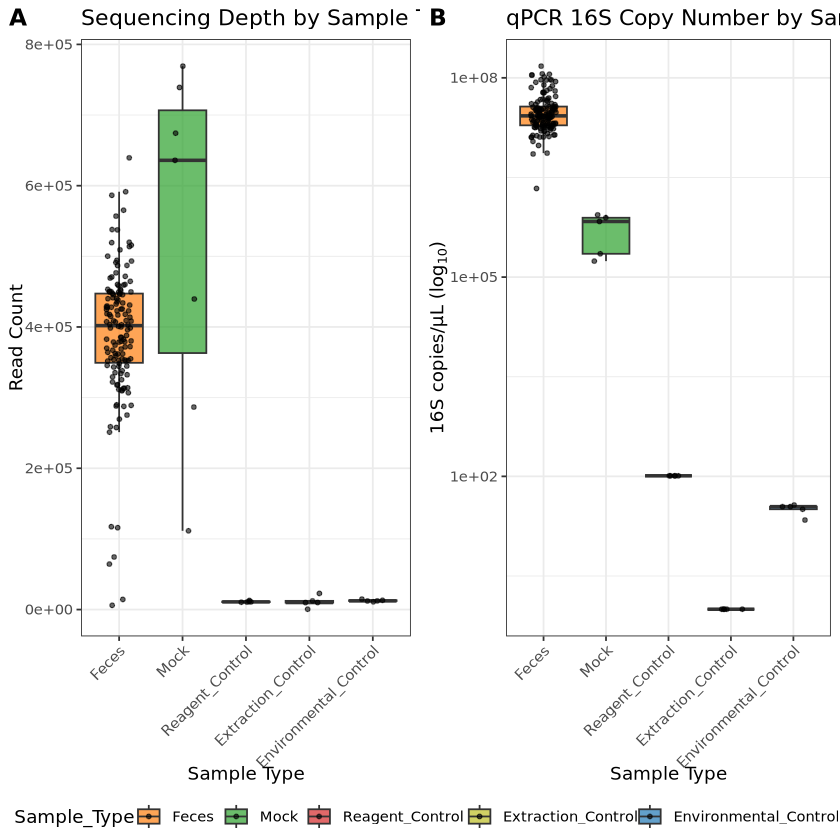

In [99]:
print(combined_plot)


In [100]:
# --- Create Output Directory ---
path.stats <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/stats"
dir.create(path.stats, showWarnings = FALSE, recursive = TRUE)

# --- 1. GLM Coefficients Summary ---
glm_summary <- summary(glm.sample.CopyN)
glm_coef <- as.data.frame(coef(glm_summary))
glm_coef$Term <- rownames(glm_coef)
rownames(glm_coef) <- NULL
glm_coef <- glm_coef[, c("Term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]

# Round and rename
glm_coef <- glm_coef %>%
  mutate(across(where(is.numeric), ~ round(., 4)))
names(glm_coef) <- c("Coefficient", "Estimate", "Std_Error", "t_value", "p_value")

# --- 2. ANOVA Table ---
anova_results <- car::Anova(glm.sample.CopyN)
anova_df <- as.data.frame(anova_results)
anova_df$Term <- rownames(anova_df)
rownames(anova_df) <- NULL
anova_df <- anova_df[, c("Term", "LR Chisq", "Df", "Pr(>Chisq)")]

# Round and rename
anova_df <- anova_df %>%
  mutate(across(where(is.numeric), ~ signif(., 4)))
names(anova_df) <- c("Term", "LR_Chisq", "DF", "p_value")

# --- 3. Pairwise Comparisons with emmeans ---
emm <- emmeans::emmeans(glm.sample.CopyN, pairwise ~ Sample_Type)
pairwise_df <- as.data.frame(emm$contrasts)

# Round numeric columns
pairwise_df <- pairwise_df %>%
  mutate(across(where(is.numeric), ~ signif(., 4)))
names(pairwise_df)[names(pairwise_df) == "p.value"] <- "p_value"

# --- 4. Save Outputs ---
write.csv(glm_coef, file.path(path.stats, "glm_coefficients.csv"), row.names = FALSE)
write.csv(anova_df, file.path(path.stats, "glm_anova.csv"), row.names = FALSE)
write.csv(pairwise_df, file.path(path.stats, "glm_emmeans_pairwise.csv"), row.names = FALSE)


In [106]:
library(dplyr)

# Identify the correct p-value column
pval_col <- grep("^p[._]?value", colnames(pairwise_df), value = TRUE)[1]

# Clean and rename for manuscript-ready format
pairwise_df_clean <- pairwise_df %>%
  rename(p.value = all_of(pval_col)) %>%
  mutate(
    contrast = gsub(" - ", " vs. ", contrast),
    estimate = round(estimate, 2),
    SE = round(SE, 2),
    t.ratio = round(t.ratio, 2),
    p.value = signif(p.value, 3)
  ) %>%
  select(contrast, estimate, SE, t.ratio, p.value) %>%
  arrange(p.value)

# View the cleaned result
print(pairwise_df_clean)

write.csv(pairwise_df_clean, file.path(path.stats, "glm_emmeans_pairwise_cleaned.csv"), row.names = FALSE)

                                       contrast estimate   SE t.ratio  p.value
1                                Feces vs. Mock     4.15 0.28   15.08 9.42e-14
2                     Feces vs. Reagent_Control    12.54 0.28   45.55 9.42e-14
3                  Feces vs. Extraction_Control    17.17 0.28   62.35 9.42e-14
4               Feces vs. Environmental_Control    13.71 0.28   49.80 9.42e-14
5                      Mock vs. Reagent_Control     8.39 0.38   21.92 9.42e-14
6                   Mock vs. Extraction_Control    13.01 0.38   34.00 9.42e-14
7                Mock vs. Environmental_Control     9.56 0.38   24.97 9.42e-14
8        Reagent_Control vs. Extraction_Control     4.62 0.38   12.08 9.86e-14
9  Extraction_Control vs. Environmental_Control    -3.46 0.38   -9.03 1.46e-13
10    Reagent_Control vs. Environmental_Control     1.17 0.38    3.06 2.19e-02


In [57]:
####Decontam and sourcetracker
### 1. Load Required Libraries
library(decontam)
library(dplyr)
library(ggplot2)
library(phyloseq)
library(ggpubr)
library(pairwiseAdonis)
library(patchwork)
library(microbiome)

Loading required package: cluster



In [68]:
### 2. Define Sample Types and Paths

TYPE <- c("Feces")
path.rds <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
path.figures <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
path.stats <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/stats"

In [69]:
### 3. Load Phyloseq Object

ps <- readRDS(file.path(path.rds, "ps.all.samples.rds"))
ps
ps.mock <- readRDS(file.path(path.rds, "ps.mock.rds"))
ps.mock

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23355 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 23355 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1358 taxa and 5 samples ]
sample_data() Sample Data:       [ 5 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 1358 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 1358 reference sequences ]

In [63]:
### Check the tax_table aspect of the phyloseq object:
colnames(tax_table(ps))

[1] "Kingdom" "Phylum"  "Class"   "Order"   "Family"  "Genus"   "Species"

In [64]:
tax_df <- as.data.frame(tax_table(ps))

In [72]:
# Step 1: Extract sample metadata from phyloseq
meta <- as.data.frame(sample_data(ps))
meta$CopyNumber <- as.numeric(meta$qpcr_16s_copies_ul)

# Step 2: Clean whitespace from Sample_Type column
meta$Sample_Type <- trimws(meta$Sample_Type)

# Step 3: Define SampleOrControl column
meta$SampleOrControl <- "Sample"  # Default

# Define known controls
control_types <- c("Environmental_Control", "Extraction_Control", "Reagent_Control")
meta$SampleOrControl[meta$Sample_Type %in% control_types] <- "Control"

# Step 4: Define is.neg for decontam (TRUE if negative control)
meta$is.neg <- meta$SampleOrControl == "Control"

# Step 5: Assign CopyNumber if available
if ("CopyNumber" %in% colnames(meta)) {
  meta$CopyNumber <- as.numeric(meta$CopyNumber)
} else {
  warning("CopyNumber column not found in metadata — will not be available for frequency-based decontam")
}

# Step 6: Write back into phyloseq object
sample_data(ps) <- sample_data(meta)

# Optional: inspect result
table(meta$SampleOrControl, meta$Sample_Type)


Warning message:
“NAs introduced by coercion”


         
          Environmental_Control Extraction_Control Feces Mock Reagent_Control
  Control                     5                  5     0    0               5
  Sample                      0                  0   142    5               0

In [74]:
# Replace specific Sample_Type entries
meta$Sample_Type[meta$Sample_ID %in% c("ZYMO-1", "ZYMO-2", "ZYMO-3")] <- "Mock_A"
meta$Sample_Type[meta$Sample_ID %in% c("ZYMO-4", "ZYMO-5")] <- "Mock_B"

# Reassign the updated metadata back to the phyloseq object
sample_data(ps) <- meta

In [75]:
#### Frequency method 
# Prepare data for 'frequency' method
# 1. phyloseq object without positive controls
exclude_mock <- c("Mock_A", "Mock_B")
ps.samples.wo.mock <- subset_samples(ps, !Sample_Type %in% exclude_mock) 
ps.samples.wo.mock <- prune_taxa(taxa_sums(ps.samples.wo.mock) > 0, ps.samples.wo.mock) # remove taxa with no counts
ps.samples.wo.mock #Removed mock samples, kept feces + negative controls

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 22196 taxa and 157 samples ]
sample_data() Sample Data:       [ 157 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 22196 taxa by 7 taxonomic ranks ]

In [76]:
# Remove negative control samples 
# 2. phyloseq object without negative controls
exclude_controls <- c("Environmental_Control", "Extraction_Control", "Reagent_Control")
ps.samples.wo.controls <- subset_samples(ps, !Sample_Type %in% exclude_controls) 
ps.samples.wo.controls <- prune_taxa(taxa_sums(ps.samples.wo.controls) > 0, ps.samples.wo.controls) # remove taxa with no counts
ps.samples.wo.controls #Removed negative controls, kept feces + mocks

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 22193 taxa and 147 samples ]
sample_data() Sample Data:       [ 147 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 22193 taxa by 7 taxonomic ranks ]

In [77]:
# Remove positive control samples ("MockA and MockB" ) and negative controls
exclude_mock <- c("Mock_A", "Mock_B")
ps.samples.wo.controls.mock <- subset_samples(ps.samples.wo.controls, !Sample_Type %in% exclude_mock) 
ps.samples.wo.controls.mock <- prune_taxa(taxa_sums(ps.samples.wo.controls.mock) > 0, ps.samples.wo.controls.mock) # remove taxa with no counts
ps.samples.wo.controls.mock #Final clean: only true feces samples — no mocks, no controls

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 21048 taxa and 142 samples ]
sample_data() Sample Data:       [ 142 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 21048 taxa by 7 taxonomic ranks ]

In [80]:
# List of phyloseq objects
phylo_list <- list(
  ps = ps,
  ps.samples.wo.mock = ps.samples.wo.mock,
  ps.samples.wo.controls = ps.samples.wo.controls,
  ps.samples.wo.controls.mock = ps.samples.wo.controls.mock
)

# Build summary table
phylo_summary <- lapply(names(phylo_list), function(name) {
  obj <- phylo_list[[name]]
  data.frame(
    Object_Name = name,
    Num_Samples = nsamples(obj),
    Num_Taxa = ntaxa(obj),
    Unique_SampleTypes = paste(unique(sample_data(obj)$Sample_Type), collapse = "; "),
    stringsAsFactors = FALSE
  )
})

phylo_summary_df <- do.call(rbind, phylo_summary)

# Save as CSV
write.csv(
  phylo_summary_df,
  file = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/phyloseq_object_auto_summary.csv",
  row.names = FALSE
)


In [70]:
ps.samples.wo.controls.mock

ERROR: Error: object 'ps.samples.wo.controls.mock' not found


In [81]:
# Run frequency method

# Check the format of the qPCR values: remove the commas and convert the qpcr_16s_copies_ul column to numeric format in R
meta <- as.data.frame(sample_data(ps.samples.wo.controls.mock))
meta$qpcr_16s_copies_ul <- as.numeric(gsub(",", "", meta$qpcr_16s_copies_ul))
sample_data(ps.samples.wo.controls.mock) <- meta # Reassign cleaned metadata back to phyloseq object

# Run Method:
contamdf.freq <- isContaminant(ps.samples.wo.controls.mock, 
                               method="frequency", 
                               conc="qpcr_16s_copies_ul", 
                               threshold = 0.5) # DNA concentration is stored in the qpcr_16s_copies_ul column
# View summary
table(contamdf.freq$contaminant)



FALSE  TRUE 
19125  1923 

In [86]:
contam_feature_indices <- which(contamdf.freq$contaminant == TRUE)
head(contam_feature_indices)

[1]   6   7  97 120 125 154

In [87]:
# Select contaminants from otu table
contam_seq_freq <- rownames(contamdf.freq[contamdf.freq$contaminant == "TRUE",])

contamdf.freqMod <- contamdf.freq %>%
 filter(prev > 1) %>%
 mutate(Prevalence = ifelse(prev == 2, "2",
 ifelse(prev > 2 & prev <= 5, "3-5",
 ifelse(prev >= 6 & prev <= 10, "6-10", "11+"))) )

contamdf.freqMod$Prevalence <- factor(contamdf.freqMod$Prevalence, levels = c("2", "3-5", "6-10", "11+"))

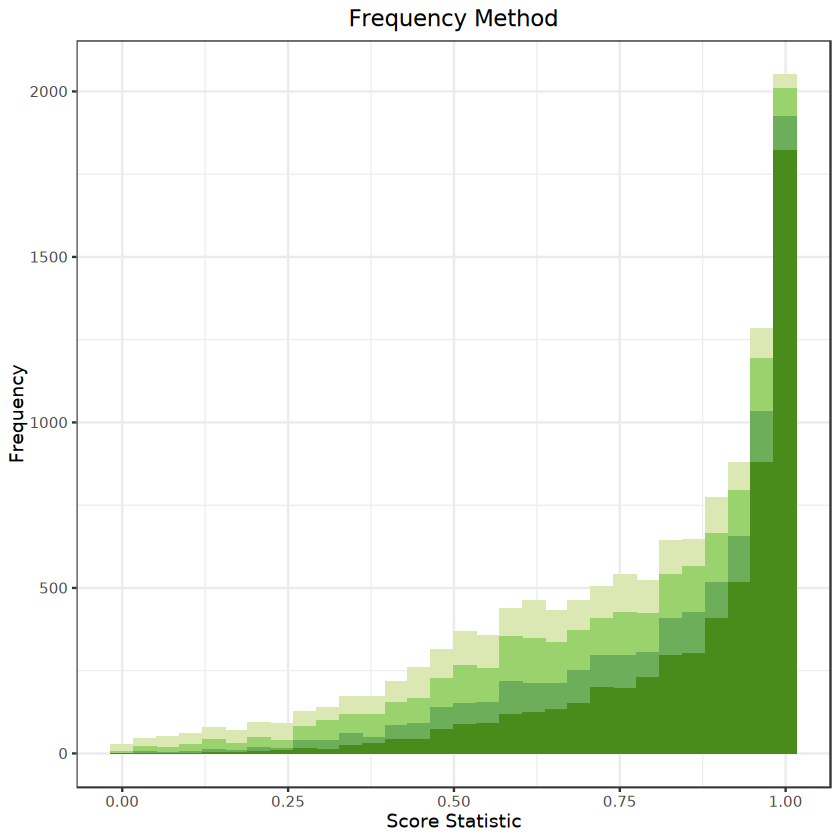

In [88]:
### Plot Score statistics for frequency method
# Set up:
theme_set(theme_bw())
 # Part of the Area Green Tableau color palette (Version 9.x)
 # Similar to Davis et al., (2018)
scaleColorFillManualFrequency <-
 scale_fill_manual(
 values =
 c(
 "2" = "#dbe8b4",
 "3-5" = "#9ad26d",
 "6-10" = "#6cae59",
 "11+" = "#4a8c1c"
 )
 )
# Plot score statistics output
freqScorePlot <- ggplot(contamdf.freqMod, aes(x = p, fill = Prevalence)) +
 geom_histogram(bins = 30) +
 scaleColorFillManualFrequency +
 ggtitle("Frequency Method") +
 xlab("Score Statistic") +
 ylab("Frequency") +
 theme(
 plot.title = element_text(hjust = 0.5),
 legend.position = "none")
print(freqScorePlot)

In [ ]:
### Prevalence method for true sample
ps.samples.wo.controls.mock

In [89]:
### Prevalence method for all the sample (Sample + Mock + Controls)

# Prepare data for 'prevalence' method. 
sample_data(ps)$is.neg <- sample_data(ps)$Sample_Type %in% c("Environmental_Control", "Extraction_Control", "Reagent_Control")
# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable
contamdf.prev <- isContaminant(ps, method="prevalence", neg="is.neg", threshold=0.5)
table(contamdf.prev$contaminant)


FALSE  TRUE 
22846   476 

In [ ]:
ps

In [90]:
contam_feature_indices_prev <- which(contamdf.prev$contaminant == TRUE)
head(contam_feature_indices_prev)

[1]  777 1854 2052 2821 2916 2960

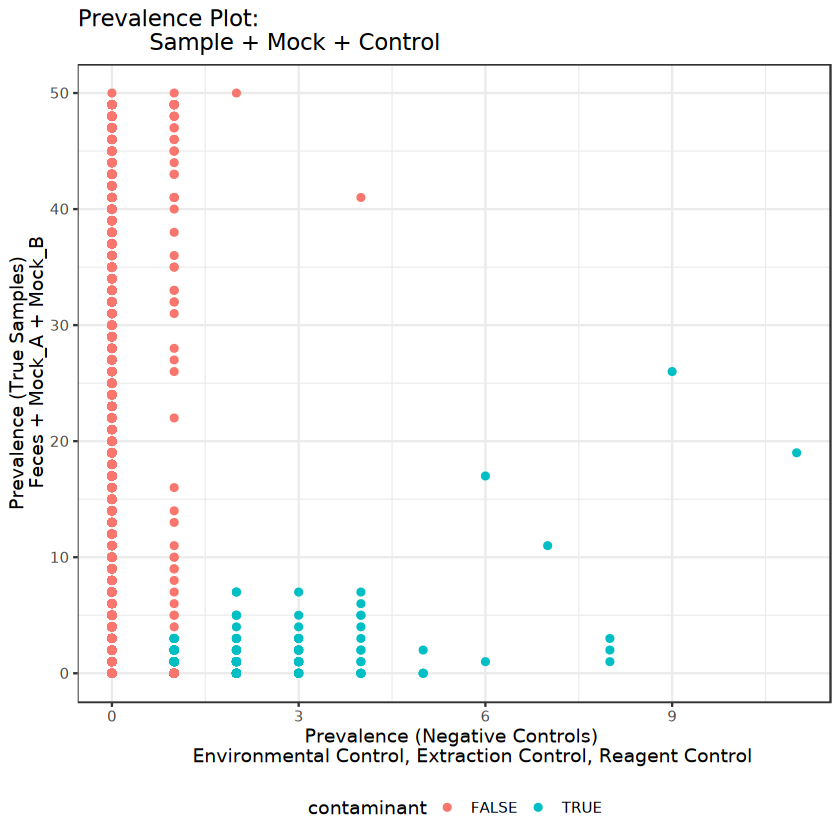

In [93]:
# Plot presence-absence in negative controls and true samples (Feces and Mock)
ps.pa <- transform_sample_counts(
  ps, 
  function(abund) 1*(abund>0))

ps.pa.neg <- prune_samples(
  sample_data(ps.pa)$Sample_Type %in% c(
    "Environmental_Control",
    "Extraction_Control", 
    "Reagent_Control"), 
  ps.pa)

ps.pa.pos <- prune_samples(
  sample_data(
    ps.pa)$Sample_Type == c(
      "Feces", "Mock_A", "Mock_B"), ps.pa)



# Make data.frame of prevalence in positive and negative samples
df.pa <- data.frame(
  pa.pos=taxa_sums(ps.pa.pos), 
  pa.neg=taxa_sums(ps.pa.neg),
  contaminant=contamdf.prev$contaminant)

pa.plot <- ggplot(data=df.pa, 
                  aes(x=pa.neg, 
                      y=pa.pos, 
                      color=contaminant)) + geom_point() +
  theme(legend.position = "bottom")+
  xlab("Prevalence (Negative Controls) 
      Environmental Control, Extraction Control, Reagent Control") +
  ylab("Prevalence (True Samples)
       Feces + Mock_A + Mock_B") +
  ggtitle("Prevalence Plot: 
          Sample + Mock + Control")

print(pa.plot)


In [94]:
## Prevalence method for Sample + Controls
# Plot of presence-absence in negative controls and true samples (Feces)
ps.pa.wo.mock <- transform_sample_counts(ps, function(abund) 1*(abund>0))

ps.pa.neg.wo.mock <- prune_samples(sample_data(ps.pa.wo.mock)$Sample_Type %in% c("Environmental_Control",
                                                                                 "Extraction_Control",
                                                                                 "Reagent_Control"), 
                                   ps.pa.wo.mock)
ps.pa.neg.wo.mock

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23322 taxa and 15 samples ]
sample_data() Sample Data:       [ 15 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 23322 taxa by 7 taxonomic ranks ]

In [95]:
ps.pa.pos.wo.mock <- prune_samples(sample_data(ps.pa.wo.mock)$Sample_Type == c("Feces"), ps.pa.wo.mock)
ps.pa.pos.wo.mock

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23322 taxa and 142 samples ]
sample_data() Sample Data:       [ 142 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 23322 taxa by 7 taxonomic ranks ]

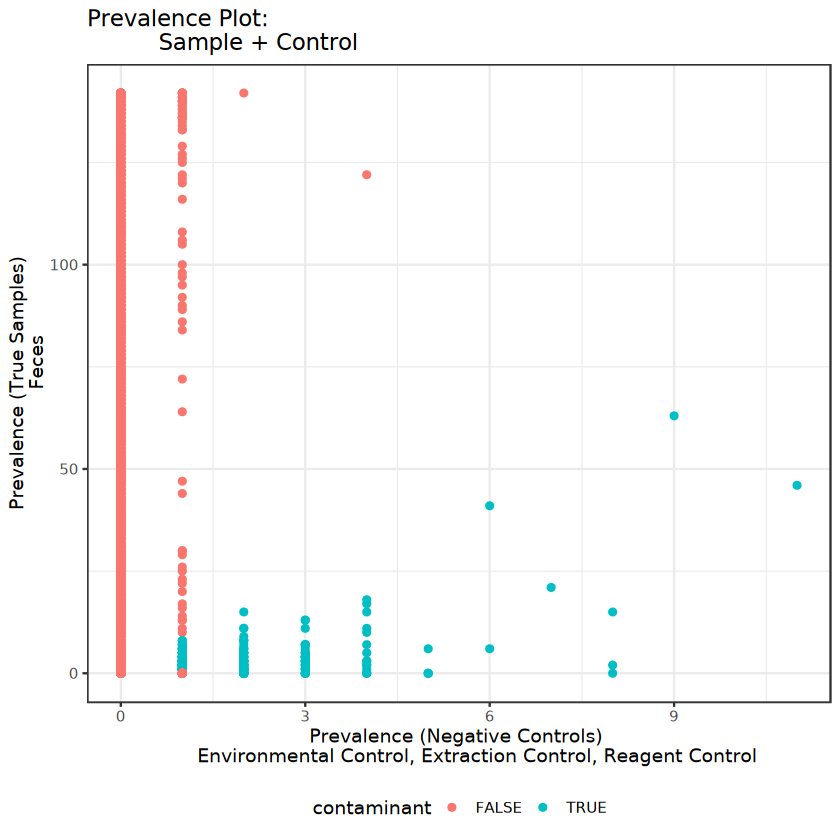

In [96]:
# Make data.frame of prevalence in positive and negative samples
df.pa.wo.mock <- data.frame(
  pa.pos.wo.mock=taxa_sums(ps.pa.pos.wo.mock), 
  pa.neg.wo.mock=taxa_sums(ps.pa.neg.wo.mock),
  contaminant=contamdf.prev$contaminant)

pa.plot.wo.mock <- ggplot(
  data=df.pa.wo.mock, 
  aes(x=pa.neg.wo.mock, 
      y=pa.pos.wo.mock, 
      color=contaminant)) +
  geom_point() +
  theme(legend.position = "bottom")+
  xlab("Prevalence (Negative Controls) 
      Environmental Control, Extraction Control, Reagent Control") +
  ylab("Prevalence (True Samples)
       Feces") +
  ggtitle("Prevalence Plot: 
          Sample + Control")
pa.plot.wo.mock

In [97]:
### Prevalence-Based Detection: Extraction Control

#Prepare data for 'prevalence' method, without "Extraction control" is control

ps.no.extraction <- subset_samples(ps, Sample_Type != "Extraction_Control") # remove extraction samples
ps.no.extraction <- prune_taxa(taxa_sums(ps.no.extraction) > 0, ps.no.extraction) # remove taxa with no counts
ps.no.extraction

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23031 taxa and 157 samples ]
sample_data() Sample Data:       [ 157 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 23031 taxa by 7 taxonomic ranks ]

In [98]:
# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable

contamdf.prev.extraction <- isContaminant(ps.no.extraction, 
                                          method="prevalence", 
                                          neg="is.neg", 
                                          threshold=0.5)

table(contamdf.prev.extraction$contaminant)


FALSE  TRUE 
22666   365 

In [99]:
# Extract ASVs flagged as contaminants from Extraction control
asv.prev.extraction <- rownames(contamdf.prev.extraction)[contamdf.prev.extraction$contaminant == TRUE]

# Save to CSV
write.csv(
  data.frame(ASV_Sequence = asv.prev.extraction),
  file = file.path(output_dir, "contaminant_asvs_prevalence_extraction_only.csv"),
  row.names = FALSE,
  quote = FALSE
)

In [100]:
# Identify contaminant feature indices:
contam_feature_indices_prev_extraction <- which(
  contamdf.prev.extraction$contaminant == TRUE)

head(contam_feature_indices_prev_extraction) 

[1] 2052 2821 2916 2960 3691 3697

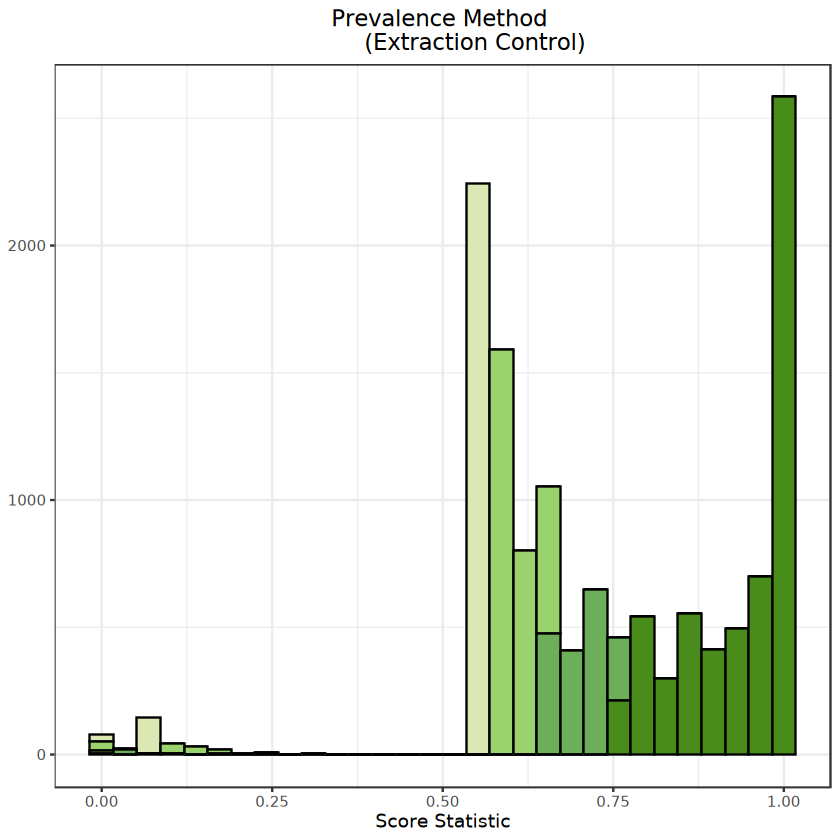

In [101]:
# Plot Extraction Control Score
contamdf.prev.extractionMod <- contamdf.prev.extraction %>%
 filter(prev > 1) %>%
 mutate(Prevalence = ifelse(prev == 2, "2",
 ifelse(prev > 2 & prev <= 5, "3-5",
 ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))
 )


contamdf.prev.extractionMod$Prevalence <- factor(
  contamdf.prev.extractionMod$Prevalence, 
  levels = c("2", "3-5", "6-10", "11+"))


prev.ExtractionScorePlot <- ggplot(
  contamdf.prev.extractionMod, 
  aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30, color = "black") +
  scaleColorFillManualFrequency +
  ggtitle("Prevalence Method 
         (Extraction Control)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "none",
    axis.title.y = element_blank()
    )

prev.ExtractionScorePlot

In [102]:
#select seq names of contaminants identified by prevalence method using extraction as control
contam_seq_prev_extraction <- rownames(contamdf.prev.extraction[contamdf.prev.extraction$contaminant == "TRUE",])

In [103]:
### Prevalence-Based Detection: Reagent Control

#Prepare data for 'prevalence' method, "Reagent control" is control

ps.no.reagent <- subset_samples(ps, Sample_Type != "Reagent_Control") # remove extraction samples
ps.no.reagent <- prune_taxa(taxa_sums(ps.no.reagent) > 0, ps.no.reagent) # remove taxa with no counts
ps.no.reagent

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 22955 taxa and 157 samples ]
sample_data() Sample Data:       [ 157 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 22955 taxa by 7 taxonomic ranks ]

In [104]:
# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable

contamdf.prev.reagent <- isContaminant(ps.no.reagent, method="prevalence", neg="is.neg", threshold=0.5)

table(contamdf.prev.reagent$contaminant)


FALSE  TRUE 
22611   344 

In [105]:
# Extract ASVs flagged as contaminants from Reagent Control
asv.prev.reagent <- rownames(contamdf.prev.reagent)[contamdf.prev.reagent$contaminant == TRUE]

# Save to CSV
write.csv(
  data.frame(ASV_Sequence = asv.prev.reagent),
  file = file.path(output_dir, "contaminant_asvs_prevalence_reagent_only.csv"),
  row.names = FALSE,
  quote = FALSE
) 

In [106]:
# Identify contaminant feature indices:
contam_feature_indices_prev_reagent <- which(contamdf.prev.reagent$contaminant == TRUE)
head(contam_feature_indices_prev_reagent)

[1]  777 1854 2052 2821 2916 2921

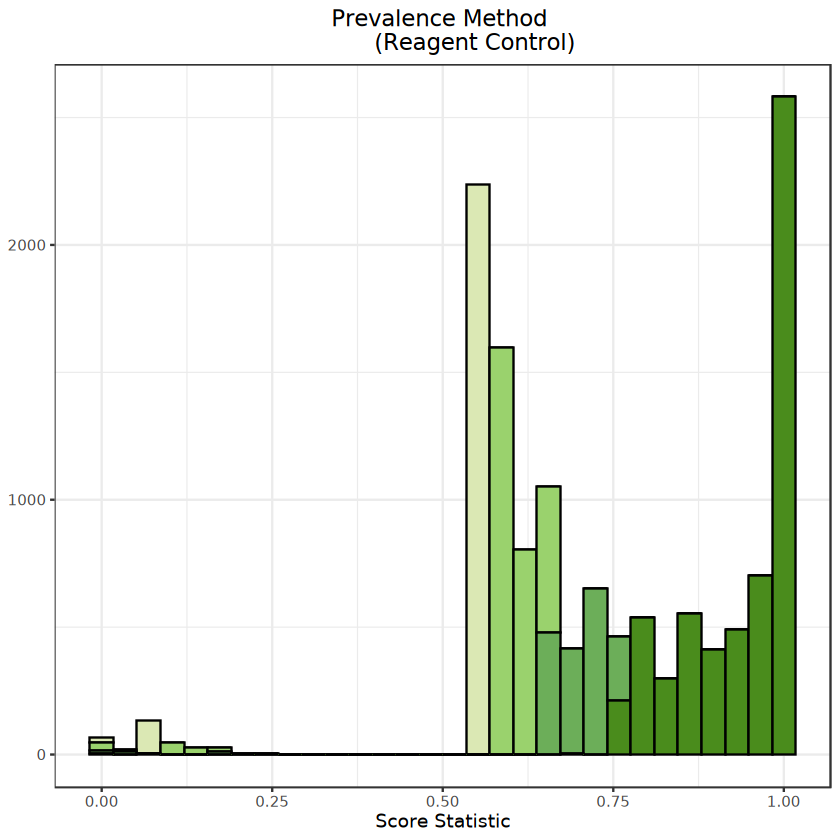

In [107]:
# Plot Reagent Control Score

# Filter to keep only taxa with prevalence > 1 and categorize prevalence into bins
contamdf.prev.reagentMod <- contamdf.prev.reagent %>%
 filter(prev > 1) %>%
 mutate(Prevalence = ifelse(prev == 2, "2",
                            ifelse(prev > 2 & prev <= 5, "3-5",
                                   ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))
 )

# Make sure the prevalence factor has the right order
contamdf.prev.reagentMod$Prevalence <- factor(
  contamdf.prev.reagentMod$Prevalence, 
  levels = c("2", "3-5", "6-10", "11+"))

# Plot histogram of the score statistic 'p' colored by prevalence category
prev.reagentScorePlot <- ggplot(
  contamdf.prev.reagentMod, 
  aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30, color = "black") +
  scaleColorFillManualFrequency +
  ggtitle("Prevalence Method 
         (Reagent Control)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "none",
    axis.title.y = element_blank()
 )
prev.reagentScorePlot

In [108]:
# Select seq names of contaminants identified by prevalence method using reagent as control
contam_seq_prev_reagent <- rownames(contamdf.prev.reagent)[contamdf.prev.reagent$contaminant == "TRUE"]

In [109]:
### Prevalence-Based Detection: Environment Control

#Prepare data for 'prevalence' method, without "Extraction control" is control 
ps.no.Environment  <- subset_samples(ps, Sample_Type != "Environmental_Control")  # remove extraction samples 

ps.no.Environment  <- prune_taxa(taxa_sums(ps.no.Environment) > 0, ps.no.Environment) # remove taxa with no counts 
ps.no.Environment

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 22881 taxa and 157 samples ]
sample_data() Sample Data:       [ 157 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 22881 taxa by 7 taxonomic ranks ]

In [110]:
# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable  

contamdf.prev.Environment <- isContaminant(
  ps.no.Environment, 
  method="prevalence", 
  neg="is.neg", 
  threshold=0.5)  

table(contamdf.prev.Environment$contaminant)  


FALSE  TRUE 
22550   331 

In [111]:
# Extract ASVs flagged as contaminants from Environmental Control
asv.prev.Environment <- rownames(contamdf.prev.Environment)[contamdf.prev.Environment$contaminant == TRUE]

# Save to CSV
write.csv(
  data.frame(ASV_Sequence = asv.prev.Environment),
  file = file.path(output_dir, "contaminant_asvs_prevalence_Environment_only.csv"),
  row.names = FALSE,
  quote = FALSE
)

In [112]:
# Identify contaminant feature indices:
contam_feature_indices_prev_Environment <- which(contamdf.prev.Environment$contaminant == TRUE) 

head(contam_feature_indices_prev_Environment)

[1]  777 1854 2052 2821 2916 2921

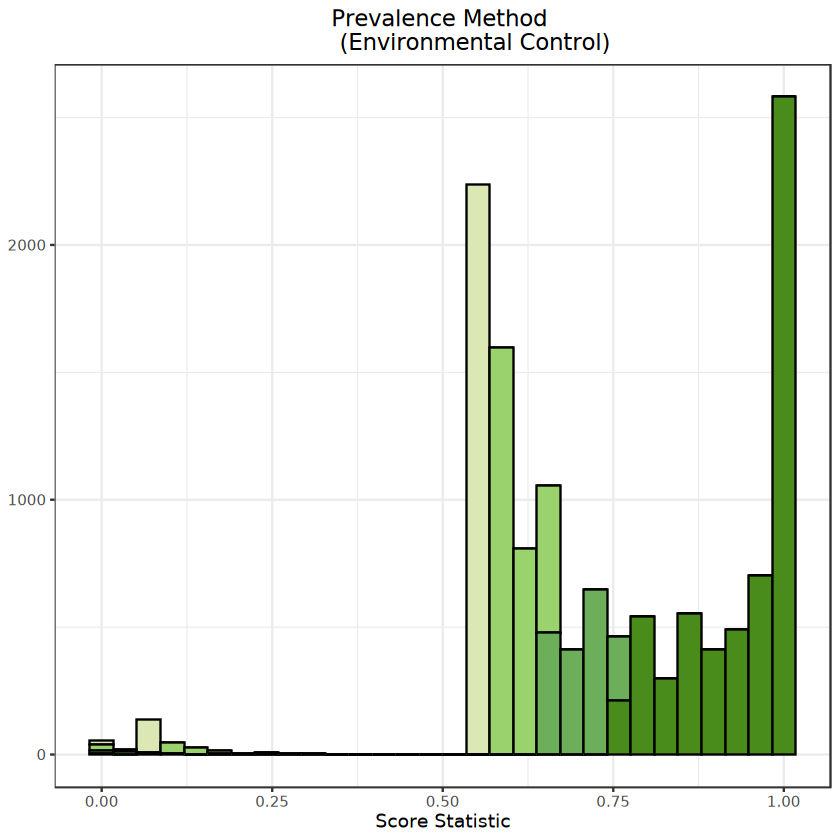

In [113]:
# Plot Environment Control Score 

# Filter to keep only taxa with prevalence > 1 and categorize prevalence into bins
contamdf.prev.EnvironmentMod <- contamdf.prev.Environment %>%
 filter(prev > 1) %>%
 mutate(Prevalence = ifelse(prev == 2, "2",
                            ifelse(prev > 2 & prev <= 5, "3-5",
                                   ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))
 )

# Make sure the prevalence factor has the right order
contamdf.prev.EnvironmentMod$Prevalence <- factor(
  contamdf.prev.EnvironmentMod$Prevalence, 
  levels = c("2", "3-5", "6-10", "11+"))

# Plot histogram of the score statistic 'p' colored by prevalence category
prev.EnvironmentScorePlot <- ggplot(
  contamdf.prev.EnvironmentMod, 
  aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30, color = "black") +
  scaleColorFillManualFrequency +
  ggtitle("Prevalence Method 
         (Environmental Control)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "none",
    axis.title.y = element_blank()
 )
prev.EnvironmentScorePlot

In [72]:
#select seq names of contaminants identified by prevalence method using environmental as control
contam_seq_prev_Environment <- rownames(contamdf.prev.Environment[contamdf.prev.Environment$contaminant == "TRUE",])

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'rownames': object 'contamdf.prev.Environment' not found


In [71]:
### Phyloseq object after Decontam
# Create noncontam ps project
# Select unique seq names of contaminants identified by both frequency and prevalence methods separately
contam_seq <- c(contam_seq_freq,
                contam_seq_prev_reagent,
                contam_seq_prev_extraction,
                contam_seq_prev_Environment)

contam_seq <- unique(contam_seq)

# Create ps project after removing contaminants
allTaxa = taxa_names(ps)
Taxa.decontam <- allTaxa[!(allTaxa %in% contam_seq)]
ps.decontam <- prune_taxa(Taxa.decontam, ps)
saveRDS(ps.decontam, file.path(path.rds, "ps.decontam.rds"))
ps.contam <- prune_taxa(contam_seq, ps)
saveRDS(ps.contam, file.path(path.rds, "ps.contam.rds"))

ERROR: Error: object 'contam_seq_freq' not found


In [10]:
output_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
ps.contam <- readRDS(file.path(output_dir, "ps.contam.rds"))
ps.decontam <- readRDS(file.path(output_dir, "ps.decontam.rds"))

In [12]:
# Look inside the ps.contam object

ps.contam

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 2369 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 2369 taxa by 7 taxonomic ranks ]

In [11]:
# Look inside the ps.decontam object

ps.decontam

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 20953 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 20953 taxa by 7 taxonomic ranks ]

In [13]:
### Plot 16S Gene Copy vs Abundance of Contaminants

SAMPLE_TYPES <- c(
 "Feces",
 "Mock_A",
 "Mock_B",
 "Extraction_Control", 
 "Reagent_Control",
 "Environmental_Control")

my_palette<- c(
 "Feces" = "#1f77b4",
 "Mock_A" = "#9f7f3f",
 "Mock_B" = "#7f4f7f",
 "Extraction_Control" = "#ff7f0e",
 "Reagent_Control" = "#2ca02c",
 "Environmental_Control" = "#d62728")

In [119]:
#Data
readRDS(file.path(path.rds, "ps.decontam.rds"))
readRDS(file.path(path.rds, "ps.contam.rds"))

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 20953 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 20953 taxa by 7 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 2369 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 2369 taxa by 7 taxonomic ranks ]

`geom_smooth()` using formula = 'y ~ x'


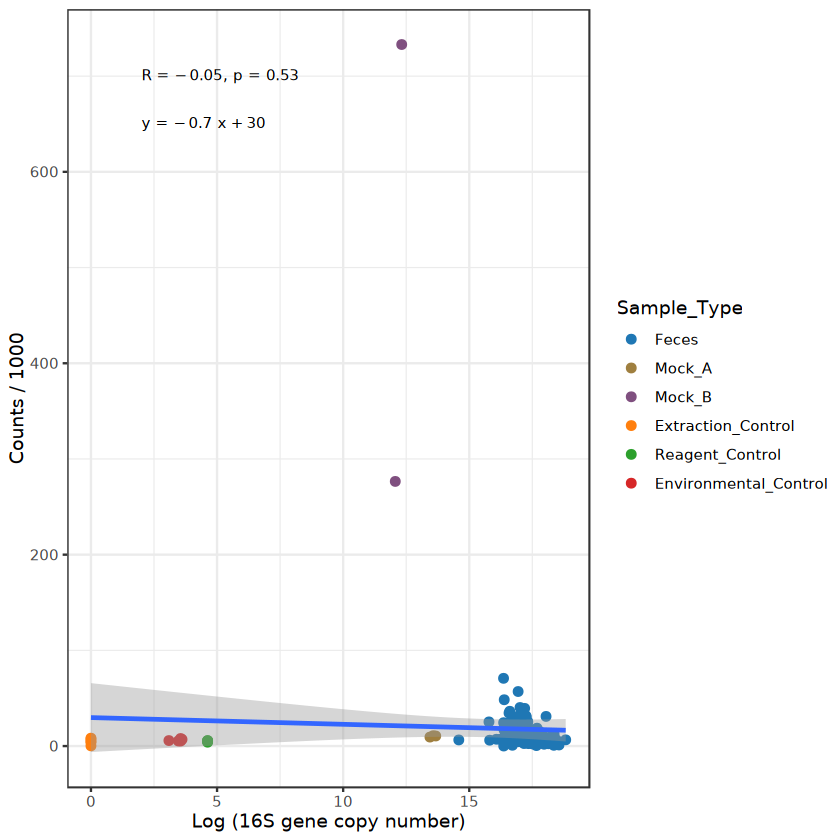

In [120]:
metadata_contam <- data.frame(sample_data(ps.contam))

# Set up the data for the plot
metadata_contam$Sample_ID <- rownames(metadata_contam) 
counts <- data.frame(sample_sums(ps.contam))
colnames(counts) <- "counts"
counts$Sample_ID <- rownames(counts)
metadata_contam <- as.data.frame(left_join(metadata_contam, counts, by = "Sample_ID"))
metadata_contam$Sample_Type <- factor(metadata_contam$Sample_Type, levels =  SAMPLE_TYPES)

# Check the type of input in the qPCR colums 
metadata_contam$qpcr_16s_copies_ul <- as.numeric(
  gsub(",", "", metadata_contam$qpcr_16s_copies_ul)
)

# Plot all the samples and controls
p.contam.counts <- ggplot(data = metadata_contam, aes(x = log(qpcr_16s_copies_ul), y = counts / 1000)) +
  geom_point(aes(color = Sample_Type), size = 2) +
  geom_smooth(aes(group = 1), method = "lm", se = TRUE) +
  stat_cor(label.x = 2, label.y = 700, size = 3) +
  stat_regline_equation(label.x = 2, label.y = 650, size = 3) +
  xlab("Log (16S gene copy number)") +
  ylab("Counts / 1000") +
  scale_color_manual(values = my_palette)

p.contam.counts # 16S gene copy number vs abundance of contaminants

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_cor()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_regline_equation()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


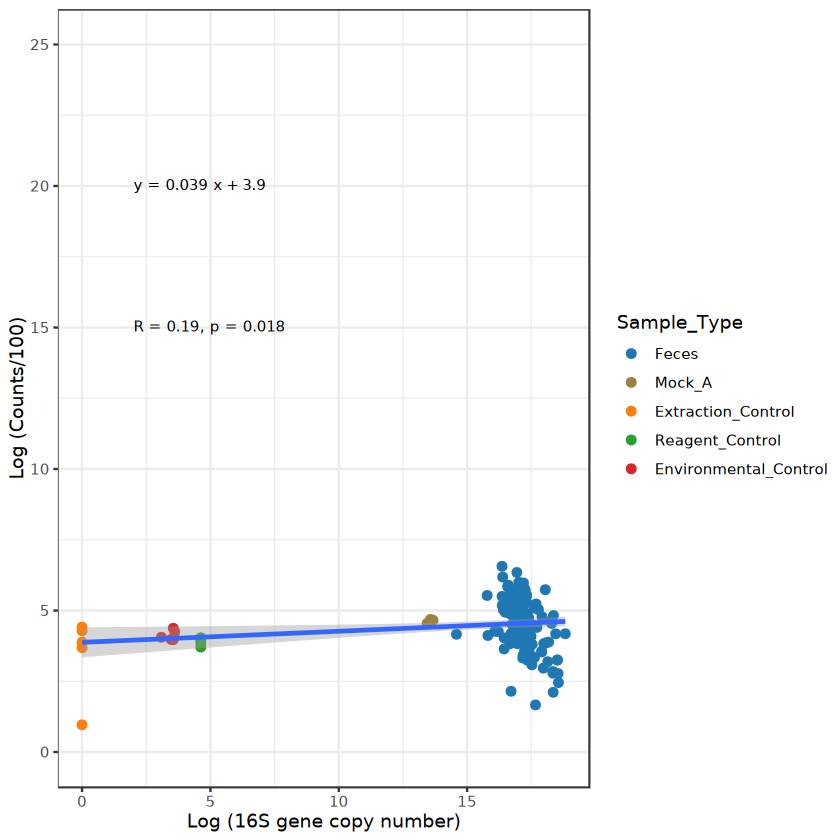

In [121]:
# Plot for the samples and controls, except Mock_B
metadata_plot_wo.MockB <- metadata_contam %>% filter(Sample_Type != "Mock_B")
p.contam.counts.wo.MockB <- ggplot(data = metadata_plot_wo.MockB,
                                   aes(x = log(qpcr_16s_copies_ul), 
                                       y = log(counts/100))) +
  geom_point(aes(color = Sample_Type), size = 2) +
  geom_smooth(aes(group = 1), method = "lm", se = TRUE) +
  stat_cor(label.x = 2, label.y = 15, size = 3) +
  stat_regline_equation(label.x = 2, label.y = 20, size = 3) +
  xlab("Log (16S gene copy number)") +
  ylab("Log (Counts/100)") +
  ylim(0, 25) +
  scale_color_manual(values = my_palette)

p.contam.counts.wo.MockB 

Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


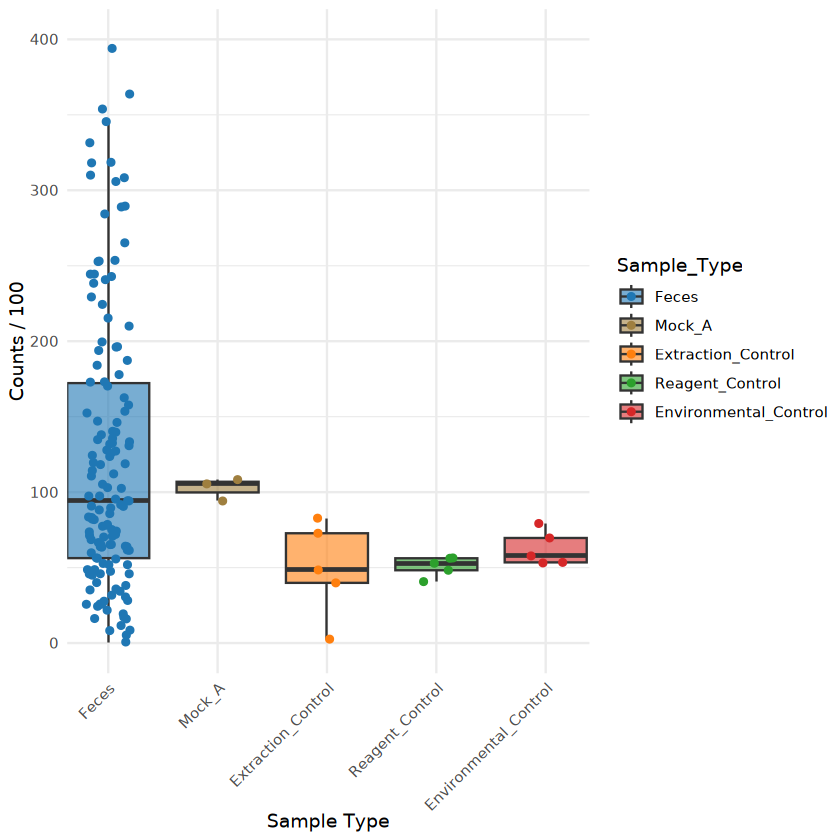

In [122]:
# Box plot without Mock B

p.contam.counts.wo.MockB.BP <-  ggplot(metadata_plot_wo.MockB,
                           aes(x = Sample_Type, y = counts / 100, fill = Sample_Type)) +
  geom_boxplot(alpha = 0.6, outlier.shape = NA) +
  geom_jitter(aes(color = Sample_Type), width = 0.2, size = 1.5) +
  ylab("Counts / 100") +
  xlab("Sample Type") +
  scale_fill_manual(values = my_palette) +
  scale_color_manual(values = my_palette) +
  theme_minimal()

# Print plot
p.contam.counts.wo.MockB.BP + 
  ylim(0, 400) +  
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
  scale_x_discrete(expand = expansion(mult = c(0.05, 0.1))) 

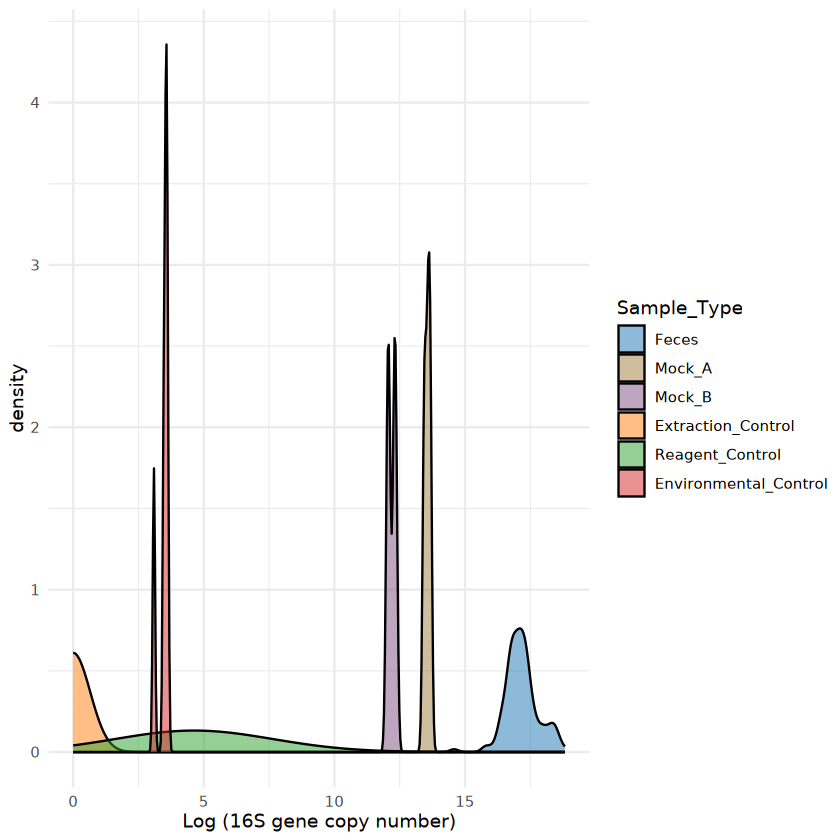

In [123]:
# Density Plot
# Visualize distribution of contaminants across copy numbers.
ggplot(metadata_contam, aes(x = log(qpcr_16s_copies_ul), fill = Sample_Type)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(values = my_palette) +
  xlab("Log (16S gene copy number)") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'
Warning message in qt((1 - level)/2, df):
“NaNs produced”
Warning message in max(ids, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”


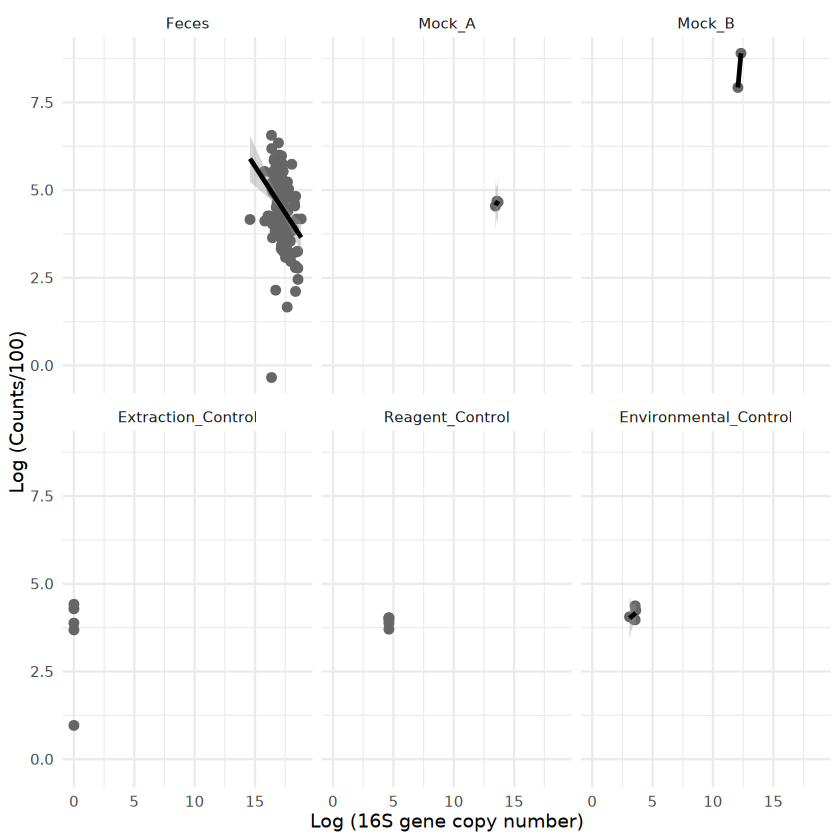

In [124]:
# Facet by Sample Type 
# See the relationship per group without overplotting

ggplot(metadata_contam, aes(x = log(qpcr_16s_copies_ul), y = log(counts / 100))) +
  geom_point(color = "gray40", size = 2) +
  geom_smooth(method = "lm", se = TRUE, color = "black") +
  facet_wrap(~ Sample_Type) +
  xlab("Log (16S gene copy number)") +
  ylab("Log (Counts/100)") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“span too small.   fewer data values than degrees of freedom.”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at 13.44”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.12989”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.010282”
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
“span too small.   fewer data values than degrees of freedom.”
Warning message in predLoess(object$y, object$x, newx = if (

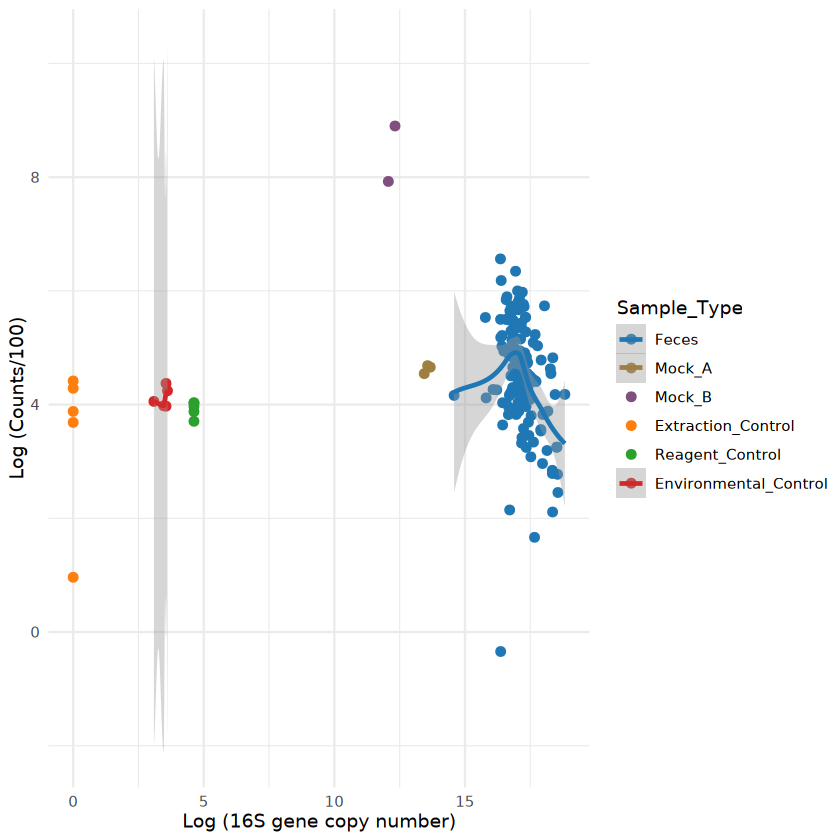

In [125]:
# LOESS instead of linear, to better capture curves in the data.
# LOESS can adapt to small local trends even with high variability 

ggplot(metadata_contam, aes(x = log(qpcr_16s_copies_ul), y = log(counts / 100), color = Sample_Type)) +
  geom_point(size = 2) +
  geom_smooth(method = "loess", se = TRUE,  span = 0.7) +
  scale_color_manual(values = my_palette) +
  xlab("Log (16S gene copy number)") +
  ylab("Log (Counts/100)") +
  theme_minimal()

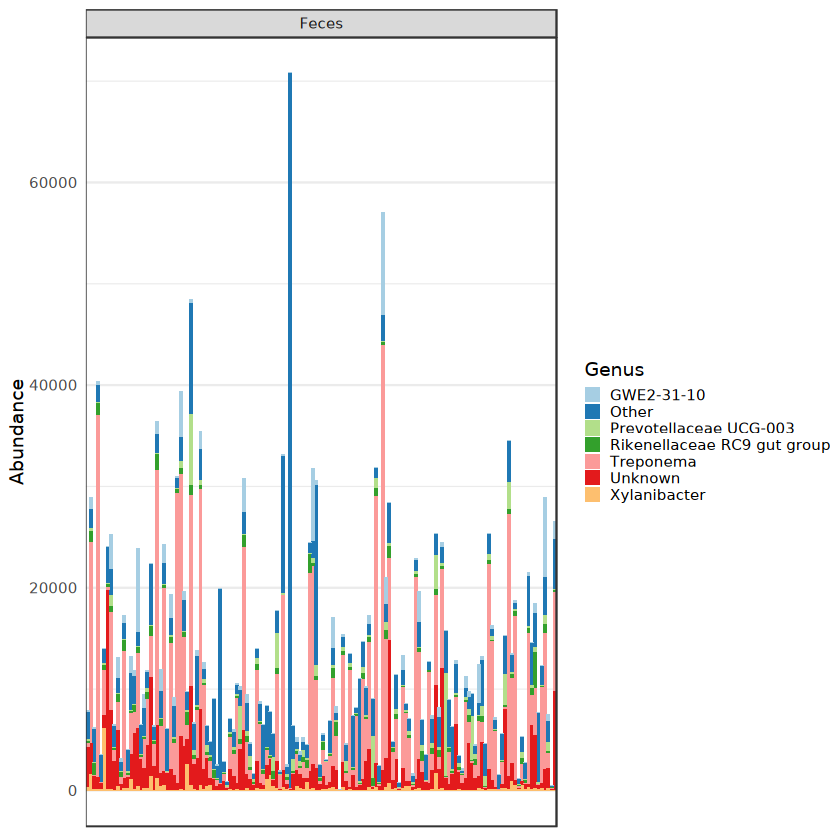

In [126]:
## Plot the Abundance of Contaminants
# Data
detection <- sum(taxa_sums(ps.contam))/162*0.05
pseq.contam <- aggregate_rare(ps.contam, 
                              level="Genus", 
                              detection = detection,
                              prevalence = 0.05)

melt.contam <- psmelt(pseq.contam)
# Plot for Feces
p.contam1 <- ggplot(
  melt.contam %>% filter(Sample_Type == "Feces"), 
  aes(x = Sample_ID, 
      y = Abundance, 
      fill = Genus)) +
  geom_bar(stat = "identity") +
  facet_grid(. ~ Sample_Type, 
             scales = "free_x", 
             space = "free") +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks = element_blank(),
    legend.key.size = unit(10, "pt"),
    panel.grid.major.x = element_blank()
  ) +
  scale_fill_brewer("Genus", palette = "Paired")
p.contam1

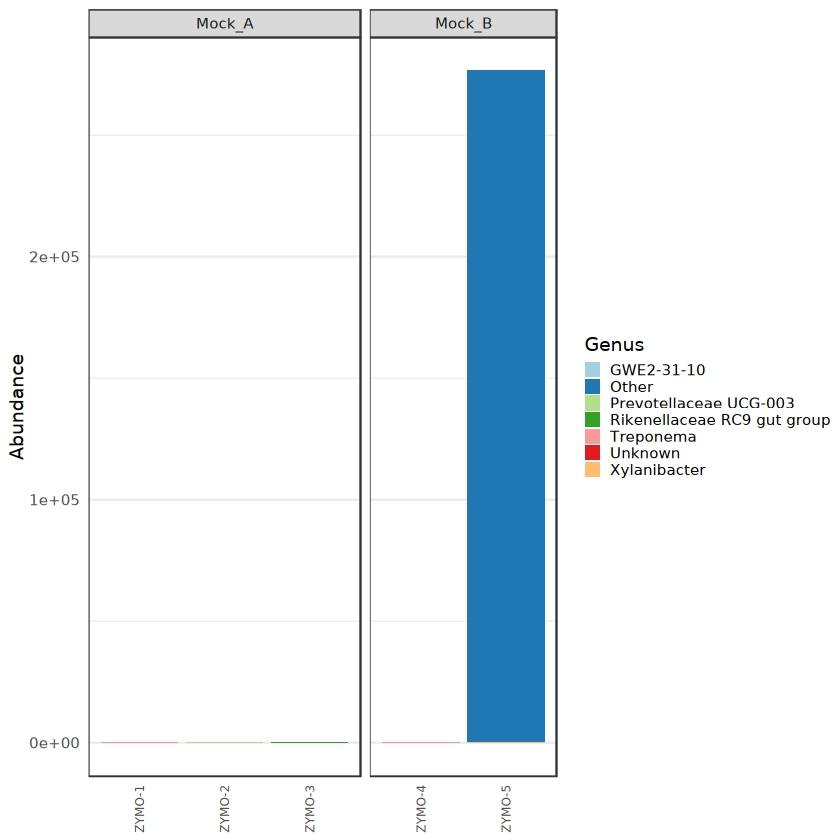

In [127]:
# Plot for Mock Communities 

p.contam3 <- ggplot(
  melt.contam %>% filter(Sample_Type == c( "Mock_A", 
                                           "Mock_B")),
  aes(x = Sample_ID, y = Abundance, fill = Genus)) +
    geom_bar(stat = "identity") +
  facet_grid(. ~ Sample_Type, 
             scales = "free_x", 
             space = "free") +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 7), 
    axis.ticks = element_blank(),
    legend.key.size = unit(10, "pt"),
    panel.grid.major.x = element_blank()
  ) +
  scale_fill_brewer("Genus", palette = "Paired")

p.contam3

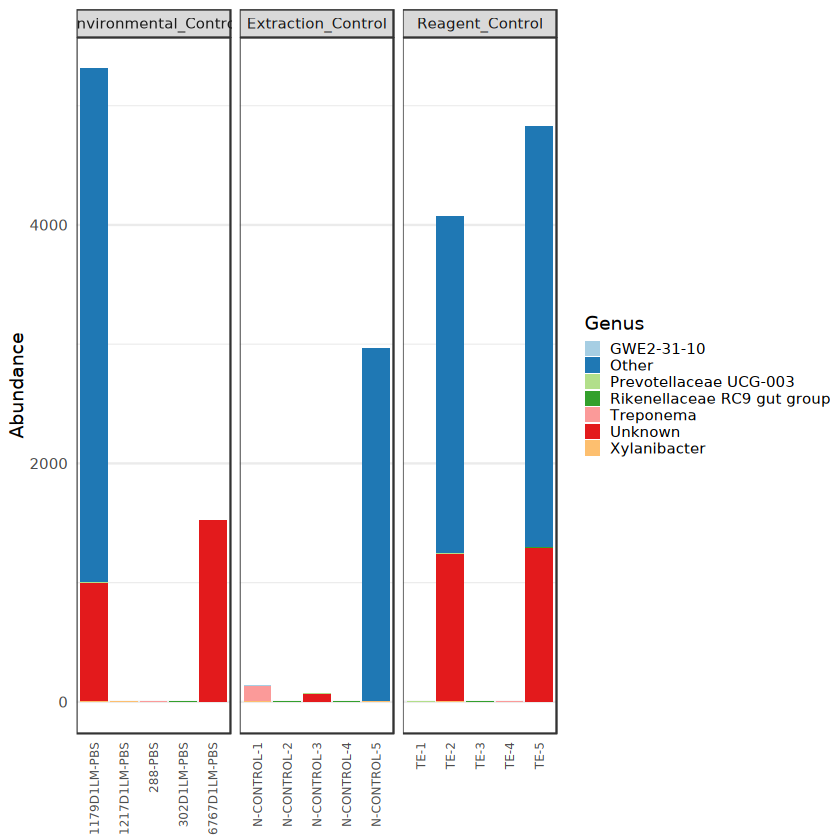

In [128]:
# Plot for Negative Controls
p.contam2 <- ggplot(
  melt.contam %>% filter(Sample_Type == c("Environmental_Control",
    "Extraction_Control", "Reagent_Control")),
  aes(x = Sample_ID, y = Abundance, fill = Genus)) +
    geom_bar(stat = "identity") +
  facet_grid(. ~ Sample_Type, 
             scales = "free_x", 
             space = "free") +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x =  element_text(angle = 90, vjust = 0.5, hjust = 1, size = 7), 
    axis.ticks = element_blank(),
    legend.key.size = unit(10, "pt"),
    panel.grid.major.x = element_blank()
  ) +
  scale_fill_brewer("Genus", palette = "Paired")

p.contam2

In [129]:
# Subset only Feces samples and Positive controls
ps.contam.sample <- subset_samples(ps.contam, 
                                   Sample_Type %in% c("Feces",
                                                      "Mock_A",
                                                      "Mock_B" ))


ps.contam.sample <- prune_taxa(taxa_sums(ps.contam)>0, 
                               ps.contam.sample)

type_colors <- c("Feces" = "#1f77b4", 
                 "Mock_A" = "#2ca02c",
                 "Mock_B"= "#d62728")


ord.bray.nmds.contam <- ordinate(ps.contam.sample, 
                                 "NMDS", 
                                 "bray", 
                                 k=4, 
                                 trymax = 1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1884118 
Run 1 stress 0.1882229 
... New best solution
... Procrustes: rmse 0.03398837  max resid 0.1611137 
Run 2 stress 0.1882412 
... Procrustes: rmse 0.04474665  max resid 0.1217092 
Run 3 stress 0.18799 
... New best solution
... Procrustes: rmse 0.04717057  max resid 0.1401138 
Run 4 stress 0.1887392 
Run 5 stress 0.1884945 
Run 6 stress 0.1884938 
Run 7 stress 0.1883854 
... Procrustes: rmse 0.02176306  max resid 0.1131482 
Run 8 stress 0.1882561 
... Procrustes: rmse 0.01896623  max resid 0.1107995 
Run 9 stress 0.1899974 
Run 10 stress 0.1880195 
... Procrustes: rmse 0.04168253  max resid 0.1575318 
Run 11 stress 0.1880227 
... Procrustes: rmse 0.02013238  max resid 0.09709866 
Run 12 stress 0.1883658 
... Procrustes: rmse 0.05016795  max resid 0.1742781 
Run 13 stress 0.1894245 
Run 14 stress 0.1885256 
Run 15 stress 0.1888069 
Run 16 stress 0.1891804 
Run 17 stress 0.1893509 
Run 18 stress 0.1893519 


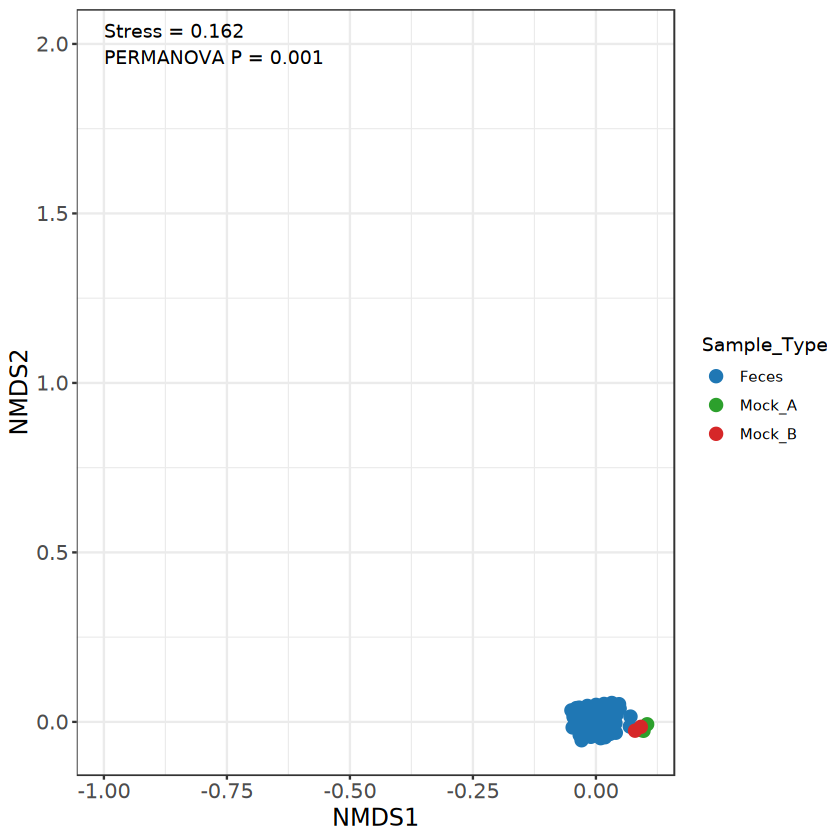

In [130]:
# PERMANOVA
ord.pnmds.contam <- plot_ordination(ps.contam.sample, ord.bray.nmds.contam, color = "Sample_Type") +
 geom_point(size = 3.0) +
 theme_bw() +
 scale_color_manual(values = type_colors) +
 theme(axis.text = element_text(size = 12),
 axis.title = element_text(size = 14),
 plot.title = element_text(hjust=0.5))+
 annotate("text", x = -1, y = 2, label = "Stress = 0.162\nPERMANOVA P = 0.001",
 hjust = 0)
print(ord.pnmds.contam) # NMDS of contaminants

In [131]:

bray.dist.contam<-vegdist(otu_table(ps.contam.sample), method='bray')
metadata.sample <- sample_data(ps.contam.sample) %>% data.frame()
beta_div.contam <-pairwise.adonis2(bray.dist.contam ~ Sample_Type, 
                                   data=metadata.sample, 
                                   permutations=999)

'nperm' >= set of all permutations: complete enumeration.

Set of permutations < 'minperm'. Generating entire set.



In [132]:
beta_div.contam

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model,1,1.813458,0.03292395,4.868412,0.001
Residual,143,53.266748,0.96707605,NA,NA
Total,144,55.080206,1.00000000,NA,NA
,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model,1,1.131554,0.020767,3.011452,0.001
Residual,142,53.356543,0.979233,NA,NA
Total,143,54.488097,1.000000,NA,NA
,Df,SumOfSqs,R2,F,Pr(>F)


In [133]:
#### Sourcetracker


In [134]:
# SourceTracker Libraries
library (dplyr)
library (phyloseq)
library (vegan)
library (ggplot2)
library (tidyr)
library (data.table)
library(devtools)
library (pairwiseAdonis)
library (microbiome)
library (patchwork)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:ShortRead’:

    tables


The following objects are masked from ‘package:GenomicAlignments’:

    first, last, second


The following object is masked from ‘package:SummarizedExperiment’:

    shift


The following object is masked from ‘package:GenomicRanges’:

    shift


The following object is masked from ‘package:IRanges’:

    shift


The following objects are masked from ‘package:S4Vectors’:

    first, second


Loading required package: usethis


Attaching package: ‘devtools’


The following object is masked from ‘package:permute’:

    check




In [135]:
# Step 1: Install dependencies (only once)
install.packages(c("vegan", "gtools"))

# Step 2: Download SourceTracker R script
download.file("https://raw.githubusercontent.com/danknights/sourcetracker/master/src/SourceTracker.r",
              destfile = "SourceTracker.r", method = "libcurl")

# Step 3: Load the script
source("SourceTracker.r")


Installing packages into ‘/home/ldas/R/x86_64-conda-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)

Warning message in install.packages(c("vegan", "gtools")):
“installation of package ‘vegan’ had non-zero exit status”
Warning message in install.packages(c("vegan", "gtools")):
“installation of package ‘gtools’ had non-zero exit status”


In [136]:
# Step 3: Load the script
source("SourceTracker.r")


In [137]:
#Phyloseq Object after Decontam
ps.decontam <- readRDS(file.path(path.rds,"ps.decontam.rds"))
ps.decontam

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 20953 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 68 sample variables ]
tax_table()   Taxonomy Table:    [ 20953 taxa by 7 taxonomic ranks ]

In [138]:
# Metadata / Label samples as source or sink
metadata <- as.data.frame(sample_data(ps.decontam))
metadata$SourceSink <- NA
metadata$SourceSink[ metadata$Sample_Type %in% 
    c("Reagent_Control", "Extraction_Control", "Environmental_Control") ] <- "source"
metadata$SourceSink[ metadata$Sample_Type %in% 
    c("Feces", "Mock_A", "Mock_B") ] <- "sink"
metadata$SourceSink

[1] "sink"   "sink"   "source" "sink"   "sink"   "source" "sink"   "sink"  
  [9] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [17] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [25] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [33] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "source" "sink"  
 [41] "sink"   "source" "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [49] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [57] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [65] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [73] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [81] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [89] "source" "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [97] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[105] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[113] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[121] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[129] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[137] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[145] "sink"   "sink"   "sink"   "source" "source" "source" "source" "source"
[153] "source" "source" "source" "source" "source" "sink"   "sink"   "sink"  
[161] "sink"   "sink"

In [159]:
# Prepare OTU matrix
# Sourcetracker wants the sample names as rows in an otu table and the metadatafile, which is the opposite of how phyloseq likes it!
otus <- as.matrix(data.frame(otu_table(ps.decontam)))
dim(otus) # 20953 (OTUs),   162 (Samples)

[1]   162 20953

In [161]:
# Extract only those samples in common between the two tables (metadata and otus):
common.sample.ids  <- intersect(rownames(metadata),rownames(otus))
st_otus <- otus[common.sample.ids , , drop = FALSE]
metadata <- metadata[common.sample.ids , , drop = FALSE]


# Double-check that the mapping file and otu table had overlapping samples:
if(length(common.sample.ids) <= 1) {
 message <- paste(sprintf('Error: there are %d sample ids in
 common '),'between the metadata file
 and data table')
 stop(message)
}

In [162]:
# Train the model 
# Extract the source environments and source/sink indices
train.ix <- which(metadata$SourceSink=='source')
test.ix <- which(metadata$SourceSink=='sink')


# Check sink OTU table dimensions:
dim(otus[test.ix, ]) 
length(test.ix) 
# env
envs <- metadata$Sample_Type
envs

[1]   147 20953

[1] 147

[1] "Feces"                 "Feces"                 "Environmental_Control"
  [4] "Feces"                 "Feces"                 "Environmental_Control"
  [7] "Feces"                 "Feces"                 "Feces"                
 [10] "Feces"                 "Feces"                 "Feces"                
 [13] "Feces"                 "Feces"                 "Feces"                
 [16] "Feces"                 "Feces"                 "Feces"                
 [19] "Feces"                 "Feces"                 "Feces"                
 [22] "Feces"                 "Feces"                 "Feces"                
 [25] "Feces"                 "Feces"                 "Feces"                
 [28] "Feces"                 "Feces"                 "Feces"                
 [31] "Feces"                 "Feces"                 "Feces"                
 [34] "Feces"                 "Feces"                 "Feces"                
 [37] "Feces"                 "Feces"                 "Environmental_Control"
 [40] "Feces"                 "Feces"                 "Environmental_Control"
 [43] "Feces"                 "Feces"                 "Feces"                
 [46] "Feces"                 "Feces"                 "Feces"                
 [49] "Feces"                 "Feces"                 "Feces"                
 [52] "Feces"                 "Feces"                 "Feces"                
 [55] "Feces"                 "Feces"                 "Feces"                
 [58] "Feces"                 "Feces"                 "Feces"                
 [61] "Feces"                 "Feces"                 "Feces"                
 [64] "Feces"                 "Feces"                 "Feces"                
 [67] "Feces"                 "Feces"                 "Feces"                
 [70] "Feces"                 "Feces"                 "Feces"                
 [73] "Feces"                 "Feces"                 "Feces"                
 [76] "Feces"                 "Feces"                 "Feces"                
 [79] "Feces"                 "Feces"                 "Feces"                
 [82] "Feces"                 "Feces"                 "Feces"                
 [85] "Feces"                 "Feces"                 "Feces"                
 [88] "Feces"                 "Environmental_Control" "Feces"                
 [91] "Feces"                 "Feces"                 "Feces"                
 [94] "Feces"                 "Feces"                 "Feces"                
 [97] "Feces"                 "Feces"                 "Feces"                
[100] "Feces"                 "Feces"                 "Feces"                
[103] "Feces"                 "Feces"                 "Feces"                
[106] "Feces"                 "Feces"                 "Feces"                
[109] "Feces"                 "Feces"                 "Feces"                
[112] "Feces"                 "Feces"                 "Feces"                
[115] "Feces"                 "Feces"                 "Feces"                
[118] "Feces"                 "Feces"                 "Feces"                
[121] "Feces"                 "Feces"                 "Feces"                
[124] "Feces"                 "Feces"                 "Feces"                
[127] "Feces"                 "Feces"                 "Feces"                
[130] "Feces"                 "Feces"                 "Feces"                
[133] "Feces"                 "Feces"                 "Feces"                
[136] "Feces"                 "Feces"                 "Feces"                
[139] "Feces"                 "Feces"                 "Feces"                
[142] "Feces"                 "Feces"                 "Feces"                
[145] "Feces"                 "Feces"                 "Feces"                
[148] "Extraction_Control"    "Extraction_Control"    "Extraction_Control"   
[151] "Extraction_Control"    "Extraction_Control"    "Reagent_Control"      
[154] "Reagent_Control" 

In [163]:
if(is.element('Cow_ID',colnames(metadata))) desc <- metadata$Cow_ID

In [164]:
#Tune the alpha values using cross-validation (this is slow!)
alpha1 <- alpha2 <- 0.001
alpha1 # 0.001
alpha2 # 0.001

[1] 0.001

[1] 0.001

In [165]:
# Train SourceTracker object on training data
st <- sourcetracker(otus[train.ix,],  envs[train.ix], rarefaction_depth = NULL)

In [166]:
#Export Data
otu_train <-otus[train.ix,]
otu_envs <-envs[train.ix]

# Export SourceTracker model and data splits
saveRDS(st, file.path(path.rds, "st.rds"))
saveRDS(otu_train, file.path(path.rds, "otu_train.rds"))
saveRDS(otu_envs, file.path(path.rds, "otu_envs.rds"))
saveRDS(envs, file.path(path.rds, "envs.rds"))
saveRDS(train.ix, file.path(path.rds, "train.ix.rds"))
saveRDS(test.ix, file.path(path.rds, "test.ix.rds"))


In [ ]:
# Prediction
# Define auto rarefaction depth based on training sample read counts
rarefaction_auto <- min(rowSums(otus[train.ix, ]))
rarefaction <- rarefaction_auto


# Predict source proportions in parallel
results <- predict(st,otus[test.ix,], 
                   alpha1=alpha1, 
                   alpha2=alpha2,
                   full.results = TRUE,
                   rarefaction_depth =rarefaction)

# Save the results
saveRDS(results, file.path(path.rds, "sourcetracker_results.rds"))

In [147]:
# Define the same path 
path.rds <- "/scratch/negishi/ldas/COW_INFLAMMATION"  

# Reload the R object
results <- readRDS(file.path(path.rds, "sourcetracker_results.rds"))


In [157]:
# Check structure of the results object
str(results)

# Check the names of the list
names(results)

# Specifically look at the $draws
results$draws


List of 6
 $ draws         : num [1:10, 1:4, 1:147] 0 0 0 0 0 0 0 0 0 0 ...
 $ proportions   : num [1:147, 1:4] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:147] "1165D1LM" "1165D3LM" "1179D1LM" "1179D3LM" ...
  .. ..$ : chr [1:4] "Environmental_Control" "Extraction_Control" "Reagent_Control" "Unknown"
 $ proportions_sd: num [1:147, 1:4] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:147] "1165D1LM" "1165D3LM" "1179D1LM" "1179D3LM" ...
  .. ..$ : chr [1:4] "Environmental_Control" "Extraction_Control" "Reagent_Control" "Unknown"
 $ train.envs    : chr [1:4] "Environmental_Control" "Extraction_Control" "Reagent_Control" "Unknown"
 $ samplenames   : chr [1:147] "1165D1LM" "1165D3LM" "1179D1LM" "1179D3LM" ...
 $ full.results  : int [1:10, 1:4, 1:20953, 1:147] 0 0 0 0 0 0 0 0 0 0 ...
 - attr(*, "class")= chr "sourcetracker.fit"


[1] "draws"          "proportions"    "proportions_sd" "train.envs"    
[5] "samplenames"    "full.results"

, , 1

      [,1]      [,2] [,3]      [,4]
 [1,]    0 0.0751174    0 0.9248826
 [2,]    0 0.0751174    0 0.9248826
 [3,]    0 0.0892019    0 0.9107981
 [4,]    0 0.0845070    0 0.9154930
 [5,]    0 0.0704225    0 0.9295775
 [6,]    0 0.0704225    0 0.9295775
 [7,]    0 0.0845070    0 0.9154930
 [8,]    0 0.0892019    0 0.9107981
 [9,]    0 0.0657277    0 0.9342723
[10,]    0 0.0798122    0 0.9201878

, , 2

      [,1]      [,2] [,3]      [,4]
 [1,]    0 0.1173709    0 0.8826291
 [2,]    0 0.1032864    0 0.8967136
 [3,]    0 0.1173709    0 0.8826291
 [4,]    0 0.1032864    0 0.8967136
 [5,]    0 0.1079812    0 0.8920188
 [6,]    0 0.1220657    0 0.8779343
 [7,]    0 0.1173709    0 0.8826291
 [8,]    0 0.1126761    0 0.8873239
 [9,]    0 0.1173709    0 0.8826291
[10,]    0 0.1220657    0 0.8779343

, , 3

      [,1]      [,2] [,3]      [,4]
 [1,]    0 0.0845070    0 0.9154930
 [2,]    0 0.0798122    0 0.9201878
 [3,]    0 0.0938967    0 0.9061033
 [4,]    0 0.0704225    0 0.9295775
 [5,]    0 0.0938967    0 0.9061033
 [6,]    0 0.0657277    0 0.9342723
 [7,]    0 0.0751174    0 0.9248826
 [8,]    0 0.0610329    0 0.9389671
 [9,]    0 0.0985915    0 0.9014085
[10,]    0 0.0938967    0 0.9061033

, , 4

      [,1]      [,2] [,3]      [,4]
 [1,]    0 0.1220657    0 0.8779343
 [2,]    0 0.1596244    0 0.8403756
 [3,]    0 0.1596244    0 0.8403756
 [4,]    0 0.1455399    0 0.8544601
 [5,]    0 0.1502347    0 0.8497653
 [6,]    0 0.1361502    0 0.8638498
 [7,]    0 0.1408451    0 0.8591549
 [8,]    0 0.1220657    0 0.8779343
 [9,]    0 0.1455399    0 0.8544601
[10,]    0 0.1361502    0 0.8638498

, , 5

      [,1]      [,2] [,3]      [,4]
 [1,]    0 0.1267606    0 0.8732394
 [2,]    0 0.0845070    0 0.9154930
 [3,]    0 0.0892019    0 0.9107981
 [4,]    0 0.0892019    0 0.9107981
 [5,]    0 0.0892019    0 0.9107981
 [6,]    0 0.1032864    0 0.8967136
 [7,]    0 0.1267606    0 0.8732394
 [8,]    0 0.1314554    0 0.8685446
 [9,]    0 0.1220657    0 0.8779343
[10,]    0 0.1126761    0 0.8873239

, , 6

      [,1]      [,2] [,3]      [,4]
 [1,]    0 0.0610329    0 0.9389671
 [2,]    0 0.0657277    0 0.9342723
 [3,]    0 0.0704225    0 0.9295775
 [4,]    0 0.0845070    0 0.9154930
 [5,]    0 0.0610329    0 0.9389671
 [6,]    0 0.0516432    0 0.9483568
 [7,]    0 0.0657277    0 0.9342723
 [8,]    0 0.0704225    0 0.9295775
 [9,]    0 0.1079812    0 0.8920188
[10,]    0 0.0985915    0 0.9014085

, , 7

      [,1]      [,2] [,3]      [,4]
 [1,]    0 0.1408451    0 0.8591549
 [2,]    0 0.1173709    0 0.8826291
 [3,]    0 0.1267606    0 0.8732394
 [4,]    0 0.1361502    0 0.8638498
 [5,]    0 0.1267606    0 0.8732394
 [6,]    0 0.1408451    0 0.8591549
 [7,]    0 0.1361502    0 0.8638498
 [8,]    0 0.1267606    0 0.8732394
 [9,]    0 0.1361502    0 0.8638498
[10,]    0 0.1126761    0 0.8873239

, , 8

      [,1]      [,2] [,3]      [,4]
 [1,]    0 0.1126761    0 0.8873239
 [2,]    0 0.1314554    0 0.8685446
 [3,]    0 0.1079812    0 0.8920188
 [4,]    0 0.1126761    0 0.8873239
 [5,]    0 0.1267606    0 0.8732394
 [6,]    0 0.1267606    0 0.8732394
 [7,]    0 0.1220657    0 0.8779343
 [8,]    0 0.1173709    0 0.8826291
 [9,]    0 0.1173709    0 0.8826291
[10,]    0 0.1173709    0 0.8826291

, , 9

      [,1]      [,2] [,3]      [,4]
 [1,]    0 0.0845070    0 0.9154930
 [2,]    0 0.0845070    0 0.9154930
 [3,]    0 0.0751174    0 0.9248826
 [4,]    0 0.0892019    0 0.9107981
 [5,]    0 0.0704225    0 0.9295775
 [6,]    0 0.0657277    0 0.9342723
 [7,]    0 0.0798122    0 0.9201878
 [8,]    0 0.0751174    0 0.9248826
 [9,]    0 0.0657277    0 0.9342723
[10,]    0 0.0845070    0 0.9154930

, , 10

      [,1]      [,2] [,3]      [,4]
 [1,]    0 0.0751174    0 0.9248826
 [2,]    0 0.0610329    0 0.9389671
 [3,]    0 0.0610329    0 0.9389671
 [4,]    0 0.0751174    0 0.9248826
 [5,]    0 0.0704225    0 0.9295775
 [6,]    0 0.0751174    0 0.9248826
 [7,]    0 0.0516432    0 0.9483568
 [8,]    0 0.0798122    0 0.9201878
 [9,]    0 0.0704225    0 0.9295

In [155]:
class(results)
dim(results$draws)

[1] "list"

NULL

In [149]:
nrow(results$proportions)

NULL

In [150]:
prop <- results$proportions   # samples × sources
contaminants_proportion_table <- as.data.frame(results$proportions)
write.csv(contaminants_proportion_table,
          file = file.path(path.rds, "contaminants_proportion_table.csv"),
          row.names = FALSE,
          quote = FALSE)

# Now, check the contaminants information:
# Samples with any extraction contribution
extraction_pos <- rownames(prop)[ prop[,"Extraction_Control"] > 0.00 ]
str(extraction_pos)

 NULL


In [151]:
# Samples with any environmental contribution
environmental_pos <- rownames(prop)[ prop[,"Environmental_Control"] > 0 ]
str(environmental_pos)

 NULL


In [152]:
# Samples with any reagent contribution
reagent_pos <- rownames(prop)[ prop[,"Reagent_Control"] > 0 ]
str(reagent_pos)

 NULL


In [154]:
contaminant_sources <- list(
    extraction_pos       = extraction_pos,
  environmental_pos    = environmental_pos,
  reagent_pos          = reagent_pos
)

# Identify the ASVs that are contaminants:
contam_indices <- grep("Control", results$train.envs)
log_contam <- results$full.results[, contam_indices, , ] > 0
is_contaminant_asv <- apply(log_contam, MARGIN = 3, FUN = any)
asv_ids <- colnames(otus)
names(is_contaminant_asv) <- asv_ids
contaminant_asvs <- asv_ids[is_contaminant_asv] # vector of contaminant ASV names
cat(sprintf("Found %d contaminant ASVs.\n", length(contaminant_asvs)))

ERROR: Error in apply(log_contam, MARGIN = 3, FUN = any): dim(X) must have a positive length


In [ ]:
# Create directory to store outcomes
base_dir <- "~/Cow_Inflammation_Study/Decontamination/Analysis/Results"
outdir <- "Results_sourcetracker_cow"
filebase <- "ST_Cow_samples"
subdir <- file.path(base_dir, outdir, "full_results")
dir.create(subdir, showWarnings = FALSE, recursive = TRUE)

# Mean and Sample depths
res.mean <- apply(results$full.results,c(2,3,4),mean)  # Average of full results across all runs
sample.depths <- apply(results$full.results[1,,,,drop=F],4,sum) # Depth of each sample for relative abundance 

# write each environment as a separate file
for(i in 1:length(results$train.envs)){
  env.name <- results$train.envs[i]
  filename.fractions <- sprintf('%s/%s_%s_contributions.txt', subdir, filebase, env.name)
  res.mean.i <- res.mean[i,,]
  # handle the case where there is only one sink sample
  if(is.null(dim(res.mean.i))) res.mean.i <- matrix(res.mean.i,ncol=1)
  
  # make rows be samples, columns be features
  res.mean.i <- t(res.mean.i)
  
  # ensure proper names are retained
  colnames(res.mean.i) <- colnames(otus)[1:ncol(res.mean.i)]
  rownames(res.mean.i) <- results$samplenames
  
  # calculate and save relative abundance
  res.mean.i.ra <- sweep(res.mean.i,1,sample.depths,'/')
  sink(filename.fractions)
  cat('SampleID\t')
  write.table(res.mean.i.ra,quote=F,sep='\t')
  sink(NULL)
}

In [ ]:
# ----------- Define Directories and File Names -----------
base_dir <- "~/Cow_Inflammation_Study/Decontamination/Analysis/Results"
outdir <- file.path(base_dir, "Results_sourcetracker_cow")  # Directory for plots
filebase <- "ST_Cow_samples"
subdir <- file.path(outdir, "full_results")                 # Directory for tables

dir.create(outdir, showWarnings = FALSE, recursive = TRUE)
dir.create(subdir, showWarnings = FALSE, recursive = TRUE)

# ----------- Plot Setup -----------
plot.types <- c("pie")

# Extract Sample-Type Labels from Phyloseq
meta <- data.frame(sample_data(ps.decontam))
envs <- meta[rownames(results$proportions), "Sample_Type"]
envs <- as.factor(unlist(envs))
labels <- sprintf('%s_%s', envs, rownames(results$proportions))

# ----------- Plot Pie Charts per Sample Type -----------
for (plot.type in plot.types) {
  for (env in levels(envs)) {
    plotixs <- which(envs == env)
    
    out_png <- file.path(outdir, sprintf("%s_%s_%s.png", filebase, plot.type, env))
    
    png(out_png, width = 500, height = 500)
    plot(results,
         type = plot.type,
         labels = labels,
         include.legend = TRUE,
         indices = plotixs)
    dev.off()
  }
}

# ----------- Export Contribution Tables per Source Environment -----------
res.mean <- apply(results$full.results, c(2, 3, 4), mean)  # Mean across iterations
sample.depths <- apply(results$full.results[1,,,, drop = FALSE], 4, sum)

# Use otus matrix from results or define externally if needed
otus <- results$otu.table  # Make sure 'otu.table' exists

for (i in seq_along(results$train.envs)) {
  env.name <- results$train.envs[i]
  filename.fractions <- file.path(subdir, sprintf("%s_%s_contributions.txt", filebase, env.name))
  
  res.mean.i <- res.mean[i, , ]
  if (is.null(dim(res.mean.i))) {
    res.mean.i <- matrix(res.mean.i, ncol = 1)
  }
  
  # Transpose: rows = samples, columns = source features
  res.mean.i <- t(res.mean.i)
  colnames(res.mean.i) <- colnames(otus)[1:ncol(res.mean.i)]
  rownames(res.mean.i) <- results$samplenames
  
  # Convert to relative abundance
  res.mean.i.ra <- sweep(res.mean.i, 1, sample.depths, "/")
  
  # Export
  write.table(cbind(SampleID = rownames(res.mean.i.ra), res.mean.i.ra),
              file = filename.fractions,
              sep = "\t", quote = FALSE, row.names = FALSE)
}


In [101]:
# read phyloseq object after decontam
ps.decontam <- readRDS(file.path(path.rds, "ps.decontam.rds"))
ps.decontam

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 21010 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 21010 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 21010 reference sequences ]

In [102]:
target <- c("Feces", "Mock_A", "Mock_B")
ps.sink <- subset_samples(ps.decontam, Sample_Type %in% target)
ps.sink

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 21010 taxa and 147 samples ]
sample_data() Sample Data:       [ 147 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 21010 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 21010 reference sequences ]

In [110]:
# Load contributions
contrib_df <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/SourceTracker_contributions_with_contam.csv", row.names = 1, check.names = FALSE)

# Check dimensions and preview
dim(contrib_df)
head(contrib_df)

# If you want to keep only sink samples (e.g., feces), you’ll need metadata
meta <- sample_data(ps) %>% as.data.frame()
sink_samples <- rownames(meta)[meta$Sample_Type == "Feces"]  # or use your own category

# Subset the contribution table
contrib_sink_only <- contrib_df[rownames(contrib_df) %in% sink_samples, ]

# Check
head(contrib_sink_only)


[1] 142   4

,Environmental_Control,Extraction_Control,Reagent_Control,Unknown
,<dbl>,<dbl>,<dbl>,<dbl>
1,0.00042106,0.03178949,0.00021053,0.9675789
2,0.00000000,0.04400001,0.00042105,0.9555789
3,0.00000000,0.02210526,0.00000000,0.9778947
4,0.00042106,0.03768422,0.00021053,0.9616842
5,0.00000000,0.03178948,0.00000000,0.9682105
6,0.00000000,0.02147369,0.00000000,0.9785263


Environmental_Control,Extraction_Control,Reagent_Control,Unknown
<dbl>,<dbl>,<dbl>,<dbl>


In [111]:
# Sample depths 
sample.depths <- sample_sums(ps.sink) # Total reads per sample
length(sample.depths) 

[1] 147

In [132]:
# ----------- Combine all source proportions into one data frame ----------- #
contrib_df <- do.call(rbind, lapply(st_result, function(res) {
  prop <- res$proportions
  if (is.null(prop)) return(NULL)
  # Get sample name from row name of proportions matrix
  samp_name <- rownames(prop)[1]
  df <- as.data.frame(prop)
  rownames(df) <- samp_name
  df
}))

# Check structure
dim(contrib_df)
colnames(contrib_df)
head(contrib_df)


[1] 142   4

[1] "Environmental_Control" "Extraction_Control"    "Reagent_Control"      
[4] "Unknown"

,Environmental_Control,Extraction_Control,Reagent_Control,Unknown
,<dbl>,<dbl>,<dbl>,<dbl>
1165D1LM,6e-04,0.0381,5e-04,0.9608
1165D3LM,4e-04,0.0390,1e-04,0.9605
1179D1LM,0e+00,0.0251,0e+00,0.9749
1179D3LM,0e+00,0.0396,0e+00,0.9604
1217D1LM,0e+00,0.0201,2e-04,0.9797
1217D3LM,0e+00,0.0307,0e+00,0.9693


In [133]:
# Define contaminant sources
contam_sources <- c("Environmental_Control", "Extraction_Control", "Reagent_Control")

# Subset the contamination matrix
contam_df <- contrib_df[, contam_sources, drop = FALSE]

# Match to sample depths from your filtered phyloseq object
sample.depths <- sample_sums(ps.sink)
sample.depths <- sample.depths[rownames(contam_df)]

# Convert proportions to estimated read counts
contam_reads <- sweep(contam_df, 1, sample.depths, FUN = "*") %>% round()

# Save the output
out_path <- "/scratch/negishi/ldas/COW_INFLAMMATION"
write.csv(contam_reads,
          file = file.path(out_path, "Estimated_Contaminant_Reads.csv"),
          row.names = TRUE)


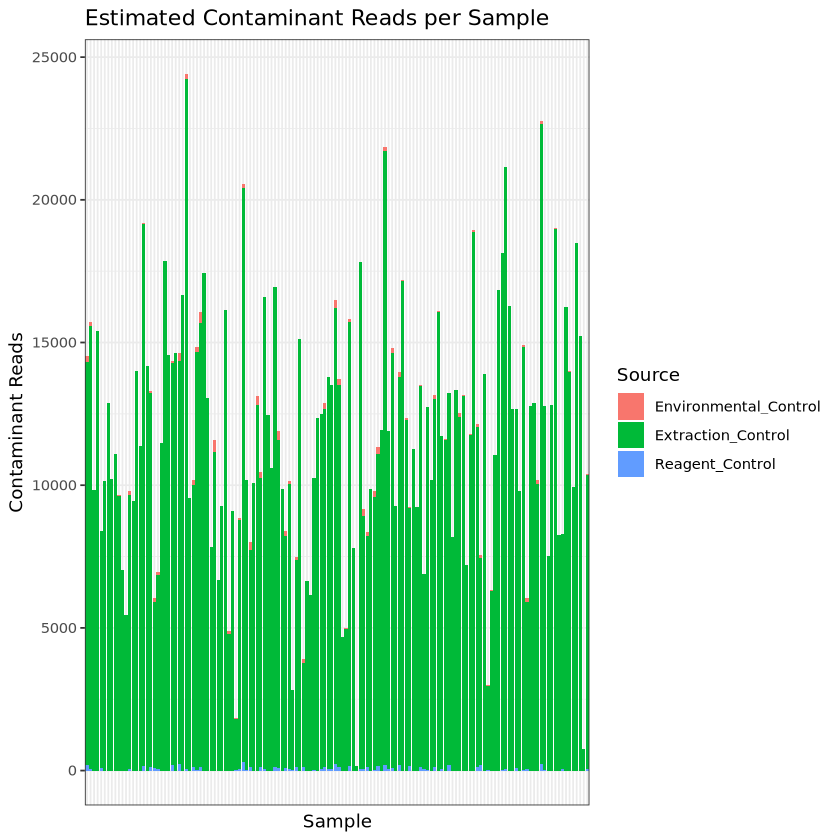

In [139]:
# Rebuild metadata from ps.sink (make sure it exists!)
meta <- as.data.frame(sample_data(ps.sink))
meta$SampleID <- rownames(meta)

# Reshape contaminant reads to long format
library(tidyr)
library(dplyr)

contam_long <- contam_reads %>%
  as.data.frame() %>%
  tibble::rownames_to_column("SampleID") %>%
  pivot_longer(cols = -SampleID, names_to = "Source", values_to = "ReadCount")

# Merge safely
contam_merged <- left_join(contam_long, meta, by = "SampleID")
library(ggplot2)

ggplot(contam_merged, aes(x = SampleID, y = ReadCount, fill = Source)) +
  geom_bar(stat = "identity") +
  theme_bw() +
  labs(title = "Estimated Contaminant Reads per Sample",
       x = "Sample", y = "Contaminant Reads") +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank())


In [134]:
# Load contaminant read estimates
contam_reads <- read.csv(file.path(out_path, "Estimated_Contaminant_Reads.csv"), row.names = 1)

# Transform to long format
library(tidyr)
library(ggplot2)

contam_long <- contam_reads %>%
  tibble::rownames_to_column("SampleID") %>%
  pivot_longer(-SampleID, names_to = "Source", values_to = "ReadCount")

# Merge with metadata
meta <- sample_data(ps.sink) %>% as.data.frame()
meta$SampleID <- rownames(meta)

contam_merged <- merge(contam_long, meta, by = "SampleID")

# Plot
ggplot(contam_merged, aes(x = SampleID, y = ReadCount, fill = Source)) +
  geom_bar(stat = "identity") +
  theme_bw() +
  labs(title = "Estimated Contaminant Reads per Sample",
       x = "Sample", y = "Contaminant Reads") +
  theme(axis.text.x = element_blank(),  # Hide x labels for readability
        axis.ticks.x = element_blank())


ERROR: Error in validObject(.Object): invalid class “sample_data” object: Sample Data must have non-zero dimensions.


In [126]:
# Step 1: Make sure you have contrib_df
contrib_df <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/SourceTracker_contributions_with_contam.csv", 
                       row.names = 1, check.names = FALSE)

# Step 2: Match sample names to your sink samples (make sure rownames align!)
meta <- sample_data(ps.sink) %>% as.data.frame()
sink_samples <- rownames(meta)
contrib_df <- contrib_df[rownames(contrib_df) %in% sink_samples, ]

# Step 3: Define contaminant sources
contam_sources <- c("Environmental_Control", "Extraction_Control", "Reagent_Control")

# Step 4: Create contam_list from contrib_df
contam_list <- lapply(contam_sources, function(source) {
  # Create a matrix with just the contribution of this source across samples
  mat <- matrix(contrib_df[[source]], ncol = 1)
  rownames(mat) <- rownames(contrib_df)
  colnames(mat) <- source
  mat
})
names(contam_list) <- contam_sources


ERROR: Error in read.table(file = file, header = header, sep = sep, quote = quote, : first five rows are empty: giving up


In [125]:
# Create the otu table for contaminants by multiplying sample depths. From contaminant fractions to contaminant counts
contam_sum <- Reduce(`+`, contam_list[c("Environmental_Control",
                                        "Extraction_Control",
                                        "Reagent_Control")])
dim(contam_sum)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'Reduce': object 'contam_list' not found


In [113]:
# Filter to sink sample
meta <- sample_data(ps) %>% as.data.frame()
sink_samples <- rownames(meta)[meta$Sample_Type == "Feces"]
contrib_sink <- contrib_df[rownames(contrib_df) %in% sink_samples, ]


In [124]:
# Get sample depths
sample_depths <- sample_sums(ps)  # if ps is your rarefied or unrarefied phyloseq object

# Ensure sample_depths is aligned with contrib_sink
sample_depths <- sample_depths[rownames(contrib_sink)]

# Multiply each row by the total reads to convert fractions to counts
contam_counts <- sweep(contrib_sink[, c("Environmental_Control", "Extraction_Control", "Reagent_Control")],
                       1, sample_depths, FUN = "*")

# Round to integers (counts)
contam_counts <- round(contam_counts)


In [73]:
# Step 1: Load SourceTracker result
st_result <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/sourcetracker_results.rds")

# Step 2: Rebuild full contribution table
contrib_df <- do.call(rbind, lapply(names(st_result), function(samp) {
  df <- as.data.frame(t(st_result[[samp]]$proportions))
  rownames(df) <- samp
  df
}))

# Step 3: Save to CSV
write.csv(contrib_df, 
          file = "/scratch/negishi/ldas/COW_INFLAMMATION/SourceTracker_contributions_with_contam.csv", 
          row.names = TRUE)


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'args' in selecting a method for function 'do.call': error in evaluating the argument 'x' in selecting a method for function 'as.data.frame': error in evaluating the argument 'x' in selecting a method for function 't': $ operator is invalid for atomic vectors


In [49]:
# Sample depths 
sample.depths <- sample_sums(ps.sink) # Total reads per sample
length(sample.depths) 

[1] 147

In [51]:
# Define contaminant sources
contam_sources <- c("Environmental_Control", "Extraction_Control", "Reagent_Control")

# Subset the contribution matrix to just contaminant sources
contam_prop <- contrib_df[, intersect(contam_sources, colnames(contrib_df)), drop = FALSE]


In [52]:
# Ensure rows match
contam_prop <- contam_prop[rownames(contam_prop) %in% names(sample_depths), ]
sample_depths <- sample_depths[rownames(contam_prop)]

# Multiply each row of proportions by corresponding sample depth
contam_counts <- sweep(contam_prop, 1, sample_depths, FUN = "*")

# Round to integer counts
contam_counts <- round(contam_counts)

# Inspect
head(contam_counts)


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'table' in selecting a method for function '%in%': object 'sample_depths' not found


In [50]:
# Create the otu table for contaminants by multiplying sample depths. From contaminant fractions to contaminant counts
contam_sum <- Reduce(`+`, contam_list[c("Environmental_Control",
                                        "Extraction_Control",
                                        "Reagent_Control")])
dim(contam_sum)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'Reduce': object 'contam_list' not found


In [81]:
# Step 1: Load all ASV lists
asv.freq <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_frequency.csv", stringsAsFactors = FALSE)
asv.prev <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_prevalence.csv", stringsAsFactors = FALSE)
asv.st   <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_sourcetracker.csv", stringsAsFactors = FALSE)

# Step 2: Standardize column name
colnames(asv.freq) <- "ASV_Sequence"
colnames(asv.prev) <- "ASV_Sequence"
colnames(asv.st)   <- "ASV_Sequence"

# Step 3: Trim whitespace
asv.freq$ASV_Sequence <- trimws(asv.freq$ASV_Sequence)
asv.prev$ASV_Sequence <- trimws(asv.prev$ASV_Sequence)
asv.st$ASV_Sequence   <- trimws(asv.st$ASV_Sequence)

# Step 4: Get shared contaminants
common_3way <- Reduce(intersect, list(asv.freq$ASV_Sequence, asv.prev$ASV_Sequence, asv.st$ASV_Sequence))
common_freq_prev <- intersect(asv.freq$ASV_Sequence, asv.prev$ASV_Sequence)
common_freq_st   <- intersect(asv.freq$ASV_Sequence, asv.st$ASV_Sequence)
common_prev_st   <- intersect(asv.prev$ASV_Sequence, asv.st$ASV_Sequence)

# Step 5: Summary
asv_summary <- data.frame(
  Category = c(
    "Frequency only",
    "Prevalence only",
    "SourceTracker only",
    "Frequency ∩ Prevalence",
    "Frequency ∩ SourceTracker",
    "Prevalence ∩ SourceTracker",
    "All Methods (Shared)"
  ),
  Num_ASVs = c(
    length(setdiff(asv.freq$ASV_Sequence, union(asv.prev$ASV_Sequence, asv.st$ASV_Sequence))),
    length(setdiff(asv.prev$ASV_Sequence, union(asv.freq$ASV_Sequence, asv.st$ASV_Sequence))),
    length(setdiff(asv.st$ASV_Sequence, union(asv.freq$ASV_Sequence, asv.prev$ASV_Sequence))),
    length(common_freq_prev),
    length(common_freq_st),
    length(common_prev_st),
    length(common_3way)
  )
)

# Print summary
print(asv_summary)

# Step 6: Save the shared ASVs
write.csv(data.frame(ASV_Sequence = common_3way),
          "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/common_contaminants_all_methods.csv",
          row.names = FALSE, quote = FALSE)


                    Category Num_ASVs
1             Frequency only     1882
2            Prevalence only      448
3         SourceTracker only        0
4     Frequency ∩ Prevalence       37
5  Frequency ∩ SourceTracker        0
6 Prevalence ∩ SourceTracker        0
7       All Methods (Shared)        0


In [8]:
library(ggplot2)
library(dplyr)
library(viridis)

# Ensure Source is a factor with all levels
all_sources <- unique(compiled_df$Source)
compiled_df <- compiled_df %>%
  mutate(Source = factor(Source, levels = all_sources))

# Order samples by contamination source proportion
contam_source <- "Unknown"
sample_order <- compiled_df %>%
  filter(Source == contam_source) %>%
  arrange(Proportion) %>%
  pull(Sample_ID) %>%
  unique()

compiled_df <- compiled_df %>%
  mutate(Sample_ID = factor(Sample_ID, levels = sample_order))

# Create the plot
p <- ggplot(compiled_df, aes(x = Sample_ID, y = Proportion, fill = Source)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_fill_viridis_d(
    option = "C",
    end = 0.9,
    direction = 1,
    name = "Source"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
    axis.title.x = element_text(margin = margin(t = 8)),
    axis.title.y = element_text(margin = margin(r = 8)),
    panel.grid.major.x = element_blank(),
    legend.position = "right",
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 9)
  ) +
  labs(
    title = "SourceTracker: All Source Contributions",
    x = "Sink Sample",
    y = "Proportion"
  )

# Save as high-resolution PNG
ggsave(
  filename = file.path(path.figures, "sourcetracker_viridis_plot.png"),
  plot     = p,
  width    = 10,
  height   = 6,
  units    = "in",
  dpi      = 300
)

# Save as high-resolution TIFF
ggsave(
  filename = file.path(path.figures, "sourcetracker_viridis_plot.tiff"),
  plot     = p,
  width    = 10,
  height   = 6,
  units    = "in",
  dpi      = 300,
  device   = "tiff"
)


Loading required package: viridisLite



ERROR: Error: object 'path.figures' not found


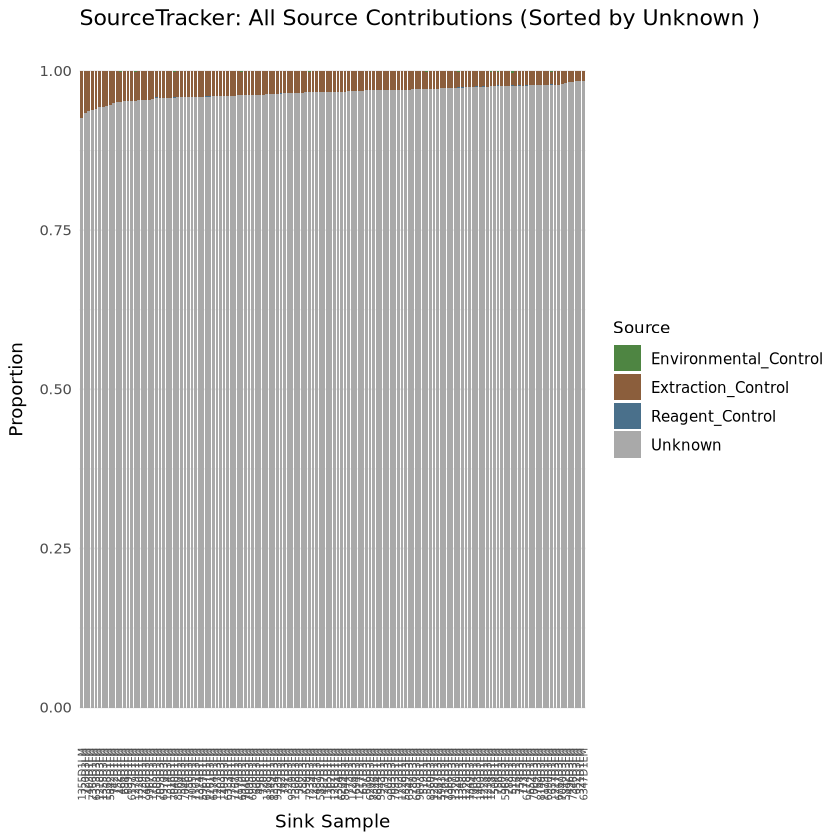

In [9]:
nature_palette <- c(
  "Environmental_Control" = "#4E8542",  # Forest green
  "Extraction_Control"    = "#8B5E3C",  # Earthy brown
  "Reagent_Control"       = "#4A708B",  # Slate blue
  "Unknown"               = "#A9A9A9"   # Ash gray
)
ggplot(compiled_df, aes(x = Sample_ID, y = Proportion, fill = Source)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_fill_manual(
    values = nature_palette,
    name = "Source"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
    axis.title.x = element_text(margin = margin(t = 8)),
    axis.title.y = element_text(margin = margin(r = 8)),
    panel.grid.major.x = element_blank(),
    legend.position = "right",
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 9)
  ) +
  labs(
    title = paste("SourceTracker: All Source Contributions (Sorted by", contam_source, ")"),
    x = "Sink Sample",
    y = "Proportion"
  )


In [10]:
#### Dual Stack plot
contam_source <- "Unknown"        # Source to sort by
output_basename <- "dualscale_sourcetracker_plot"
output_path <- path.figures       # Replace with your actual

# ─────────────────────────────
# Ensure all source levels are present and ordered
all_sources <- unique(compiled_df$Source)
compiled_df <- compiled_df %>%
  mutate(Source = factor(Source, levels = all_sources))

# Order samples by proportion of chosen source (e.g., Unknown)
sample_order <- compiled_df %>%
  filter(Source == contam_source) %>%
  arrange(Proportion) %>%
  pull(Sample_ID) %>%
  unique()

compiled_df <- compiled_df %>%
  mutate(Sample_ID = factor(Sample_ID, levels = sample_order))

# ─────────────────────────────


# Shared base aesthetics
base_plot <- ggplot(compiled_df, aes(x = Sample_ID, y = Proportion, fill = Source)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_fill_viridis_d(option = "C", end = 0.9, name = "Source") +
  theme_minimal(base_size = 10) +
  theme(
    axis.title.x = element_blank(),
    panel.grid.major.x = element_blank(),
    legend.position = "right",
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 9)
  )

# Full scale plot (0–1)
p_full <- base_plot +
  coord_cartesian(ylim = c(0, 1)) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank()
  ) +
  labs(title = "Total Source Contributions", y = "Proportion (Full Scale)")

# Zoomed-in plot (0–0.1)
p_zoom <- base_plot +
  coord_cartesian(ylim = c(0, 0.1)) +
  theme(
    axis.text.x = element_text(angle = 90, size = 6, hjust = 1),
    axis.title.x = element_text(margin = margin(t = 8))
  ) +
  labs(title = "SourceTracker_all contribution", y = "Proportion (0–0.1)", x = "Sink Sample")

# Combine vertically using patchwork
p_combined <- p_full / p_zoom + plot_layout(heights = c(2, 1))

# ─────────────────────────────
# EXPORT TO FILES
# ─────────────────────────────

# PNG
ggsave(
  filename = file.path(output_path, paste0(output_basename, ".png")),
  plot     = p_combined,
  width    = 12,
  height   = 8,
  units    = "in",
  dpi      = 300
)

# TIFF
ggsave(
  filename = file.path(output_path, paste0(output_basename, ".tiff")),
  plot     = p_combined,
  width    = 12,
  height   = 8,
  units    = "in",
  dpi      = 300,
  device   = "tiff"
)


ERROR: Error: object 'path.figures' not found


In [ ]:
### Alpha diversity


In [2]:
# Load Required Packages
# -----------------------------
library(phyloseq)
library(microbiome)
library(dplyr)
library(lme4)
library(broom.mixed)
library(MuMIn)         
library(readr)
library(lmerTest)  

Loading required package: ggplot2


microbiome R package (microbiome.github.com)
    


 Copyright (C) 2011-2022 Leo Lahti, 
    Sudarshan Shetty et al. <microbiome.github.io>



Attaching package: ‘microbiome’


The following object is masked from ‘package:ggplot2’:

    alpha


The following object is masked from ‘package:base’:

    transform



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Registered S3 methods overwritten by 'MuMIn':
  method        from 
  nobs.multinom broom
  nobs.fitdistr broom


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step




In [78]:
# Load phyloseq
ps <- readRDS("/home/ldas/ps_corrected_Fibrinogen_PLSDA_batch.rds")

In [79]:
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 21727 taxa and 142 samples ]
sample_data() Sample Data:       [ 142 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 21727 taxa by 7 taxonomic ranks ]

In [80]:
# -----------------------------
# Format Metadata
# -----------------------------
meta <- data.frame(sample_data(ps))
meta$ExtractionDate <- as.Date(meta$ExtractionDate, format = "%m/%d/%Y")
meta$ExtractionDate_cat <- as.factor(meta$ExtractionDate)
meta$Parity_numeric <- as.numeric(as.character(meta$Parity))
meta$Parity_Group <- factor(ifelse(meta$Parity_numeric <= 3, "Group1", "Group2"))
meta$BCS <- as.numeric(as.character(meta$BCS))
meta$BCS_Group <- factor(cut(meta$BCS,
                            breaks = c(-Inf, 2.5, 3.5, Inf),
                            labels = c("Low", "Medium", "High"),
                            right = TRUE))
meta$Fibrinogen_InflamStat <- factor(meta$Fibrinogen_InflamStat, levels = c("Normal", "Elevated"))
meta$SampleID <- rownames(meta)


In [81]:

# Define Alpha Diversity metrices
# -----------------------------
alpha_df <- suppressWarnings(
  estimate_richness(ps, measures = c("Observed", "Shannon", "Simpson"))
)
alpha_df$Evenness <- evenness(ps, index = "pielou")$pielou


In [82]:
# -----------------------------
# Merge and Clean
# -----------------------------
vars <- c("BCS", "Parity_Group", "DIM_Collected", 
          "Fibrinogen_InflamStat", "ExtractionDate_cat", "Cow_ID")
metrics <- c("Observed", "Shannon", "Simpson", "Evenness")

alpha_df <- cbind(alpha_df, meta[, vars])
alpha_df <- alpha_df[complete.cases(alpha_df[, c(metrics, vars)]), ]

alpha_df$Fibrinogen_InflamStat <- factor(
  alpha_df$Fibrinogen_InflamStat, 
  levels = c("Normal", "Elevated")
)

cat("Number of samples after filtering:", nrow(alpha_df), "\n")


Number of samples after filtering: 142 


In [83]:
# -----------------------------
# Fit Mixed Models, Extract R²
# -----------------------------
mixed_model_results <- list()

for (metric in metrics) {
  formula <- as.formula(
    paste0(metric, " ~ Fibrinogen_InflamStat + Parity_Group + BCS + DIM_Collected + ExtractionDate_cat + (1|Cow_ID)")
  )
  
  model <- lmerTest::lmer(formula, data = alpha_df, REML = TRUE)
  
  result <- broom.mixed::tidy(model, effects = "fixed")
  result$AlphaMetric <- metric  
  
  # Add R² values
  r2_vals <- r.squaredGLMM(model)
  result$Marginal_R2 <- r2_vals[1, "R2m"]
  result$Conditional_R2 <- r2_vals[1, "R2c"]
  
  mixed_model_results[[metric]] <- result
}

# -----------------------------
# Combine & Adjust FDR per Metric
# -----------------------------
all_mixed_results <- bind_rows(mixed_model_results)

all_mixed_results <- all_mixed_results %>%
  group_by(AlphaMetric) %>%
  mutate(FDR_p = p.adjust(p.value, method = "fdr")) %>%
  ungroup()

# -----------------------------
# Save Output
# -----------------------------
write_csv(
  all_mixed_results,
  file.path(path.stat, "alpha_div_multivariate_fibrinogen.csv")
)


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



In [84]:
# Betadiversity
# -----------------------------
# Load Required Libraries
# -----------------------------
library(phyloseq)
library(vegan)
library(dplyr)
library(tibble)
library(readr)
library(ggplot2)
library(compositions)  # For clr()

In [85]:

# -----------------------------
# Load Phyloseq Object and Format Metadata
# -----------------------------
phy_tree <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/phy_tree_gp_decontam_rooted.rds")


# Update sample_data in phyloseq
sample_data(ps) <- sample_data(meta)

# Replace tree tip labels with taxa_names from ps and attach tree
phy_tree$tip.label <- taxa_names(ps)
phy_tree(ps) <- phy_tree

# -----------------------------
# Compute Distance Matrices
# -----------------------------
bray_dist <- phyloseq::distance(ps, method = "bray")
otu <- as.data.frame(otu_table(ps))
if (taxa_are_rows(ps)) otu <- t(otu)
otu_clr <- log1p(otu)
aitchison_dist <- dist(scale(otu_clr))
wunifrac_dist <- phyloseq::distance(ps, method = "wunifrac")
uunifrac_dist <- phyloseq::distance(ps, method = "unifrac")

distance_list <- list(
  Bray = bray_dist,
  Aitchison = aitchison_dist,
  WUniFrac = wunifrac_dist,
  UUniFrac = uunifrac_dist
)

# -----------------------------
# Run PERMANOVA
# -----------------------------
covariate_formula <- as.formula("~ Fibrinogen_InflamStat + BCS_Group + Parity_Group + DIM_Collected + ExtractionDate_cat")

permanova_results <- lapply(names(distance_list), function(dist_name) {
  dist <- distance_list[[dist_name]]
  ad <- adonis2(formula = update(covariate_formula, dist ~ .),
                data = meta,
                permutations = 999,
                strata = meta$Cow_ID,
                by = "margin")
  ad_df <- as.data.frame(ad)
  ad_df$Variable <- rownames(ad_df)
  ad_df$Distance <- dist_name
  ad_df <- tibble::rownames_to_column(ad_df, var = "Term")
  return(ad_df)
})

permanova_df <- bind_rows(permanova_results)

permanova_cleaned <- permanova_df %>%
  filter(!grepl("Residual|Total", Term)) %>%
  mutate(FDR_p = p.adjust(`Pr(>F)`, method = "fdr")) %>%
  select(Distance, Term, Df, SumOfSqs = SumOfSqs, R2 = R2, F = F, p = `Pr(>F)`, FDR_p)

path.stat <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/stats"
dir.create(path.stat, recursive = TRUE, showWarnings = FALSE)
write_csv(permanova_cleaned, file.path(path.stat, "beta_diversity_permanova_Fibrinogen.csv"))
cat("PERMANOVA results saved to:", 
    file.path(path.stat, "beta_diversity_permanova_Fibrinogen.csv"), "\n")


PERMANOVA results saved to: /scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/stats/beta_diversity_permanova_Fibrinogen.csv 


In [86]:
# -----------------------------
# Generate PCoA Plots for All Distances
# -----------------------------
plot_list <- list()

for (dist_name in names(distance_list)) {
  ord <- ordinate(ps, method = "PCoA", distance = distance_list[[dist_name]])
  
  # Use ord$vectors for PCoA site coordinates
  coords <- ord$vectors[, 1:2]
  colnames(coords) <- c("Axis.1", "Axis.2")
  
  df <- as.data.frame(coords)
  df$SampleID <- rownames(df)
  df <- left_join(df, meta, by = "SampleID")
  
  var_exp <- round(ord$values$Relative_eig[1:2] * 100, 1)
  
  # Compute centroids
  centroids <- df %>%
    group_by(Fibrinogen_InflamStat) %>%
    summarise(
      Axis.1 = mean(Axis.1, na.rm = TRUE),
      Axis.2 = mean(Axis.2, na.rm = TRUE)
    )
  
  # PERMANOVA FDR for subtitle
  stat_text <- permanova_cleaned %>%
    filter(Distance == dist_name, Term == "Fibrinogen_InflamStat") %>%
    pull(FDR_p)
  stat_text <- paste0("FDR p = ", signif(stat_text, 3))
  
  p <- ggplot(df, aes(x = Axis.1, y = Axis.2, color = Fibrinogen_InflamStat)) +
    geom_point(size = 3, alpha = 0.6) +
    stat_ellipse(type = "norm", linetype = 2) +
    geom_point(data = centroids, aes(x = Axis.1, y = Axis.2),
               shape = 18, size = 1, color = "black", inherit.aes = FALSE) +
    labs(
      title = paste0(dist_name, " PCoA"),
      subtitle = stat_text,
      x = paste0("PCoA 1 (", var_exp[1], "%)"),
      y = paste0("PCoA 2 (", var_exp[2], "%)"),
      color = "Fibrinogen"
    ) +
    theme_minimal()
  
  plot_list[[dist_name]] <- p
}


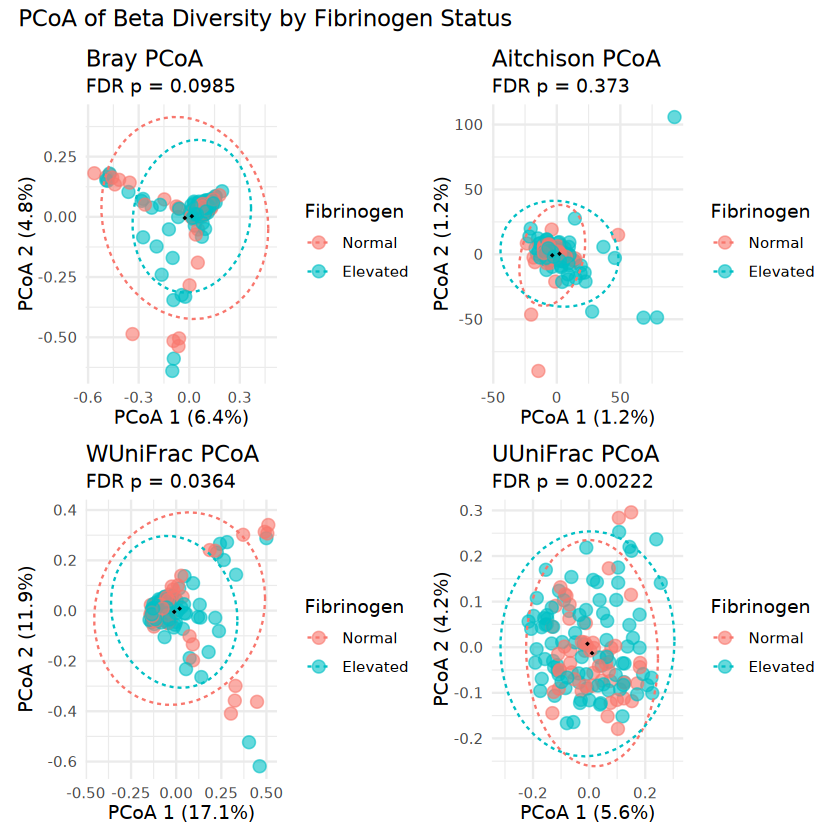

In [87]:
# Combine all plots in plot_list
combined_plot <- wrap_plots(plot_list, ncol = 2) + 
                 plot_annotation(title = "PCoA of Beta Diversity by Fibrinogen Status")

# Display combined plot
print(combined_plot)

# Save as high-resolution PNG or TIFF
ggsave(
  filename = "/scratch/negishi/ldas/COW_INFLAMMATION/Figures/beta_diversity_pcoa_combined.png",
  plot = combined_plot,
  width = 12, height = 8, dpi = 300
)

ggsave(
  filename = "/scratch/negishi/ldas/COW_INFLAMMATION/Figures/beta_diversity_pcoa_combined.tiff",
  plot = combined_plot,
  width = 12, height = 8, dpi = 300, compression = "lzw"
)


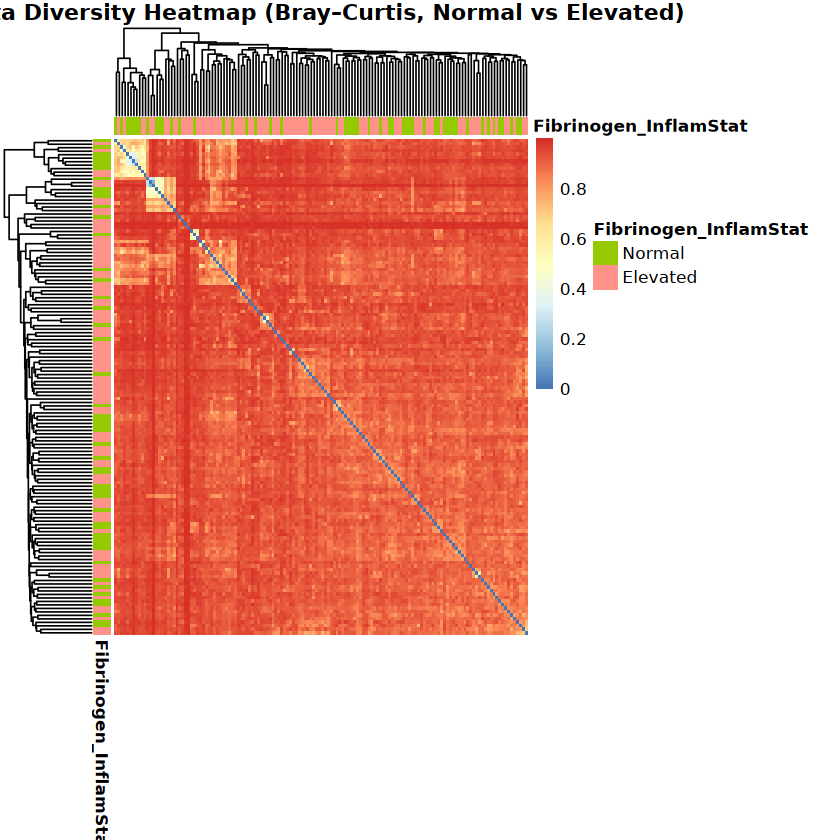

In [88]:
# Bray–Curtis distance
bray_dist <- phyloseq::distance(ps, method = "bray")
bray_mat <- as.matrix(bray_dist)
mode(bray_mat) <- "numeric"
bray_mat[is.na(bray_mat)] <- 0  # replace any NA if present

# Extract metadata and order samples by Fibrinogen_InflamStat
meta <- as.data.frame(sample_data(ps))
meta$Fibrinogen_InflamStat <- factor(meta$Fibrinogen_InflamStat, levels = c("Normal", "Elevated"))

# Reorder matrix rows and columns to match the factor order
sample_order <- rownames(meta[order(meta$Fibrinogen_InflamStat), ])
bray_mat_ordered <- bray_mat[sample_order, sample_order]

# Create annotation for heatmap
annotation <- data.frame(Fibrinogen_InflamStat = meta[sample_order, "Fibrinogen_InflamStat", drop = FALSE])
rownames(annotation) <- sample_order

# Plot heatmap
pheatmap(bray_mat_ordered,
         clustering_distance_rows = "euclidean",
         clustering_distance_cols = "euclidean",
         clustering_method = "average",
         show_rownames = FALSE,
         show_colnames = FALSE,
         annotation_col = annotation,
         annotation_row = annotation,
         main = "Beta Diversity Heatmap (Bray–Curtis, Normal vs Elevated)")


In [ ]:
#### Network analysis by SpiecEasi
# Load required libraries
library(phyloseq)
library(SpiecEasi)
library(igraph)
library(RColorBrewer)
library(scales)

In [95]:
otu_mat <- as.matrix(otu_table(ps))
if (taxa_are_rows(ps)) {
  otu_mat <- t(otu_mat)   
}


In [ ]:
# Meinshausen-Bühlmann method
se.mb <- spiec.easi(otu_mat, method = 'mb',
                    lambda.min.ratio = 1e-2,
                    nlambda = 20,
                    pulsar.params = list(rep.num = 50))

# Graphical Lasso method
se.gl <- spiec.easi(otu_mat, method = 'glasso',
                    lambda.min.ratio = 1e-2,
                    nlambda = 20,
                    pulsar.params = list(rep.num = 50))


In [ ]:
sparcc.res <- sparcc(otu_mat)

# Threshold correlations (absolute correlation ≥ 0.3)
sparcc.graph <- abs(sparcc.res$Cor) >= 0.3
diag(sparcc.graph) <- 0
library(Matrix)
sparcc.graph <- Matrix(sparcc.graph, sparse = TRUE)


In [ ]:
## Create igraph objects
ig.mb     <- adj2igraph(getRefit(se.mb))
ig.gl     <- adj2igraph(getRefit(se.gl))
ig.sparcc <- adj2igraph(sparcc.graph)

In [ ]:
# Visualize
library(igraph)
## set size of vertex proportional to clr-mean
vsize    <- rowMeans(clr(amgut1.filt, 1))+6
am.coord <- layout.fruchterman.reingold(ig.mb)

par(mfrow=c(1,3))
plot(ig.mb, layout=am.coord, vertex.size=vsize, vertex.label=NA, main="MB")
plot(ig.gl, layout=am.coord, vertex.size=vsize, vertex.label=NA, main="glasso")
plot(ig.sparcc, layout=am.coord, vertex.size=vsize, vertex.label=NA, main="sparcc")

In [ ]:
#### Haptoglobin
# Load necessary packages
library(phyloseq)
library(SpiecEasi)
library(igraph)
library(ggplot2)
library(dplyr)

#-------------------------------
# 1. Function: Agglomerate and Filter
#-------------------------------
agglom_filter <- function(physeq){
  ps_genus <- tax_glom(physeq, taxrank = "Genus")
  min_prev <- floor(0.1 * nsamples(ps_genus))
  ps_filtered <- filter_taxa(ps_genus, function(x) sum(x > 10) > min_prev, TRUE)
  return(ps_filtered)
}

#-------------------------------
# 2. Function: Run SPIEC-EASI
#-------------------------------
run_spieceasi <- function(physeq_filtered){
  se.mb <- spiec.easi(physeq_filtered, method = 'mb',
                      lambda.min.ratio = 1e-2,
                      nlambda = 20,
                      sel.criterion = 'stars',
                      pulsar.params = list(rep.num = 50),
                      verbose = TRUE)
  return(se.mb)
}

#-------------------------------
# 3. Function: Degree per Genus
#-------------------------------
get_genus_degree_df <- function(net, physeq_filtered, group_name) {
  deg <- degree(net)
  tax_df <- as.data.frame(tax_table(physeq_filtered))
  taxa_ids <- taxa_names(physeq_filtered)
  rownames(tax_df) <- taxa_ids

  tax_df$Genus_Clean <- make.unique(
    ifelse(is.na(tax_df$Genus) | tax_df$Genus == "", "Unclassified", as.character(tax_df$Genus))
  )

  common_nodes <- intersect(names(deg), taxa_ids)

  if (length(common_nodes) == 0) {
    warning("No overlapping taxa names found between network and phyloseq.")
    return(data.frame(Genus = character(), Degree = numeric(), Group = character()))
  }

  matched_genera <- tax_df[common_nodes, "Genus_Clean"]
  names(deg) <- matched_genera[match(names(deg), common_nodes)]

  deg_agg <- tapply(deg, names(deg), sum)

  df <- data.frame(
    Genus = names(deg_agg),
    Degree = as.numeric(deg_agg),
    Group = group_name,
    stringsAsFactors = FALSE
  )
  return(df)
}

#-------------------------------
# 4. Subset Haptoglobin Groups
#-------------------------------
ps_hapto_elevated <- subset_samples(ps, Haptoglobin_InflamStat == "Elevated")
ps_hapto_normal   <- subset_samples(ps, Haptoglobin_InflamStat == "Normal")

#-------------------------------
# 5. Agglomerate & Filter
#-------------------------------
ps_hapto_elevated_filt <- agglom_filter(ps_hapto_elevated)
ps_hapto_normal_filt   <- agglom_filter(ps_hapto_normal)

#-------------------------------
# 6. Run SPIEC-EASI
#-------------------------------
se_hapto_elevated <- run_spieceasi(ps_hapto_elevated_filt)
se_hapto_normal   <- run_spieceasi(ps_hapto_normal_filt)

#-------------------------------
# 7. Create Network Graphs
#-------------------------------
adj_elev_hapto <- as.matrix(getRefit(se_hapto_elevated))
rownames(adj_elev_hapto) <- colnames(adj_elev_hapto) <- taxa_names(ps_hapto_elevated_filt)
net_elev_hapto <- graph_from_adjacency_matrix(adj_elev_hapto, mode = "undirected")

adj_norm_hapto <- as.matrix(getRefit(se_hapto_normal))
rownames(adj_norm_hapto) <- colnames(adj_norm_hapto) <- taxa_names(ps_hapto_normal_filt)
net_norm_hapto <- graph_from_adjacency_matrix(adj_norm_hapto, mode = "undirected")

#-------------------------------
# 8. Compute Degree Tables
#-------------------------------
df_elev_hapto <- get_genus_degree_df(net_elev_hapto, ps_hapto_elevated_filt, "Haptoglobin Elevated")
df_norm_hapto <- get_genus_degree_df(net_norm_hapto, ps_hapto_normal_filt, "Haptoglobin Normal")

#-------------------------------
# 9. Combine and Get Top 15
#-------------------------------
df_combined_hapto <- bind_rows(df_elev_hapto, df_norm_hapto)

top_genera_hapto <- df_combined_hapto %>%
  group_by(Genus) %>%
  summarise(TotalDegree = sum(Degree), .groups = "drop") %>%
  arrange(desc(TotalDegree)) %>%
  slice_head(n = 15) %>%
  pull(Genus)

df_top_hapto <- df_combined_hapto %>% filter(Genus %in% top_genera_hapto)

#-------------------------------
# 10. Plot Side-by-Side Barplot
#-------------------------------
p_hapto <- ggplot(df_top_hapto, aes(x = reorder(Genus, Degree), y = Degree, fill = Group)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), color = "black", width = 0.7) +
  coord_flip() +
  scale_fill_manual(values = c("Haptoglobin Elevated" = "#3C7DC4", "Haptoglobin Normal" = "#F4A7B9")) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Top 15 Genus Node Degrees by Haptoglobin Inflammation Status",
    x = "Genus", y = "Degree (Number of Edges)",
    fill = "Group"
  ) +
  theme(axis.text.x = element_text(size = 10))

#-------------------------------
# 11. Save Plot
#-------------------------------
ggsave("/scratch/negishi/ldas/1_5_25/DADA2_outputs/top15_genus_degrees_haptoglobin.png",
       plot = p_hapto, width = 10, height = 7, dpi = 300)


In [ ]:
### Radial Polar Plot (Circular)
plot_eigen_polar <- function(df, group_name) {
  ggplot(df, aes(x = Genus, y = Mean_EigenvectorCentrality)) +
    geom_bar(stat = "identity", fill = "#3C7DC4", color = "black") +
    coord_polar(start = 0) +
    labs(title = paste("Circular Eigenvector Centrality -", group_name),
         x = "", y = "") +
    theme_minimal(base_size = 13) +
    theme(axis.text.x = element_text(angle = 90, size = 10, vjust = 0.5),
          axis.text.y = element_blank(),
          panel.grid = element_blank(),
          axis.title = element_blank())
}
plot_eigen_polar(eigen_fib_elev, "Fibrinogen Elevated")
plot_eigen_polar(eigen_fib_norm, "Fibrinogen Normal")
plot_eigen_polar(eigen_hapto_elev, "Haptoglobin Elevated")
plot_eigen_polar(eigen_hapto_norm, "Haptoglobin Normal")


In [ ]:
ps_corrected_Hapto_PLSDA_batch.rds

In [90]:
library(phyloseq)
library(dplyr)
library(tidyr)

# Extract abundance at genus (or higher taxonomic level of choice)
# You can set tax_level = "Genus" / "Family" / "Phylum" etc.
ps_genus <- tax_glom(ps, taxrank = "Genus")  

# Convert to relative abundance
ps_relabund <- transform_sample_counts(ps_genus, function(x) x / sum(x))

# Make abundance table
df_abund <- as.data.frame(t(otu_table(ps_relabund)))
df_abund$SampleID <- rownames(df_abund)

# Metadata
df_meta <- as.data.frame(sample_data(ps))
df_meta$SampleID <- rownames(df_meta)

# Join abundance with metadata
df <- left_join(df_abund, df_meta, by = "SampleID")
